# Big Data Modelling and Management 2026


Group number: 3

Students (Part: student number | name ): 
1. Part B: 20250419 | Alexandre Batista 
2. Part A: 20250443 | Artem Polikarpov 
3. Part C: 20250015 | Isabel Liu 
4. Part D: 20221689 | Simon Sazonov   


<hr>

# 1. Setup


In [10]:
from src import utils

from pprint import pprint


from pymongo import MongoClient
import json
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bson.decimal128 import Decimal128
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

%config InlineBackend.figure_format = 'retina' # Higher resolution plots

user = "AzureDiamond"
password = "hunter2"
host = "localhost"
port = "27017"
protocol = "mongodb"

client = MongoClient(f"{protocol}://{user}:{password}@{host}:{port}")

# Database check
db = client.sample_airbnb
print(f"Database info: {db}\n")
db.name

Database info: Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'sample_airbnb')



'sample_airbnb'

In [11]:
import warnings

warnings.filterwarnings("ignore")


In [12]:
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 160)

[PyMongo documentation](https://pymongo.readthedocs.io/en/stable/api/pymongo/collection.html)


# 1. Data Loading and Inspection


In [13]:
# Collections are inside our Database 'sample_analytics'

collection_list = db.list_collection_names()

print(f"The database contains {len(collection_list)} collections")
print(f"All collections: {collection_list[0:]}")
print(
    f"Collection {collection_list[0]} contains {db[collection_list[0]].count_documents({})} documents"
)

The database contains 5 collections
All collections: ['listings', 'reviews', 'hosts', 'listingsAndReviews_HW2', 'listingsAndReviews_HW2_new']
Collection listings contains 5555 documents


In [14]:
collection = db["listingsAndReviews_HW2_new"]

results = collection.find().limit(2)

for doc in results:
    pprint(doc)
    print("=" * 60)


{'_id': '10006546',
 'access': 'We are always available to help guests. The house is fully '
           'available to guests. We are always ready to assist guests. when '
           'possible we pick the guests at the airport.  This service transfer '
           'have a cost per person. We will also have service "meal at home" '
           'with a diverse menu and the taste of each. Enjoy the moment!',
 'accommodates': 8,
 'address': {'country': 'Portugal',
             'country_code': 'PT',
             'government_area': 'Cedofeita, Ildefonso, Sé, Miragaia, Nicolau, '
                                'Vitória',
             'location': {'coordinates': [-8.61308, 41.1413],
                          'is_location_exact': False,
                          'type': 'Point'},
             'market': 'Porto',
             'street': 'Porto, Porto, Portugal'},
 'amenities': ['Bed linens',
               'Buzzer/wireless intercom',
               'Cable TV',
               'Cleaning before checkou

### 1.1 Field Presence Analysis


In [15]:
# 📊 Storage
field_counts = {}
total_docs = collection.count_documents({})


# 🔁 Recursive function
def collect_fields(obj, prefix=""):
    if isinstance(obj, list):
        for item in obj:
            if isinstance(item, dict):
                collect_fields(item, prefix)
        return

    if not isinstance(obj, dict):
        return

    for key, value in obj.items():
        full_key = f"{prefix}.{key}" if prefix else key

        field_counts[full_key] = field_counts.get(full_key, 0) + 1

        if isinstance(value, (dict, list)):
            collect_fields(value, full_key)


# 🚀 Iterate over documents
for doc in collection.find():
    collect_fields(doc)

# 🧾 Create DataFrame
df = pd.DataFrame(
    [
        {"field": k, "count": v, "percentage": round(v / total_docs * 100, 2)}
        for k, v in field_counts.items()
    ]
)

# # 🔽 Sort by frequency
df = df.sort_values(by="count", ascending=False)
df

,field,count,percentage
76,reviews._id,149792,2696.53
79,reviews.reviewer_id,149792,2696.53
78,reviews.listing_id,149792,2696.53
77,reviews.date,149792,2696.53
80,reviews.reviewer_name,149791,2696.51
81,reviews.comments,149784,2696.38
47,host.host_has_profile_pic,5555,100.00
53,address.street,5555,100.00
52,address,5555,100.00
51,host.host_verifications,5555,100.00


### 1.2 Redundancy in Host Listing Count Fields


In [16]:
# Check whether the fields 'host.host_total_listings_count' and
# 'host.host_listings_count' differ across documents.
# If no differences are found, one of the fields may be redundant.
results = collection.count_documents(
    {"$expr": {"$ne": ["$host.host_total_listings_count", "$host.host_listings_count"]}}
)
pprint(results)

0


### 1.3 Host ID Frequency Analysis


In [17]:
# --- Aggregation pipeline that sorts host_ids per count --- #
pipeline = [
    {
        "$group": {
            "_id": "$host.host_id",  # change this field as needed
            "count": {"$sum": 1},
        }
    },
    {"$sort": {"count": -1}},
    {"$limit": (5)},
]
for doc in collection.aggregate(pipeline):
    print(doc)


{'_id': '97240131', 'count': 18}
{'_id': '12243051', 'count': 11}
{'_id': '4459553', 'count': 9}
{'_id': '38459934', 'count': 9}
{'_id': '3953109', 'count': 7}


### 1.4 Investigation of Duplicate Host IDs


In [18]:
target_host_id = "97240131"  # host_id with highest count

for doc in collection.find({"host.host_id": target_host_id}):
    pprint(doc)
    print("=" * 100)

{'_id': '24615811',
 'accommodates': 2,
 'address': {'country': 'Hong Kong',
             'country_code': 'HK',
             'government_area': 'Wan Chai',
             'location': {'coordinates': [114.18425, 22.27852],
                          'is_location_exact': False,
                          'type': 'Point'},
             'market': 'Hong Kong',
             'street': 'Hong Kong, Hong Kong Island, Hong Kong',
             'suburb': 'Wan Chai District'},
 'amenities': ['Air conditioning',
               'Hangers',
               'Hot water',
               'Iron',
               'Kitchen',
               'Laptop friendly workspace',
               'Lock on bedroom door',
               'Self check-in',
               'Smart lock',
               'Washer',
               'Wifi'],
 'availability': {'availability_30': 29,
                  'availability_365': 364,
                  'availability_60': 59,
                  'availability_90': 89},
 'bathrooms': Decimal128('1.0'),
 'bed

### 1.5 Checking for Missing or Invalid Host Identifiers


**Data Completeness Validation for `host.host_id`**

As part of the exploratory data analysis, a validation step was performed to assess whether the `host` field and its nested identifier `host.host_id` are consistently present across all documents.

A query was used to identify documents where `host.host_id` is missing or null. The result returned zero documents, confirming that all records contain a valid `host.host_id`.

This ensures that the dataset satisfies the conditions required for normalization, allowing `host_id` to be safely used as a reference key between the `hosts` and `listings` collections without risk of orphan records or referential inconsistencies.


In [19]:
# Count documents where host_id is missing or null
null_host_counter = collection.count_documents({"host.host_id": None})
pprint(null_host_counter)

0


### 1.6 Review Data Quality Analysis


**Data Consistency Validation for Review-Related Fields**

The aggregation results show consistent patterns across all 5,555 documents in the dataset:

- The top-level field `review_scores_rating` is null in all documents (5,555 out of 5,555), indicating that it does not contain any meaningful information.

- The nested field `review_scores.review_scores_rating` is never null when present (0 null values), and therefore represents the actual review rating data.

- The `transactions` field is identical across all documents, always equal to `{"transactions": []}`, indicating a uniform but non-informative placeholder structure.

These results confirm that the dataset contains redundant and non-informative fields.

**Conclusions:**

- `review_scores_rating` is redundant and can be removed.
- `review_scores.review_scores_rating` should be retained as the valid source of rating information.
- `transactions` does not contain useful data and can be removed.

These findings are used to guide the removal of redundant fields during the data modeling stage.


In [20]:
# --------------------------------
# Stage 1: Derive indicators for review data quality
# --------------------------------
# Create boolean flags to identify:
# - missing or empty reviews
# - null review score fields (top-level and nested)
# - expected structure of transactions field
query1 = {
    "$project": {
        "_id": 1,
        "reviews_missing_or_empty": {
            "$or": [{"$eq": ["$reviews", None]}, {"$eq": ["$reviews", []]}]
        },
        "top_level_rating_is_null": {"$eq": ["$review_scores_rating", None]},
        "nested_review_rating_is_null": {
            "$eq": ["$review_scores.review_scores_rating", None]
        },
        "transactions_is_expected": {"$eq": ["$transactions", {"transactions": []}]},
    }
}

# --------------------------------
# Stage 2: Aggregate counts for each condition
# --------------------------------
# Summarize the number of documents matching each condition
query2 = {
    "$group": {
        "_id": None,
        "total_documents": {"$sum": 1},
        "listings_without_reviews": {
            "$sum": {"$cond": ["$reviews_missing_or_empty", 1, 0]}
        },
        "top_level_rating_null_count": {
            "$sum": {"$cond": ["$top_level_rating_is_null", 1, 0]}
        },
        "nested_review_rating_null_count": {
            "$sum": {"$cond": ["$nested_review_rating_is_null", 1, 0]}
        },
        "transactions_expected_count": {
            "$sum": {"$cond": ["$transactions_is_expected", 1, 0]}
        },
    }
}

# --------------------------------
# Final pipeline
# --------------------------------
review_quality_pipeline = [query1, query2]

# Execute pipeline
result = list(collection.aggregate(review_quality_pipeline))
stats = result[0]

# --------------------------------
# Output summary
# --------------------------------
print(f"Total number of documents: {stats['total_documents']}")
print(f"Listings without reviews: {stats['listings_without_reviews']}")
print(
    f"Top-level 'review_scores_rating' is null: {stats['top_level_rating_null_count']}"
)
print(
    f"Nested 'review_scores.review_scores_rating' is null: {stats['nested_review_rating_null_count']}"
)
print(
    f"'transactions' matches expected structure: {stats['transactions_expected_count']}"
)

Total number of documents: 5555
Listings without reviews: 1632
Top-level 'review_scores_rating' is null: 5555
Nested 'review_scores.review_scores_rating' is null: 0
'transactions' matches expected structure: 5555


# 2. Data Modeling


### 2.1 Identified Data Modeling Issues


#### 2.1.1 Problem: Redundant Embedded Host Data


The original MongoDB collection uses an embedded document model where each listing contains a full host subdocument. Since the same `host_id` appears across multiple listings (up to 18 occurrences), identical host information is repeatedly stored — introducing redundancy, storage overhead, and potential update anomalies.

Moreover, this dataset represents only a subset of the overall Airbnb database. In practice, some large property management hosts manage hundreds or even thousands of listings (as indicated by the fields `host.host_total_listings_count` and `host.host_listings_count`). Therefore, the extent of redundancy in a full-scale dataset is likely to be significantly greater.


#### 2.1.2 Problem: Multiple Reviews per Listing


The original MongoDB collection embeds review data directly within each listing document, resulting in multiple review entries associated with a single listing. As listings may contain numerous reviews, this leads to large and potentially unbounded document sizes, making the data harder to manage and query efficiently.

Furthermore, embedding reviews within listings limits flexibility for analysis, as queries involving reviews (e.g., filtering, aggregation, or temporal analysis) become more complex and less efficient. This structure also violates normalization principles, as review data represents a separate entity that is more appropriately stored in its own collection and linked via a reference (e.g., `listing_id`).


### 2.2 Refactoring to a Referenced Data Model


To address the identified issues, the schema is refactored from an embedded document model to a referenced data model. In this approach, entities that naturally exist independently—such as hosts and reviews—are separated into their own collections.

A dedicated `hosts` collection is introduced to store unique host information, while a `reviews` collection is created to store individual review entries. Instead of embedding these entities within listing documents, references are used to establish relationships between collections.

Specifically, listings retain a `host_id` field to reference the corresponding host in the `hosts` collection, and reviews include a `listing_id` field to reference the associated listing. This design reduces redundancy, improves data consistency, and enables more flexible and efficient querying.


### 2.3 Creating the Hosts Collection


The schema is refactored by separating host data into a dedicated `hosts` collection, replacing embedded host subdocuments with references.

The `hosts` collection is constructed using an aggregation pipeline that:

- filters documents with valid `host_id`,
- sorts documents by `host_id` and `last_scraped` in descending order,
- groups by `host_id` and retains the first document in each group (corresponding to the most recent host snapshot),
- and extracts the associated host subdocument.


In [21]:
# --------------------------------
# Stage 1: Keep only documents with valid host_id
# --------------------------------
query1 = {
    "$match": {
        "host": {"$exists": True},
        "host.host_id": {"$exists": True, "$ne": None},
    }
}

# --------------------------------
# Stage 2: Sort by host_id and newest last_scraped first
# (so newest document per host comes first)
# --------------------------------
query2 = {"$sort": {"host.host_id": 1, "last_scraped": -1}}

# --------------------------------
# Stage 3: Group by host_id
# Take the first document (latest due to sorting)
# --------------------------------
query3 = {"$group": {"_id": "$host.host_id", "doc": {"$first": "$$ROOT"}}}

# --------------------------------
# Stage 4: Keep only the selected host subdocument
# --------------------------------
query4 = {"$replaceRoot": {"newRoot": "$doc.host"}}

# --------------------------------
# Stage 5: let MongoDB create a new _id
# --------------------------------
query5 = {"$project": {"_id": 0}}

# --------------------------------
# Stage 5:  Write the resulting documents to a new collection
# --------------------------------
query6 = {"$out": "hosts"}

# --------------------------------
# Final pipeline
# --------------------------------
host_pipeline = [query1, query2, query3, query4, query5, query6]

# Execute and store result
collection.aggregate(host_pipeline)  # .to_list(length=None)

In [22]:
# Preview a sample document to verify the structure of the hosts collection
db.hosts.find_one()

{'_id': ObjectId('69d92b3d7f97d3ca0bf8b259'),
 'host_id': '70143192',
 'host_url': 'https://www.airbnb.com/users/show/70143192',
 'host_name': 'Jason',
 'host_location': 'Montreal, Quebec, Canada',
 'host_about': '',
 'host_response_time': 'within an hour',
 'host_thumbnail_url': 'https://a0.muscache.com/im/pictures/44522772-f05a-486e-aa21-8f99da321417.jpg?aki_policy=profile_small',
 'host_picture_url': 'https://a0.muscache.com/im/pictures/44522772-f05a-486e-aa21-8f99da321417.jpg?aki_policy=profile_x_medium',
 'host_neighbourhood': '',
 'host_response_rate': 100,
 'host_is_superhost': False,
 'host_has_profile_pic': True,
 'host_identity_verified': False,
 'host_listings_count': 1,
 'host_total_listings_count': 1,
 'host_verifications': ['email',
  'phone',
  'reviews',
  'jumio',
  'offline_government_id',
  'government_id']}

### 2.4 Creating the Listings Collection


The `listings` collection is created by copying each document from the original collection, extracting the `host.host_id` field into a new top-level field `host_id`, removing the embedded host and reviews subdocuments, and writing the transformed documents into a new collection.


In [23]:
# --------------------------------
# Stage 1: Add top-level host_id from embedded host subdocument
# --------------------------------
query1 = {"$addFields": {"host_id": "$host.host_id"}}

# --------------------------------
# Stage 2: Remove embedded host subdocument
# --------------------------------
query2 = {"$project": {"host": 0, "reviews": 0}}

# --------------------------------
# Stage 3: Write the resulting documents to a new collection
# --------------------------------
query3 = {"$out": "listings"}

# --------------------------------
# Final pipeline
# --------------------------------
listing_pipeline = [query1, query2, query3]

collection.aggregate(listing_pipeline)

In [24]:
# Preview a sample document to verify the structure of the listings collection
db.listings.find_one()

{'_id': '10006546',
 'listing_url': 'https://www.airbnb.com/rooms/10006546',
 'name': 'Ribeira Charming Duplex',
 'summary': 'Fantastic duplex apartment with three bedrooms, located in the historic area of Porto, Ribeira (Cube) - UNESCO World Heritage Site. Centenary building fully rehabilitated, without losing their original character.',
 'space': 'Privileged views of the Douro River and Ribeira square, our apartment offers the perfect conditions to discover the history and the charm of Porto. Apartment comfortable, charming, romantic and cozy in the heart of Ribeira. Within walking distance of all the most emblematic places of the city of Porto. The apartment is fully equipped to host 8 people, with cooker, oven, washing machine, dishwasher, microwave, coffee machine (Nespresso) and kettle. The apartment is located in a very typical area of the city that allows to cross with the most picturesque population of the city, welcoming, genuine and happy people that fills the streets with h

### 2.5 Creating the Reviews Collection


Since multiple reviews exist per listing, they are extracted into a separate `reviews` collection.

To further normalize the dataset, a dedicated `reviews` collection is created by extracting the nested review documents embedded within each listing.

Each review document is extracted from its parent listing and stored in the `reviews` collection, preserving `listing_id` as a reference to maintain the relationship with the `listings` collection.

This separation follows the same referenced relationship pattern established for hosts: rather than embedding potentially large and variable-length arrays within listing documents, reviews are stored independently and linked via `listing_id`. The result is a cleaner and more maintainable schema, where listings describe properties and reviews capture guest feedback.

The `reviews` collection is created from `listings` by selecting only listings with non-empty reviews arrays, unwinding the embedded reviews so that each review becomes a separate document, replacing the root with the review content, adding the parent `listing_id` as a reference to the originating listing, and writing the resulting documents into a new collection.


In [25]:
# --- Reviews collection via aggregation ($out) --- #

# 1. Keep only listings that contain at least one review
match_non_empty_reviews = {"$match": {"reviews.0": {"$exists": True}}}

# 2. Flatten the reviews array (1 document per review)
unwind_reviews = {"$unwind": "$reviews"}

# 3. Promote each review to root level and attach listing_id
replace_root_with_review = {
    "$replaceRoot": {"newRoot": {"$mergeObjects": ["$reviews", {"listing_id": "$_id"}]}}
}

# 4. Output results into a NEW collection "reviews1"
#    - completely replaces reviews1 if it already exists
out_reviews_collection = {"$out": "reviews"}

# Combine pipeline
reviews_pipeline_out = [
    match_non_empty_reviews,
    unwind_reviews,
    replace_root_with_review,
    out_reviews_collection,
]

# Execute pipeline
collection.aggregate(reviews_pipeline_out)

In [26]:
# Preview a sample document to verify the structure of the reviews collection
pprint(db.reviews.find_one())

{'_id': '58663741',
 'comments': 'A casa da Ana e do Gonçalo foram o local escolhido para a '
             'passagem de ano com um grupo de amigos. Fomos super bem '
             'recebidos com uma grande simpatia e predisposição a ajudar com '
             'qualquer coisa que fosse necessário.\r\n'
             'A casa era ainda melhor do que parecia nas fotos, totalmente '
             'equipada, com mantas, aquecedor e tudo o que pudessemos '
             'precisar.\r\n'
             'A localização não podia ser melhor! Não há melhor do que acordar '
             'de manhã e ao virar da esquina estar a ribeira do Porto.',
 'date': datetime.datetime(2016, 1, 3, 5, 0),
 'listing_id': '10006546',
 'reviewer_id': '51483096',
 'reviewer_name': 'Cátia'}


### 2.6 Removing Redundant Fields


Based on the data consistency analysis, certain fields were identified as redundant or non-informative. Specifically, the top-level `review_scores_rating` field was consistently null across all documents, and the `transactions` field contained only a uniform placeholder structure.

These fields are removed from the `listings` collection to reduce redundancy and simplify the schema.


In [27]:
# --------------------------------
# Remove redundant fields from listings collection
# --------------------------------
db.listings.update_many(
    {}, {"$unset": {"review_scores_rating": "", "transactions": ""}}
)

UpdateResult({'n': 5555, 'nModified': 5555, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [28]:
# --------------------------------
# Remove redundant fields from hosts collection
# --------------------------------
db.hosts.update_many({}, {"$unset": {"host_listings_count": "", "transactions": ""}})

UpdateResult({'n': 5104, 'nModified': 5104, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [29]:
# Preview updated document
db.hosts.find_one()

{'_id': ObjectId('69d92b3d7f97d3ca0bf8b259'),
 'host_id': '70143192',
 'host_url': 'https://www.airbnb.com/users/show/70143192',
 'host_name': 'Jason',
 'host_location': 'Montreal, Quebec, Canada',
 'host_about': '',
 'host_response_time': 'within an hour',
 'host_thumbnail_url': 'https://a0.muscache.com/im/pictures/44522772-f05a-486e-aa21-8f99da321417.jpg?aki_policy=profile_small',
 'host_picture_url': 'https://a0.muscache.com/im/pictures/44522772-f05a-486e-aa21-8f99da321417.jpg?aki_policy=profile_x_medium',
 'host_neighbourhood': '',
 'host_response_rate': 100,
 'host_is_superhost': False,
 'host_has_profile_pic': True,
 'host_identity_verified': False,
 'host_total_listings_count': 1,
 'host_verifications': ['email',
  'phone',
  'reviews',
  'jumio',
  'offline_government_id',
  'government_id']}

In [30]:
# Preview updated document
db.listings.find_one()

{'_id': '10006546',
 'listing_url': 'https://www.airbnb.com/rooms/10006546',
 'name': 'Ribeira Charming Duplex',
 'summary': 'Fantastic duplex apartment with three bedrooms, located in the historic area of Porto, Ribeira (Cube) - UNESCO World Heritage Site. Centenary building fully rehabilitated, without losing their original character.',
 'space': 'Privileged views of the Douro River and Ribeira square, our apartment offers the perfect conditions to discover the history and the charm of Porto. Apartment comfortable, charming, romantic and cozy in the heart of Ribeira. Within walking distance of all the most emblematic places of the city of Porto. The apartment is fully equipped to host 8 people, with cooker, oven, washing machine, dishwasher, microwave, coffee machine (Nespresso) and kettle. The apartment is located in a very typical area of the city that allows to cross with the most picturesque population of the city, welcoming, genuine and happy people that fills the streets with h

### 2.7 Creating Indexes for Reference Keys


To support efficient joins and lookups between the normalized collections, indexes are created on the reference keys used to establish relationships. A unique index is defined on `hosts1.host_id`, while non-unique indexes are created on `listings1.host_id` and `reviews1.listing_id`.

**Important note:**

- `hosts1.host_id` must be unique, as each host appears only once in the `hosts1` collection.

- `listings1.host_id` must not be unique, since a single host can have multiple listings (one-to-many relationship).

- `reviews1.listing_id` must not be unique, since a single listing can have multiple reviews (one-to-many relationship).


In [31]:
# --------------------------------
# Create indexes for reference fields
# --------------------------------

# Hosts: ensure host_id is unique
db.hosts.create_index([("host_id", 1)], unique=True, name="idx_hosts_host_id_unique")

# Listings: index host_id for joins with hosts
db.listings.create_index([("host_id", 1)], name="idx_listings_host_id")

# Reviews: index listing_id for joins with listings
# db.reviews.create_index([("listing_id", 1)], name="idx_reviews_listing_id")

'idx_listings_host_id'

In [32]:
# Verify that indexes were created
pprint(db.hosts.index_information())
pprint(db.listings.index_information())
pprint(db.reviews.index_information())

{'_id_': {'key': [('_id', 1)], 'v': 2},
 'idx_hosts_host_id_unique': {'key': [('host_id', 1)], 'unique': True, 'v': 2}}
{'_id_': {'key': [('_id', 1)], 'v': 2},
 'idx_listings_host_id': {'key': [('host_id', 1)], 'v': 2}}
{'_id_': {'key': [('_id', 1)], 'v': 2},
 'idx_reviews_listing_id': {'key': [('listing_id', 1)], 'v': 2}}


# A. Price Analytics Expert


**A1. Price Analysis**

Analyse prices of properties in three cities: Hong Kong, Montreal, and Barcelona.
Assume that three people will stay for one week. Based on this assumption, calculate the price per person per night, including any additional charges such as cleaning fee etc.

Create box plots for five property types - Apartment, Guesthouse, Hostel, House, Townhouse - for each city, mark the range of prices per person per night, make sure to include min and max prices, mark the median and the range where 50 % of prices lie.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning. 2. one graph with 15 box plots where each box plot corresponds to a rating category and contains the distributions for the three cities side by side for comparison. 3. result analysis and interpretation (250-350 words).

**A2. Query Pipeline Analysis**

You will calculate the accommodation prices in New York per property type. You are only interested in those properties that have all of the following: Wifi, Hair dryer, 24-hour check-in, Air conditioning, Bed linens.

Among the selected properties, distinguish between two categories:

        A. Wheelchair-friendly properties, defined as those that include at least one of the following amenities: Elevator, Ground floor access, Wheelchair accessible, Wide doorway, Disabled parking spot;
        B. Family-friendly properties, defined as those that include at least one of the following amenities: Crib, Family/kid friendly, Stair gates, Table corner guards.

Assume that three people will stay for one week. Based on this assumption, the aggregation pipeline should calculate the price per person per night, including any additional charges such as cleaning fee, extra person fee, child fee, or other applicable fees. Calculate the prices for both groups of properties, and both customer categories (wheelchair-, and child-friendly). Transform the output into easy-to-read comparison table.

Create visual with box plots for five most numerous property types for each category (wheelchair- and family-friendly cases side-by-side) on x-axis, and range of prices per person per night on y-axis. Include Median, interquartile range (50% of cases), min/max, outliers.

As this query will be regularly run on this subset, use 'explain' function, to analyse which sequence of pipeline stages, indexes (if any), and any other methods improve your query performance. Output a table with metrics like execution time, docs examined, keys examined, stage, memory, etc to compare raw pipeline query and improved query after you apply different methods to optimize it.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. data interpretation. 2. visual with 10 box plots (5 types \* 2 categories). 3. table with comparison metrics of before and after query performance. 4. result analysis and interpretation (max 200 words).

**A3. Analytical Price Suggestion**

A number of properties in the collection are missing prices. Analyse those properties, define similar properties where the price exists, and suggest a specific value to the hosts of properties without prices. You can choose to consider property type, location, host details, number of rooms and/or bathrooms, amenities, house rules, etc that indicate the type of clients that those properties attract.

Another possible avenue to define similar properties could be to analyze the raw reviews using sentiment analysis external to mongodb (e.g. chatgpt can assess the sentiment of review text), and add additional attributes that help you define similar properties. The method and attributes you use to suggest the price is up to you. Keep a clear record of how you did it (a short description before the calculation cell).

As the result, each property that was missing a price should have a new field 'price_suggestion' with a value, all assumptions made and calculation elements considered should be listed, described, and explained clearly.

Considering only the suggested prices, create box plots for five property types - Apartment, Guesthouse, Hostel, House, Townhouse - for Hong Kong, Montreal, and Barcelona city, mark the range of prices per person per night, make sure to include min and max prices, mark the median and the range where 50 % of prices lie.

The delivered assignment should have three components: 1. any assumptions and decisions made at the beginning, e.g. reference properties used to estimate suggested price. 2. one graph with 15 box plots where box plots are grouped by property type (not by city). 3. result analysis and interpretation (250-350 words).


## A1. Price Analysis


### Assumptions

- Stay duration = 7 nights
- Number of guests = 3 people

Analysis focuses on three cities (Hong Kong, Montreal, Barcelona)  
and five property types (Apartment, Guesthouse, Hostel, House, Townhouse).

We use `accommodates >= 3`, because the property must be able to host three people.

We assume short-term availability and use availability_365 ≥ 7 to ensure a 7-night stay is possible. Additionally, listings must allow such a stay under booking rules, defined as minimum_nights ≤ 7 ≤ maximum_nights.

### Price

Only structured price fields were used in the calculation. When available, `weekly_price` was incorporated by comparing it to the cost of seven nightly prices (`price` \* 7), and the lower of the two was used in the total price calculation. If the nightly price was missing, the weekly price was used directly. This ensures that weekly discounts are consistently accounted for when they reduce the total cost. Additional charges mentioned in free-text fields were excluded because they are recorded inconsistently and may contain non-price information.

Price includes:

- Base accommodation cost (`price` \* 7 or `weekly_price`, whichever is lower; if price is missing, weekly_price is used)
- `cleaning_fee`
- Extra person fee (`extra_person_total`, if applicable)

For 3 people staying 7 nights:

`total_price` = (`price` \* 7 or `weekly_price`) + `cleaning_fee` + `extra_person_total`

`price_per_person_per_night` = `total_price` / (3 \* 7)

### Extra people rule

- `guests_included` = number of guests covered by the base nightly price
- `extra_people` = extra fee per extra guest per night

For 3 guests:

extra_guests = max(0, 3 - guests_included)

extra*person_charge = extra_guests * extra*people * 7

### Missing values

If these fields are missing, they are treated as:

- `cleaning_fee = 0`
- `extra_people = 0`
- `guests_included = 1` (nightly price usually covers at least one guest if the field is absent).

### Currency normalization

Prices are in different currencies (HKD, CAD, EUR) and are converted to euros for comparability.


In [33]:
# Extract and preprocess listings data:
# filter selected cities and property types, keep listings that accommodate ≥3 guests,
# have at least 7 available days, allow a 7-night stay (minimum_nights ≤ 7 ≤ maximum_nights),
# and have a valid price (price or weekly_price); project and rename fields
# (address.market → city), keep property_type, price, weekly_price, cleaning_fee,
# extra_people, and guests_included; convert numeric fields to float; replace missing values
# (cleaning_fee and extra_people → 0, guests_included → 1); and load results into a DataFrame
pipeline = [
    {
        "$match": {
            "address.market": {"$in": ["Hong Kong", "Montreal", "Barcelona"]},
            "property_type": {
                "$in": ["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"]
            },
            "accommodates": {"$gte": 3},
            "availability.availability_365": {"$gte": 7},
            "$or": [{"price": {"$ne": None}}, {"weekly_price": {"$ne": None}}],
            "minimum_nights": {"$lte": 7},
            "maximum_nights": {"$gte": 7},
        }
    },
    {
        "$project": {
            "_id": 1,
            "city": "$address.market",
            "property_type": 1,
            # Convert Decimal128 → float
            "price": {"$toDouble": "$price"},
            # Add weekly_price (converted, nullable)
            "weekly_price": {"$toDouble": {"$ifNull": ["$weekly_price", None]}},
            "cleaning_fee": {"$toDouble": {"$ifNull": ["$cleaning_fee", 0]}},
            "extra_people": {"$toDouble": {"$ifNull": ["$extra_people", 0]}},
            "guests_included": {"$ifNull": ["$guests_included", 1]},
        }
    },
]

data = list(db.listings.aggregate(pipeline))
df = pd.DataFrame(data)

In [34]:
df.head(15)

,_id,property_type,city,price,weekly_price,cleaning_fee,extra_people,guests_included
0,10233856,Apartment,Hong Kong,400.0,NaN,0.0,0.0,1
1,10343118,Apartment,Hong Kong,997.0,NaN,380.0,160.0,2
2,10558807,Apartment,Barcelona,85.0,NaN,40.0,0.0,6
3,1079887,Apartment,Barcelona,89.0,NaN,30.0,10.0,2
4,10816768,Apartment,Hong Kong,1703.0,7500.0,400.0,100.0,4
5,10840938,Apartment,Hong Kong,1146.0,NaN,285.0,60.0,4
6,10911771,Apartment,Hong Kong,597.0,NaN,0.0,0.0,1
7,11108923,Apartment,Barcelona,84.0,NaN,69.0,25.0,2
8,1112838,Apartment,Barcelona,130.0,NaN,65.0,35.0,4
9,11136898,Apartment,Barcelona,65.0,NaN,35.0,25.0,1


In [35]:
NIGHTS = 7
PEOPLE = 3

# Extra guests beyond those included in base price
df["extra_guests"] = np.maximum(0, PEOPLE - df["guests_included"])

# Total extra-person charge for the whole stay
df["extra_person_total"] = df["extra_guests"] * df["extra_people"] * NIGHTS

# Daily-price option for the whole stay
df["total_price_daily"] = (
    (df["price"] * NIGHTS) + df["cleaning_fee"] + df["extra_person_total"]
)

# Weekly-price option for the whole stay
df["total_price_weekly"] = (
    df["weekly_price"] + df["cleaning_fee"] + df["extra_person_total"]
)

# Final total price:
# Use weekly_price if:
# 1) it exists, AND
# 2) either daily price is missing OR weekly price is cheaper than 7 nights of daily price
# Otherwise, fall back to daily total price
df["total_price"] = np.where(
    df["weekly_price"].notna()
    & (df["price"].isna() | (df["weekly_price"] < df["price"] * NIGHTS)),
    df["total_price_weekly"],
    df["total_price_daily"],
)

# Final metric required in the task
df["price_per_person_per_night"] = round(df["total_price"] / (PEOPLE * NIGHTS), 2)

# Keep only valid positive prices
df = df[df["price_per_person_per_night"] > 0].copy()

df = df[
    [
        "city",
        "property_type",
        "price",
        "weekly_price",
        "cleaning_fee",
        "extra_people",
        "guests_included",
        "price_per_person_per_night",
    ]
]

In [36]:
df.head(15)

,city,property_type,price,weekly_price,cleaning_fee,extra_people,guests_included,price_per_person_per_night
0,Hong Kong,Apartment,400.0,NaN,0.0,0.0,1,133.33
1,Hong Kong,Apartment,997.0,NaN,380.0,160.0,2,403.76
2,Barcelona,Apartment,85.0,NaN,40.0,0.0,6,30.24
3,Barcelona,Apartment,89.0,NaN,30.0,10.0,2,34.43
4,Hong Kong,Apartment,1703.0,7500.0,400.0,100.0,4,376.19
5,Hong Kong,Apartment,1146.0,NaN,285.0,60.0,4,395.57
6,Hong Kong,Apartment,597.0,NaN,0.0,0.0,1,199.00
7,Barcelona,Apartment,84.0,NaN,69.0,25.0,2,39.62
8,Barcelona,Apartment,130.0,NaN,65.0,35.0,4,46.43
9,Barcelona,Apartment,65.0,NaN,35.0,25.0,1,40.00


In [37]:
# Convert prices to EUR using city-specific exchange rates and round to 2 decimals
rates = {
    "Hong Kong": 0.12,  # HKD → EUR
    "Montreal": 0.68,  # CAD → EUR
    "Barcelona": 1.0,  # already EUR
}

df["price_per_person_per_night_eur"] = df.apply(
    lambda row: round(row["price_per_person_per_night"] * rates[row["city"]], 2), axis=1
)

df.head(15)

,city,property_type,price,weekly_price,cleaning_fee,extra_people,guests_included,price_per_person_per_night,price_per_person_per_night_eur
0,Hong Kong,Apartment,400.0,NaN,0.0,0.0,1,133.33,16.00
1,Hong Kong,Apartment,997.0,NaN,380.0,160.0,2,403.76,48.45
2,Barcelona,Apartment,85.0,NaN,40.0,0.0,6,30.24,30.24
3,Barcelona,Apartment,89.0,NaN,30.0,10.0,2,34.43,34.43
4,Hong Kong,Apartment,1703.0,7500.0,400.0,100.0,4,376.19,45.14
5,Hong Kong,Apartment,1146.0,NaN,285.0,60.0,4,395.57,47.47
6,Hong Kong,Apartment,597.0,NaN,0.0,0.0,1,199.00,23.88
7,Barcelona,Apartment,84.0,NaN,69.0,25.0,2,39.62,39.62
8,Barcelona,Apartment,130.0,NaN,65.0,35.0,4,46.43,46.43
9,Barcelona,Apartment,65.0,NaN,35.0,25.0,1,40.00,40.00


In [38]:
# Compute summary statistics of price per person per night grouped by property type and city,
# including count, minimum, quartiles (Q1, median, Q3), and maximum.
# Additionally, calculate whiskers based on the IQR (1.5 × IQR rule) to align with boxplot definitions.
# Convert grouped indices to columns and sort the results for readability.

summary = (
    df.groupby(["property_type", "city"])["price_per_person_per_night_eur"]
    .agg(
        count="count",
        min="min",
        q1=lambda x: x.quantile(0.25),
        median="median",
        q3=lambda x: x.quantile(0.75),
        max="max",
    )
    .reset_index()
    .sort_values(["property_type", "city"])
)

# Interquartile range
summary["iqr"] = summary["q3"] - summary["q1"]

# Whiskers (computed via IQR, but without keeping bounds)
summary["lower_whisker"] = summary["q1"] - 1.5 * summary["iqr"]
summary["upper_whisker"] = summary["q3"] + 1.5 * summary["iqr"]

# Clip whiskers to actual data range
summary["lower_whisker"] = summary[["min", "lower_whisker"]].max(axis=1)
summary["upper_whisker"] = summary[["max", "upper_whisker"]].min(axis=1)

pd.DataFrame(summary)

,property_type,city,count,min,q1,median,q3,max,iqr,lower_whisker,upper_whisker
0,Apartment,Barcelona,142,9.76,29.1675,37.665,52.5600,261.90,23.3925,9.76,87.64875
1,Apartment,Hong Kong,78,5.14,29.5300,36.900,52.6725,83.32,23.1425,5.14,83.32000
2,Apartment,Montreal,92,7.41,20.5650,24.775,37.4875,149.44,16.9225,7.41,62.87125
3,Guesthouse,Hong Kong,3,14.44,15.5400,16.640,21.1400,25.64,5.6000,14.44,25.64000
4,Guesthouse,Montreal,1,15.22,15.2200,15.220,15.2200,15.22,0.0000,15.22,15.22000
5,Hostel,Barcelona,2,13.33,26.6650,40.000,53.3350,66.67,26.6700,13.33,66.67000
6,Hostel,Hong Kong,2,21.36,21.9900,22.620,23.2500,23.88,1.2600,21.36,23.88000
7,House,Barcelona,4,31.10,36.2750,42.335,54.1700,76.67,17.8950,31.10,76.67000
8,House,Hong Kong,4,35.16,38.9175,43.655,79.6400,177.14,40.7225,35.16,140.72375
9,House,Montreal,10,19.62,30.5950,39.310,49.4025,107.66,18.8075,19.62,77.61375


In [39]:
def plot_price_per_person_per_night(
    city_order=["Hong Kong", "Montreal", "Barcelona"],
    prop_order=["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"],
    log_scale=False,
    show_points=False,
):
    PALETTE = {"Hong Kong": "#378ADD", "Montreal": "#D85A30", "Barcelona": "#1D9E75"}

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    # Background stripes
    for i in range(0, len(prop_order), 2):
        ax.axvspan(i - 0.5, i + 0.5, color="#F5F5F5", zorder=0)

    # Boxplot (main chart)
    sns.boxplot(
        data=df,
        x="property_type",
        y="price_per_person_per_night_eur",
        hue="city",
        order=prop_order,
        hue_order=city_order,
        palette=PALETTE,
        showfliers=True,
        gap=0.04,
        ax=ax,
    )

    # Optional dots
    if show_points:
        sns.stripplot(
            data=df,
            x="property_type",
            y="price_per_person_per_night_eur",
            hue="city",
            order=prop_order,
            hue_order=city_order,
            dodge=True,  # separates cities within each category
            size=3,
            alpha=0.5,
            palette=PALETTE,
            ax=ax,
        )

    # Log scale
    if log_scale:
        ax.set_yscale("log")
        y_label = "Price per Person per Night (EUR, log scale)"
    else:
        y_label = "Price per Person per Night (EUR)"

    ax.set_title(
        "Price per Person per Night\n(3 people, 7 nights)",
        fontsize=14,
        fontweight="bold",
        pad=16,
        loc="left",
    )

    ax.set_xlabel("Property Type", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)

    # Clean legend (avoid duplicates)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[: len(city_order)],
        labels[: len(city_order)],
        title="City",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1, 1),
    )

    plt.tight_layout()
    plt.show()

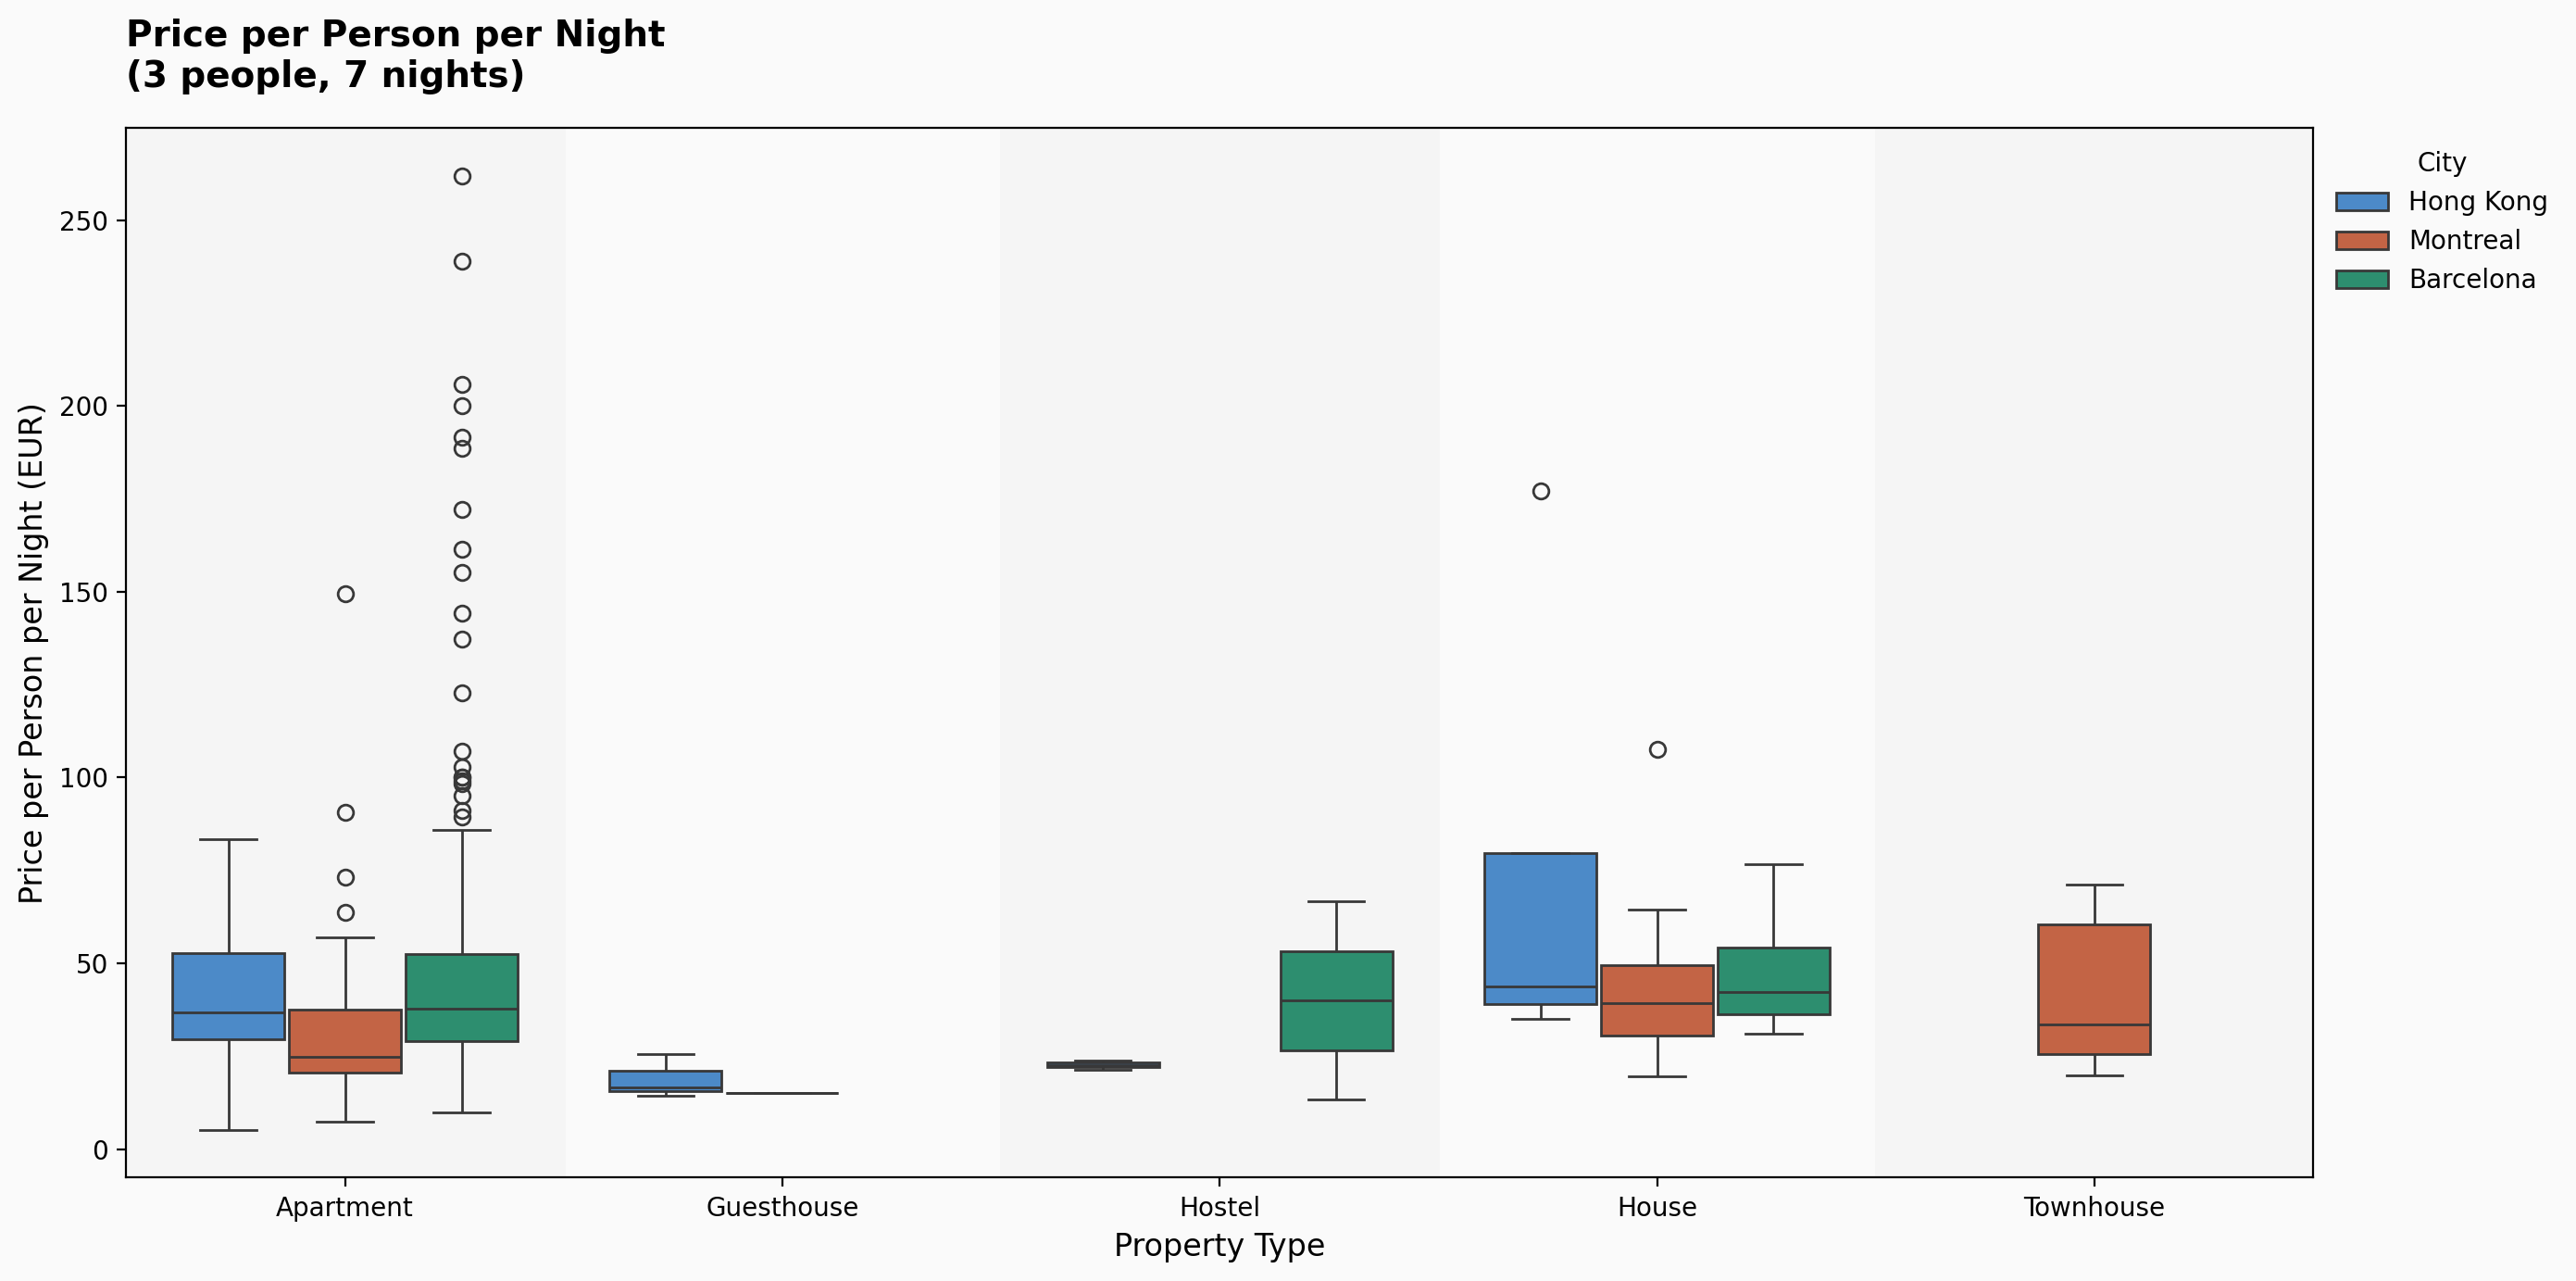

In [40]:
plot_price_per_person_per_night()

### Result analysis and interpretation


Prices per person per night differ across cities and property types for listings available for a 7-night stay within the next 365 days. The analysis uses boxplots supported by summary statistics, including medians, quartiles, and whiskers, which represent the spread of non-outlier values. These measures allow comparison of central price levels, variability within the middle 50% of listings, and the presence of extreme values beyond the whiskers.

Apartments remain the most informative category due to the largest number of observations in all cities. Montreal shows the lowest median apartment price (24.78 euros) and the narrowest interquartile range (approximately 20.57 to 37.49), indicating both lower price levels and more consistent pricing. In contrast, Barcelona and Hong Kong have similar median levels (37.67 and 36.90 euros, respectively) but wider interquartile ranges, suggesting greater variability among central values. Barcelona, in particular, exhibits the widest overall range of apartment prices, from about 9.76 to 261.90 euros per person per night.

The difference between whiskers and maximum values highlights the role of high-price listings. In Hong Kong, the upper whisker coincides with the maximum (83.32 euros), indicating no outliers. In contrast, Barcelona contains values beyond its upper whisker (around 87.65 euros), extending to over 260 euros. These high values suggest the presence of a premium segment rather than isolated anomalies.

Other property types (houses, hostels, guesthouses, and townhouses) have relatively small sample sizes after filtering, which limits the reliability of comparisons. Overall, apartments provide the most reliable basis for comparison, showing lower and more consistent prices in Montreal and greater variability, including a high-end segment, in Barcelona.


**Additional visualization (log scale with observations)**


The conclusions above can be further examined using the plot below, which applies a logarithmic scale to better reveal the distribution of observations across the full price range. The plot below overlays individual observations on the boxplot. Dots are slightly shifted horizontally to avoid overlap; only the vertical position represents price.


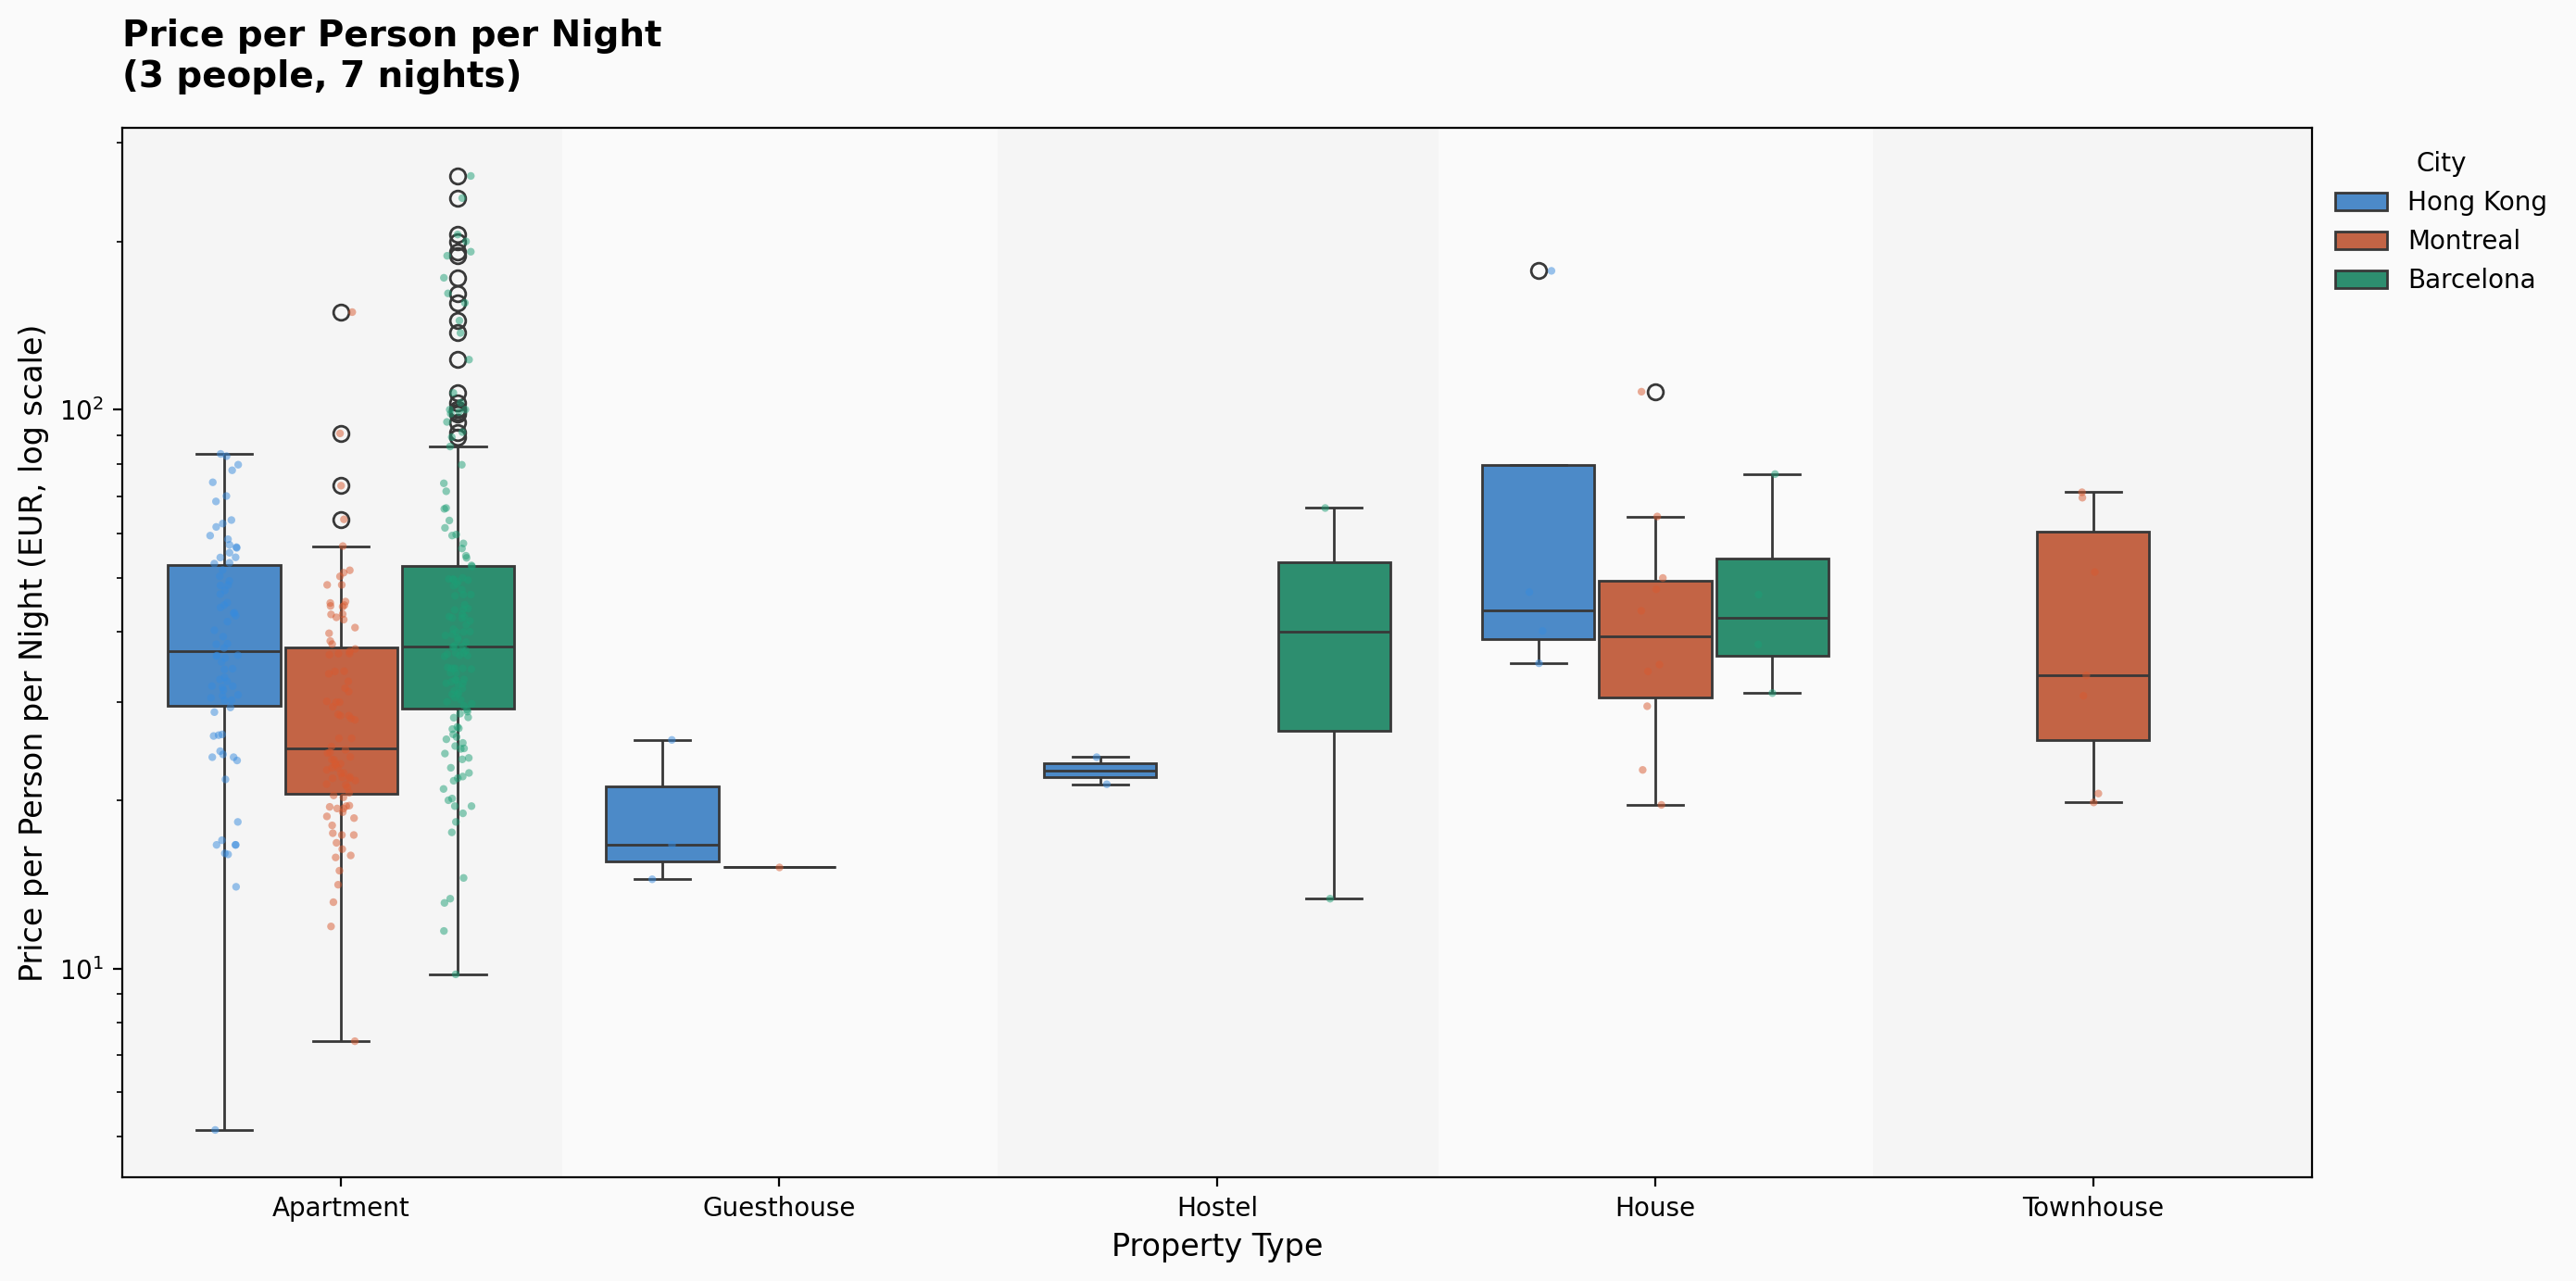

In [41]:
plot_price_per_person_per_night(log_scale=True, show_points=True)

## A2. Query Pipeline Analysis


### Assumptions

- Stay duration = 7 nights
- Number of guests = 3 people

The analysis focuses only on listings located in New York.

We use `accommodates >= 3`, because the property must be able to host three people.

We assume short-term availability and use availability_365 ≥ 7 to ensure a 7-night stay is possible. Additionally, listings must allow such a stay under booking rules, defined as minimum_nights ≤ 7 ≤ maximum_nights.

Only properties that contain all required amenities are included:

- Wifi
- Hair dryer
- 24-hour check-in
- Air conditioning
- Bed linens

Amenities are matched exactly as written in the dataset. Similar amenities (e.g., “Self check-in”, “Lockbox”, “Keypad”) are not included, as they do not exactly correspond to “24-hour check-in”.

Listings are divided into two categories:

- Wheelchair-friendly: at least one of  
  (Elevator, Ground floor access, Wheelchair accessible, Wide doorway, Disabled parking spot)

- Family-friendly: at least one of  
  (Crib, Family/kid friendly, Stair gates, Table corner guards)

A listing may belong to both categories simultaneously.

Due to strict filtering conditions, fewer than five property types may remain in the final dataset. In such cases, all available property types are used for visualization instead of forcing five categories.

### Price

Only structured price-related fields are used. When available, `weekly_price` was incorporated by comparing it to the cost of seven nightly prices (`price` \* 7), and the lower of the two was used in the total price calculation. If the nightly price was missing, the weekly price was used directly. This ensures that weekly discounts are consistently accounted for when they reduce the total cost.

Price includes:

- Base accommodation cost (`price` \* 7 or `weekly_price`, whichever is lower; if price is missing, weekly_price is used)
- `cleaning_fee`
- Extra person fee (`extra_person_total`, if applicable)

For 3 people staying 7 nights:

`total_price` = (`price` \* 7 or `weekly_price`) + `cleaning_fee` + `extra_person_total`

`price_per_person_per_night` = `total_price` / (3 \* 7)

If `weekly_price` is available, it is converted to a per-night value and used only when it results in a lower total cost.

### Extra people rule

- `guests_included` = number of guests covered by base price
- `extra_people` = fee per extra guest per night

For 3 guests:

`extra_guests` = max(0, 3 - guests_included)

`extra_person_charge` = extra*guests * extra*people * 7

### Missing values

Missing values are handled as follows:

- `cleaning_fee = 0`
- `extra_people = 0`
- `guests_included = 1`

If `price` is missing but `weekly_price` is available, the weekly price is used.

Listings with no usable price information are excluded.

### Price per Person per Night by Property Type and Category

The analysis focuses on the most frequently occurring property types within each category. Due to overlap between categories, the same property types are used for comparison between wheelchair-friendly and family-friendly listings.


In [42]:
REQUIRED_AMENITIES = [
    "Wifi",
    "Hair dryer",
    "24-hour check-in",
    "Air conditioning",
    "Bed linens",
]

WHEELCHAIR_AMENITIES = [
    "Elevator",
    "Ground floor access",
    "Wheelchair accessible",
    "Wide doorway",
    "Disabled parking spot",
]

FAMILY_AMENITIES = ["Crib", "Family/kid friendly", "Stair gates", "Table corner guards"]

# Query 1:
# Select New York listings suitable for a 7-night stay for ≥3 guests:
# - contain all required amenities
# - accommodate at least 3 guests
# - have ≥7 available days in the next 365 days
# - allow a 7-night stay (minimum_nights ≤ 7 ≤ maximum_nights)
# - have a non-null price (price or weekly_price)
query1 = {
    "$match": {
        "address.market": "New York",
        "amenities": {"$all": REQUIRED_AMENITIES},
        "accommodates": {"$gte": 3},
        "availability.availability_365": {"$gte": 7},
        "$or": [{"price": {"$ne": None}}, {"weekly_price": {"$ne": None}}],
        "minimum_nights": {"$lte": 7},
        "maximum_nights": {"$gte": 7},
    }
}

# Query 2:
# Keep only fields needed for category checks and price calculation.
query2 = {
    "$project": {
        "property_type": 1,
        "amenities": 1,
        "price": 1,
        "weekly_price": 1,
        "cleaning_fee": 1,
        "extra_people": 1,
        "guests_included": 1,
    }
}

# Query 3:
# Convert price-related fields to numeric values.
# Missing cleaning_fee and extra_people are treated as 0.
# Missing guests_included is treated as 1.
# weekly_price is converted only when it exists.
query3 = {
    "$addFields": {
        "price_num": {"$toDouble": "$price"},
        "weekly_price_num": {
            "$cond": [
                {"$ne": ["$weekly_price", None]},
                {"$toDouble": "$weekly_price"},
                None,
            ]
        },
        "cleaning_fee_num": {"$toDouble": {"$ifNull": ["$cleaning_fee", 0]}},
        "extra_people_num": {"$toDouble": {"$ifNull": ["$extra_people", 0]}},
        "guests_included_num": {"$ifNull": ["$guests_included", 1]},
    }
}

# Query 4:
# Mark whether each listing is wheelchair-friendly and/or family-friendly.
# A listing belongs to a category if it contains at least one amenity
# from the corresponding category list.
query4 = {
    "$addFields": {
        "wheelchair_friendly": {
            "$gt": [
                {"$size": {"$setIntersection": ["$amenities", WHEELCHAIR_AMENITIES]}},
                0,
            ]
        },
        "family_friendly": {
            "$gt": [
                {"$size": {"$setIntersection": ["$amenities", FAMILY_AMENITIES]}},
                0,
            ]
        },
    }
}

# Query 5:
# Keep only listings that belong to at least one of the two categories.
query5 = {"$match": {"$or": [{"wheelchair_friendly": True}, {"family_friendly": True}]}}

# Query 6:
# Calculate how many of the 3 guests are not covered by the base price.
query6 = {
    "$addFields": {
        "extra_guest_count": {"$max": [0, {"$subtract": [3, "$guests_included_num"]}]}
    }
}

# Query 7:
# Compute the 7-night accommodation cost as the lower of:
# - nightly price * 7
# - weekly_price
# Use weekly_price only if it exists and either daily price is missing
# or weekly_price is cheaper than 7 nights of daily price
query7 = {
    "$addFields": {
        "base_accommodation_7_nights": {
            "$cond": [
                {
                    "$and": [
                        {"$ne": ["$weekly_price_num", None]},
                        {
                            "$or": [
                                {"$eq": ["$price_num", None]},
                                {
                                    "$lt": [
                                        "$weekly_price_num",
                                        {"$multiply": ["$price_num", 7]},
                                    ]
                                },
                            ]
                        },
                    ]
                },
                "$weekly_price_num",
                {"$multiply": ["$price_num", 7]},
            ]
        }
    }
}

# Query 8:
# Add cleaning fee and extra guest charges to get the full 7-night total price.
query8 = {
    "$addFields": {
        "total_price_7_nights": {
            "$add": [
                "$base_accommodation_7_nights",
                "$cleaning_fee_num",
                {"$multiply": ["$extra_people_num", "$extra_guest_count", 7]},
            ]
        }
    }
}

# Query 9:
# Convert the 7-night total price into price per person per night
# for 3 people staying 7 nights.
# Also create a categories array so that listings belonging to both
# groups can appear once in each category.
query9 = {
    "$addFields": {
        "price_per_person_per_night": {"$divide": ["$total_price_7_nights", 21]},
        "categories": [
            {"$cond": ["$wheelchair_friendly", "Wheelchair-friendly", None]},
            {"$cond": ["$family_friendly", "Family-friendly", None]},
        ],
    }
}

# Query 10:
# Expand the categories array so that each listing-category combination
# becomes a separate output record.
query10 = {"$unwind": "$categories"}

# Query 11:
# Remove empty category values created for categories that do not apply.
query11 = {"$match": {"categories": {"$ne": None}}}

# Query 12:
# Keep only the fields needed for manual checking of the calculation.
query12 = {
    "$project": {
        "_id": 0,
        "property_type": 1,
        "category": "$categories",
        "price": 1,
        "weekly_price": 1,
        "cleaning_fee": 1,
        "extra_people": 1,
        "guests_included": 1,
        "price_per_person_per_night": 1,
    }
}

# Combine all stages into one aggregation pipeline.
pipeline_a2 = [
    query1,
    query2,
    query3,
    query4,
    query5,
    query6,
    query7,
    query8,
    query9,
    query10,
    query11,
    query12,
]

In [43]:
results_a2 = list(db.listings.aggregate(pipeline_a2))
df_a2 = pd.DataFrame(results_a2)

In [44]:
df_a2

,property_type,price,cleaning_fee,extra_people,guests_included,price_per_person_per_night,category,weekly_price
0,Apartment,250.00,125.00,0.00,1,89.285714,Family-friendly,NaN
1,Apartment,199.00,105.00,25.00,2,79.666667,Wheelchair-friendly,NaN
2,Apartment,199.00,105.00,25.00,2,79.666667,Family-friendly,NaN
3,Apartment,439.00,180.00,40.00,4,70.476190,Family-friendly,1300.00
4,Apartment,89.00,0.00,40.00,1,56.333333,Wheelchair-friendly,NaN
5,Apartment,89.00,0.00,40.00,1,56.333333,Family-friendly,NaN
6,Apartment,93.00,35.00,25.00,2,39.190476,Wheelchair-friendly,613.00
7,Apartment,149.00,99.00,25.00,2,62.714286,Family-friendly,NaN
8,Apartment,85.00,25.00,20.00,2,36.190476,Wheelchair-friendly,NaN
9,Apartment,85.00,25.00,20.00,2,36.190476,Family-friendly,NaN


In [45]:
pprint(df_a2["category"].value_counts())
pprint("")
pprint(df_a2["property_type"].value_counts())

category
Family-friendly        7
Wheelchair-friendly    5
Name: count, dtype: int64
''
property_type
Apartment    11
Townhouse     1
Name: count, dtype: int64


In [46]:
def plot_price_per_person_per_night_by_category(
    df, category_order=("Wheelchair-friendly", "Family-friendly"), top_n=5
):
    """
    Plot one chart with side-by-side boxplots for the top property types
    selected separately within each category.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain:
        - category
        - property_type
        - price_per_person_per_night

    category_order : tuple/list
        Order of categories in the legend and box positions.

    top_n : int
        Number of most numerous property types to keep per category.
    """

    PALETTE = {"Wheelchair-friendly": "#378ADD", "Family-friendly": "#D85A30"}

    # Count observations for each category-property_type combination
    counts = df.groupby(["category", "property_type"]).size().reset_index(name="count")

    # Rank property types separately within each category
    counts["rank"] = counts.groupby("category")["count"].rank(
        method="first", ascending=False
    )

    # Keep only top N property types per category
    top_counts = counts[counts["rank"] <= top_n].copy()

    # Build x-axis order as union of selected property types, preserving rank order
    prop_order = []
    for cat in category_order:
        subset = top_counts[top_counts["category"] == cat].sort_values(
            ["rank", "property_type"]
        )
        for prop in subset["property_type"]:
            if prop not in prop_order:
                prop_order.append(prop)

    # Keep only rows belonging to selected (category, property_type) pairs
    top_pairs = set(zip(top_counts["category"], top_counts["property_type"]))
    plot_df = df[
        df[["category", "property_type"]].apply(tuple, axis=1).isin(top_pairs)
    ].copy()

    # Plot
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    # Background stripes
    for i in range(0, len(prop_order), 2):
        ax.axvspan(i - 0.5, i + 0.5, color="#F5F5F5", zorder=0)

    sns.boxplot(
        data=plot_df,
        x="property_type",
        y="price_per_person_per_night",
        hue="category",
        order=prop_order,
        hue_order=category_order,
        palette=PALETTE,
        showfliers=True,
        ax=ax,
    )

    ax.set_title(
        "Price per Person per Night by Property Type and Category\n(3 people, 7 nights)",
        fontsize=14,
        fontweight="bold",
        pad=16,
        loc="left",
    )

    ax.set_xlabel("Property Type", fontsize=12)
    ax.set_ylabel("Price per Person per Night (USD)", fontsize=12)

    # Clean legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[: len(category_order)],
        labels[: len(category_order)],
        title="Category",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1, 1),
    )

    plt.tight_layout()
    plt.show()

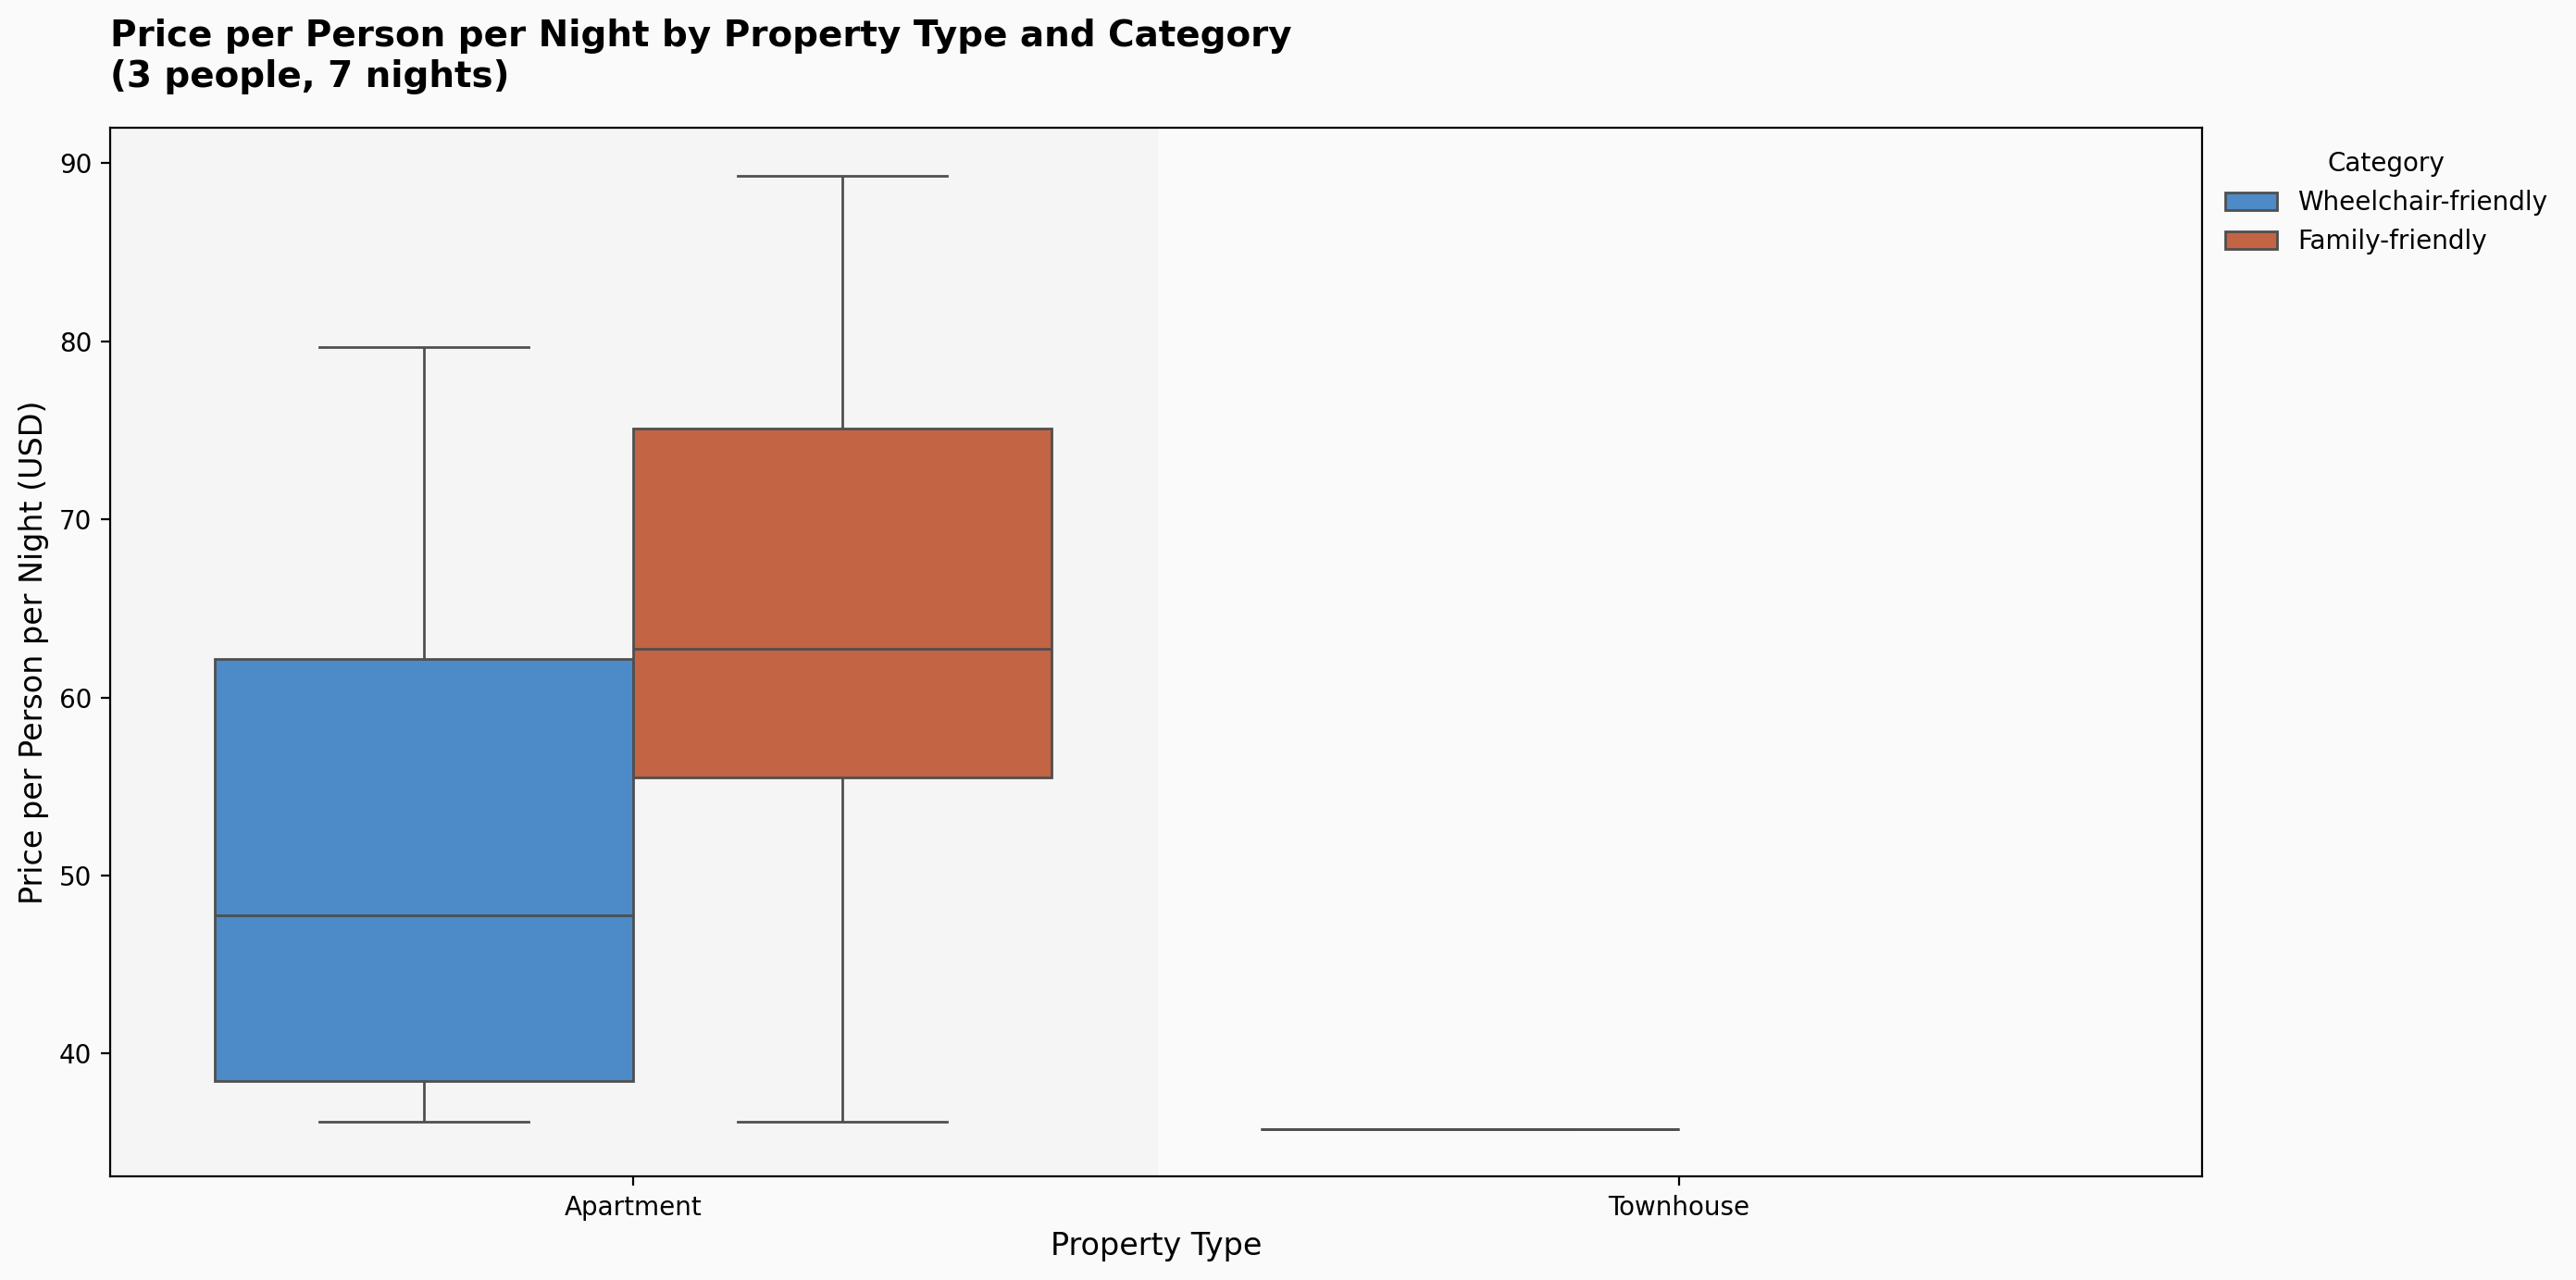

In [47]:
plot_price_per_person_per_night_by_category(df_a2)

In [48]:
comparison_table = (
    df_a2.groupby(["category", "property_type"])["price_per_person_per_night"]
    .agg(
        count="count",
        min="min",
        q1=lambda x: x.quantile(0.25),
        median="median",
        q3=lambda x: x.quantile(0.75),
        max="max",
    )
    .reset_index()
)

# Compute IQR
comparison_table["iqr"] = comparison_table["q3"] - comparison_table["q1"]

# Compute theoretical whiskers (1.5 * IQR rule)
comparison_table["lower_whisker"] = (
    comparison_table["q1"] - 1.5 * comparison_table["iqr"]
)
comparison_table["upper_whisker"] = (
    comparison_table["q3"] + 1.5 * comparison_table["iqr"]
)

# Cap whiskers to actual data range (important!)
comparison_table["lower_whisker"] = comparison_table[["lower_whisker", "min"]].max(
    axis=1
)
comparison_table["upper_whisker"] = comparison_table[["upper_whisker", "max"]].min(
    axis=1
)

# Optional: sort for readability
comparison_table = comparison_table.sort_values(
    ["category", "count"], ascending=[True, False]
)

comparison_table.round(2)

,category,property_type,count,min,q1,median,q3,max,iqr,lower_whisker,upper_whisker
0,Family-friendly,Apartment,7,36.19,55.50,62.71,75.07,89.29,19.57,36.19,89.29
1,Wheelchair-friendly,Apartment,4,36.19,38.44,47.76,62.17,79.67,23.73,36.19,79.67
2,Wheelchair-friendly,Townhouse,1,35.76,35.76,35.76,35.76,35.76,0.00,35.76,35.76


**Index optimization**


In [49]:
# Remove all existing indexes and clear the query plan cache to ensure a fresh execution environment
db.listings.drop_indexes()
db.command({"planCacheClear": "listings"})

# Display current index metadata for verification
pprint(db.listings.index_information())

# Run the aggregation pipeline with explain("executionStats") to collect detailed performance metrics
explain_before = db.command(
    {
        "explain": {"aggregate": "listings", "pipeline": pipeline_a2, "cursor": {}},
        "verbosity": "executionStats",
    }
)

# Save the explain output (query plan and execution statistics) to a JSON file for further analysis
with open("taskA2/taskA2_before.json", "w") as f:
    json.dump(explain_before, f)

{'_id_': {'key': [('_id', 1)], 'v': 2}}


In [50]:
# Load previously saved explain output (query plan and execution statistics) from JSON file
with open("taskA2/taskA2_before.json", "r", encoding="utf-8") as f:
    explain_before = json.load(f)
explain_before

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listings',
     'parsedQuery': {'$and': [{'$or': [{'price': {'$not': {'$eq': None}}},
         {'weekly_price': {'$not': {'$eq': None}}}]},
       {'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'minimum_nights': {'$lte': 7}},
       {'accommodates': {'$gte': 3}},
       {'availability.availability_365': {'$gte': 7}},
       {'maximum_nights': {'$gte': 7}}]},
     'indexFilterSet': False,
     'queryHash': 'BC7AF5C4',
     'planCacheShapeHash': 'BC7AF5C4',
     'planCacheKey': '9E78685E',
     'optimizationTimeMillis': 0,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimil

In [51]:
# Remove all existing indexes and clear the query plan cache
db.listings.drop_indexes()
db.command({"planCacheClear": "listings"})

# Create an index on the city field (address.market) to support filtering by location
db.listings.create_index([("address.market", 1)])
# Display index metadata to verify index creation
pprint(db.listings.index_information())

# Run the aggregation pipeline with explain("executionStats")
explain_idx_address_market = db.command(
    {
        "explain": {"aggregate": "listings", "pipeline": pipeline_a2, "cursor": {}},
        "verbosity": "executionStats",
    }
)

# Save the explain output
with open("taskA2/taskA2_idx_address_market.json", "w") as f:
    json.dump(explain_idx_address_market, f)

{'_id_': {'key': [('_id', 1)], 'v': 2},
 'address.market_1': {'key': [('address.market', 1)], 'v': 2}}


In [52]:
# Load previously saved explain output
with open("taskA2/taskA2_idx_address_market.json", "r", encoding="utf-8") as f:
    explain_idx_address_market = json.load(f)
explain_idx_address_market

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listings',
     'parsedQuery': {'$and': [{'$or': [{'price': {'$not': {'$eq': None}}},
         {'weekly_price': {'$not': {'$eq': None}}}]},
       {'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'minimum_nights': {'$lte': 7}},
       {'accommodates': {'$gte': 3}},
       {'availability.availability_365': {'$gte': 7}},
       {'maximum_nights': {'$gte': 7}}]},
     'indexFilterSet': False,
     'queryHash': 'BC7AF5C4',
     'planCacheShapeHash': 'BC7AF5C4',
     'planCacheKey': '4A12DFA5',
     'optimizationTimeMillis': 0,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimil

In [53]:
# Remove all existing indexes and clear the query plan cache
db.listings.drop_indexes()
db.command({"planCacheClear": "listings"})

# Create a compound index on address.market and availability.availability_365
# to optimize queries filtering by location and availability within the next 365 days
db.listings.create_index([("address.market", 1), ("availability.availability_365", 1)])
# Display index metadata to verify index creation
pprint(db.listings.index_information())

# Run the aggregation pipeline with explain("executionStats")
explain_compound_idx_market_availability = db.command(
    {
        "explain": {"aggregate": "listings", "pipeline": pipeline_a2, "cursor": {}},
        "verbosity": "executionStats",
    }
)

# Save the explain output
with open("taskA2/taskA2_compound_idx_market_availability.json", "w") as f:
    json.dump(explain_compound_idx_market_availability, f)

{'_id_': {'key': [('_id', 1)], 'v': 2},
 'address.market_1_availability.availability_365_1': {'key': [('address.market',
                                                               1),
                                                              ('availability.availability_365',
                                                               1)],
                                                      'v': 2}}


In [54]:
with open(
    "taskA2/taskA2_compound_idx_market_availability.json", "r", encoding="utf-8"
) as f:
    explain_compound_idx_market_availability = json.load(f)
explain_compound_idx_market_availability

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listings',
     'parsedQuery': {'$and': [{'$or': [{'price': {'$not': {'$eq': None}}},
         {'weekly_price': {'$not': {'$eq': None}}}]},
       {'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'minimum_nights': {'$lte': 7}},
       {'accommodates': {'$gte': 3}},
       {'availability.availability_365': {'$gte': 7}},
       {'maximum_nights': {'$gte': 7}}]},
     'indexFilterSet': False,
     'queryHash': 'BC7AF5C4',
     'planCacheShapeHash': 'BC7AF5C4',
     'planCacheKey': '8FFCC7DF',
     'optimizationTimeMillis': 0,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimil

In [55]:
# Remove all existing indexes and clear the query plan cache
db.listings.drop_indexes()
db.command({"planCacheClear": "listings"})

# Create a compound index on address.market, availability.availability_365, and accommodates
# to optimize queries filtering by location, availability within the next 365 days,
# and number of guests (accommodates)
db.listings.create_index(
    [("address.market", 1), ("availability.availability_365", 1), ("accommodates", 1)]
)
# Display index metadata to verify index creation
pprint(db.listings.index_information())

# Run the aggregation pipeline with explain("executionStats")
explain_compound_idx_market_availability_accommodates = db.command(
    {
        "explain": {"aggregate": "listings", "pipeline": pipeline_a2, "cursor": {}},
        "verbosity": "executionStats",
    }
)

# Save the explain output
with open("taskA2/taskA2_compound_idx_market_availability_accommodates.json", "w") as f:
    json.dump(explain_compound_idx_market_availability_accommodates, f)

{'_id_': {'key': [('_id', 1)], 'v': 2},
 'address.market_1_availability.availability_365_1_accommodates_1': {'key': [('address.market',
                                                                              1),
                                                                             ('availability.availability_365',
                                                                              1),
                                                                             ('accommodates',
                                                                              1)],
                                                                     'v': 2}}


In [56]:
with open(
    "taskA2/taskA2_compound_idx_market_availability_accommodates.json",
    "r",
    encoding="utf-8",
) as f:
    explain_compound_idx_market_availability_accommodates = json.load(f)
explain_compound_idx_market_availability_accommodates

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listings',
     'parsedQuery': {'$and': [{'$or': [{'price': {'$not': {'$eq': None}}},
         {'weekly_price': {'$not': {'$eq': None}}}]},
       {'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'minimum_nights': {'$lte': 7}},
       {'accommodates': {'$gte': 3}},
       {'availability.availability_365': {'$gte': 7}},
       {'maximum_nights': {'$gte': 7}}]},
     'indexFilterSet': False,
     'queryHash': 'BC7AF5C4',
     'planCacheShapeHash': 'BC7AF5C4',
     'planCacheKey': 'D09238B8',
     'optimizationTimeMillis': 0,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimil

In [57]:
# Remove all existing indexes and clear the query plan cache
db.listings.drop_indexes()
db.command({"planCacheClear": "listings"})

# Create a compound index on address.market, availability.availability_365, accommodates, and minimum_nights
# to optimize queries filtering by location, availability within the next 365 days,
# number of guests, and minimum stay requirements
db.listings.create_index(
    [
        ("address.market", 1),
        ("availability.availability_365", 1),
        ("accommodates", 1),
        ("minimum_nights", 1),
    ]
)
# Display index metadata to verify index creation
pprint(db.listings.index_information())

# Run the aggregation pipeline with explain("executionStats")
explain_compound_idx_market_availability_accommodates_minimum_nights = db.command(
    {
        "explain": {"aggregate": "listings", "pipeline": pipeline_a2, "cursor": {}},
        "verbosity": "executionStats",
    }
)

# Save the explain output
with open(
    "taskA2/taskA2_compound_idx_market_availability_accommodates_minimum_nights.json",
    "w",
) as f:
    json.dump(explain_compound_idx_market_availability_accommodates_minimum_nights, f)

{'_id_': {'key': [('_id', 1)], 'v': 2},
 'address.market_1_availability.availability_365_1_accommodates_1_minimum_nights_1': {'key': [('address.market',
                                                                                               1),
                                                                                              ('availability.availability_365',
                                                                                               1),
                                                                                              ('accommodates',
                                                                                               1),
                                                                                              ('minimum_nights',
                                                                                               1)],
                                                                                      'v': 2}}


In [58]:
with open(
    "taskA2/taskA2_compound_idx_market_availability_accommodates_minimum_nights.json",
    "r",
    encoding="utf-8",
) as f:
    explain_compound_idx_market_availability_accommodates_minimum_nights = json.load(f)
explain_compound_idx_market_availability_accommodates_minimum_nights

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'sample_airbnb.listings',
     'parsedQuery': {'$and': [{'$or': [{'price': {'$not': {'$eq': None}}},
         {'weekly_price': {'$not': {'$eq': None}}}]},
       {'address.market': {'$eq': 'New York'}},
       {'amenities': {'$eq': 'Wifi'}},
       {'amenities': {'$eq': 'Hair dryer'}},
       {'amenities': {'$eq': '24-hour check-in'}},
       {'amenities': {'$eq': 'Air conditioning'}},
       {'amenities': {'$eq': 'Bed linens'}},
       {'minimum_nights': {'$lte': 7}},
       {'accommodates': {'$gte': 3}},
       {'availability.availability_365': {'$gte': 7}},
       {'maximum_nights': {'$gte': 7}}]},
     'indexFilterSet': False,
     'queryHash': 'BC7AF5C4',
     'planCacheShapeHash': 'BC7AF5C4',
     'planCacheKey': '445F9C13',
     'optimizationTimeMillis': 0,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimil

In [59]:
df_explain = utils.compare_explain_outputs(
    explain_before,
    explain_idx_address_market,
    explain_compound_idx_market_availability,
    explain_compound_idx_market_availability_accommodates,
    explain_compound_idx_market_availability_accommodates_minimum_nights,
    labels=[
        "before_optimization",
        "1st_optimization_idx_address_market",
        "2nd_optimization_compound_idx_market_availability",
        "3rd_optimization_compound_idx_market_availability_accomodates",
        "4th_optimization_compound_idx_market_availability_accomodates_min_nights",
    ],
)
# ✅ FIX: replace 0 or None with "N/A"
df_explain["memory_usage"] = df_explain["memory_usage"].replace({0: "N/A", None: "N/A"})
df_explain.set_index("version")

,stage_type,execution_time_ms,documents_examined,keys_examined,memory_usage
version,,,,,
before_optimization,COLLSCAN,13,5555,0,N/A
1st_optimization_idx_address_market,IXSCAN,3,607,607,N/A
2nd_optimization_compound_idx_market_availability,IXSCAN,3,379,379,N/A
3rd_optimization_compound_idx_market_availability_accomodates,IXSCAN,3,175,315,N/A
4th_optimization_compound_idx_market_availability_accomodates_min_nights,IXSCAN,3,146,314,N/A


### Result analysis and interpretation


Strict filtering criteria—such as locality (New York), availability, required amenities, and accessibility—significantly reduce the number of listings. As a result, only a few property types remain: apartments for family-friendly listings, and apartments and townhouses for wheelchair-friendly listings.
Apartments allow meaningful comparison, as they appear in both categories. Median prices are higher for family-friendly apartments (62.71) than for wheelchair-friendly ones (47.76). The interquartile range is slightly narrower for family-friendly apartments (55.50–75.07) compared to wheelchair-friendly ones (38.44–62.17), suggesting somewhat lower variability for family-friendly apartments in the central 50% of values. Family-friendly apartments also reach a higher maximum (89.29 versus 79.67), indicating a broader upper price range.
Townhouses appear only once, so no variability can be observed.

---

**Indexing impact on query execution**

Initially, the query scans all 5,555 documents. Adding an index on address.market reduces this to 607 by restricting the search to New York listings.
Further compound indexes reduce the number of examined documents to 146, improving query precision. However, later optimizations provide smaller improvements, indicating diminishing returns.
Overall, indexing significantly improves performance by reducing the amount of data processed. Memory usage is reported as N/A, as it is not provided for this query.


## A3. Analytical Price Suggestion


### Assumptions

- Cities analyzed: Barcelona, Hong Kong, Montreal
- Property types analyzed: Apartment, Guesthouse, Hostel, House, Townhouse
- Only listings with missing `price` are predicted
- Predictions are made using similar listings with known prices from the **same city**, since prices in different cities may be in different currencies.

Listings must have the following fields available:

- `city`
- `property_type`
- `room_type`
- `accommodates`

Listings with missing values in these key fields are excluded. Extreme values are also filtered out to keep comparisons realistic.

### Price Definition

The comparison is based on price per person per night in local currency:

`ppn_local = price / base_guests`

The final suggested listing price is:

`price_suggestion = predicted ppn_local × base_guests`

### Base Guests Assumption

- If `guests_included > 0`, then `base_guests = guests_included`
- Otherwise, `base_guests = 1`

This assumes that `guests_included` better reflects the host’s base pricing logic than full capacity (`accommodates`).

### Features Used for Similarity

Listings are compared using:

- Numerical features: `accommodates`, `bedrooms`, `bathrooms`, `beds`, `review_score_avg`, `minimum_nights`
- Categorical features: `property_type`, `room_type`

To incorporate qualitative aspects, review_score_avg is used as a proxy for guest sentiment. This approximates sentiment analysis of raw reviews (as suggested in the task) without directly processing text data.

Categorical variables are one-hot encoded, and all features are standardized before KNN distance calculation.

### Outlier Handling

Outliers are removed within each `(city, property_type)` group based on `ppn_local`.

- Small groups are handled with simple ratio or median rules
- Larger groups use the standard IQR rule

This prevents unusual prices from distorting the suggested values.

### Prediction Logic

A K-nearest neighbors approach is used with up to 5 neighbors.

For each listing with a missing price, the prediction follows this fallback order:

1. Mean price per person per night of neighbors with the same `city`, `property_type`, and `room_type`
2. If not enough such matches exist, mean of neighbors with the same `city` and `property_type`
3. Otherwise, median of all top-k neighbors in the same city

This gives priority to the most similar listings while still allowing predictions when exact matches are limited.

### Missing Values

- Missing numerical feature values are filled with `0`
- Missing categorical values are filled with `"MISSING"`

If a city has no known-price listings, no prediction is produced for that city, although in the final results all missing prices were successfully predicted.

### Output

Each listing with a missing price receives:

- `price_suggestion`
- `ppn_pred_local`
- `neighbor_count`
- `prediction_rule`

Only suggested prices are then used for the boxplots of:

- Apartment
- Guesthouse
- Hostel
- House
- Townhouse

across:

- Barcelona
- Hong Kong
- Montreal

For comparable visualization on the final plot, the suggested prices are converted from local currency to euros.


In [60]:
# Retrieve all documents from the 'listings' collection and store them as a list
docs = list(db.listings.find())

In [61]:
# Helper function to convert MongoDB Decimal128 values to Python float
def to_float(x):
    if isinstance(x, Decimal128):
        return float(x.to_decimal())
    return x


# Extract relevant fields from each document and build a structured list of rows
rows = []
for d in docs:
    addr = d.get("address", {})  # safely access nested address field
    rs = d.get("review_scores", {})  # safely access nested review_scores field

    rows.append(
        {
            "_id": d.get("_id"),
            "price": to_float(d.get("price")),  # listing price (local currency)
            "accommodates": to_float(d.get("accommodates")),
            "bedrooms": to_float(d.get("bedrooms")),
            "bathrooms": to_float(d.get("bathrooms")),
            "beds": to_float(d.get("beds")),
            "property_type": d.get("property_type"),
            "room_type": d.get("room_type"),
            "city": addr.get("market"),  # extract city from address
            "guests_included": to_float(d.get("guests_included")),
            "review_scores_accuracy": to_float(rs.get("review_scores_accuracy")),
            "review_scores_cleanliness": to_float(rs.get("review_scores_cleanliness")),
            "review_scores_checkin": to_float(rs.get("review_scores_checkin")),
            "review_scores_communication": to_float(
                rs.get("review_scores_communication")
            ),
            "review_scores_location": to_float(rs.get("review_scores_location")),
            "review_scores_value": to_float(rs.get("review_scores_value")),
            "review_scores_rating": to_float(rs.get("review_scores_rating")),
            "minimum_nights": to_float(d.get("minimum_nights")),
        }
    )

# Convert the list of dictionaries into a pandas DataFrame for analysis
df = pd.DataFrame(rows)

In [62]:
# Determine the baseline number of guests for a listing:
# use 'guests_included' if available and greater than 0, otherwise default to 1
def get_base_guests(row):
    if pd.notna(row["guests_included"]) and row["guests_included"] > 0:
        return row["guests_included"]
    return 1

In [63]:
# Convert selected columns to numeric format;
# invalid parsing will be set to NaN (errors="coerce")
for col in [
    "price",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "guests_included",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [64]:
# Filter dataset to keep only rows with essential fields which must not be missing
df = df[
    df["city"].notna()
    & df["property_type"].notna()
    & df["room_type"].notna()
    & df["accommodates"].notna()
].copy()

In [65]:
# accommodates must be positive
df = df[df["accommodates"] > 0].copy()

# known prices must be positive if present
df = df[(df["price"].isna()) | (df["price"] > 0)].copy()

# allow missing bedrooms/bathrooms/beds, but remove negative values
for col in ["bedrooms", "bathrooms", "beds"]:
    df = df[(df[col].isna()) | (df[col] >= 0)].copy()

In [66]:
# Remove extreme or unrealistic values to reduce the impact of outliers.
df = df[(df["accommodates"] <= 20)].copy()
df = df[(df["bedrooms"].isna()) | (df["bedrooms"] <= 20)].copy()
df = df[(df["bathrooms"].isna()) | (df["bathrooms"] <= 20)].copy()
df = df[(df["beds"].isna()) | (df["beds"] <= 30)].copy()

In [67]:
score_cols = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "review_scores_rating",
]

# 1. Create average score
df["review_score_avg"] = df[score_cols].mean(axis=1)

# 2. Fill by city mean (primary)
df["review_score_avg"] = df.groupby("city")["review_score_avg"].transform(
    lambda x: x.fillna(x.mean())
)

# 3. Fill remaining by global mean (fallback)
df["review_score_avg"] = df["review_score_avg"].fillna(df["review_score_avg"].mean())

In [68]:
# Fill by city mean (primary)
df["minimum_nights"] = df.groupby("city")["minimum_nights"].transform(
    lambda x: x.fillna(x.mean())
)

# Fill remaining by global mean (fallback)
df["minimum_nights"] = df["minimum_nights"].fillna(df["minimum_nights"].mean())

In [69]:
# Compute the baseline number of guests for each listing
df["base_guests"] = df.apply(get_base_guests, axis=1)

# Split the dataset into two subsets:
# - 'known': listings with available price values (used for modeling/training)
# - 'missing': listings without price values (to generate price suggestions)
known = df[df["price"].notna()].copy()
missing = df[df["price"].isna()].copy()

# Calculate price per person per night (ppn) in local currency
known["ppn_local"] = known["price"] / known["base_guests"]

# Remove invalid or non-positive ppn values to ensure meaningful analysis
known = known[known["ppn_local"] > 0].copy()

In [70]:
# Remove outliers in 'ppn_local' within each group using adaptive logic:
# - For very small groups (size 2–3), apply custom rules to avoid unreliable IQR:
#     * size 2: remove the larger value if it is more than 3× the smaller one
#     * size 3: keep values within [median/3, 3×median]
# - For groups with 1 observation, keep the value (insufficient data)
# - For larger groups (size ≥ 4), apply standard IQR method:
#     * compute Q1 and Q3
#     * define bounds as [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
#     * retain only values within these bounds
def remove_outliers_iqr(group):

    if len(group) == 2:
        ratio = group["ppn_local"].max() / group["ppn_local"].min()
        if ratio > 3:
            return group[group["ppn_local"] != group["ppn_local"].max()]
        return group

    if len(group) == 3:
        median = group["ppn_local"].median()
        return group[
            (group["ppn_local"] <= 3 * median) & (group["ppn_local"] >= median / 3)
        ]

    if len(group) == 1:
        return group

    # IQR-based filtering for sufficiently large groups
    q1 = group["ppn_local"].quantile(0.25)
    q3 = group["ppn_local"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return group[(group["ppn_local"] >= lower) & (group["ppn_local"] <= upper)]

In [71]:
# Apply outlier removal within each (city, property_type) group:
# - group listings by city and property type to ensure comparable price structures
# - apply the custom IQR-based filtering function to each group independently
# - group_keys=False keeps the original DataFrame structure (no hierarchical index)
# - .copy() ensures a clean DataFrame without chained assignment issues
known_clean = (
    known.groupby(["city", "property_type"], group_keys=False)
    .apply(remove_outliers_iqr)
    .copy()
)

In [72]:
print("Known before outlier removal:", len(known))
print("Known after outlier removal :", len(known_clean))

Known before outlier removal: 3869
Known after outlier removal : 3554


In [73]:
# Define numerical and categorical features for modeling
num_features = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "review_score_avg",
    "minimum_nights",
]
cat_features = ["property_type", "room_type"]

In [74]:
# Prepare feature matrices for KNN:
# - separate numerical and categorical features
# - fill missing numerical values with 0
# - one-hot encode categorical variables (handle missing as "MISSING")
# - align train and prediction sets to ensure identical columns
# - concatenate numerical and categorical features
# - standardize features using StandardScaler (fit on train, transform both)
# - return scaled feature arrays for model training and prediction


def prepare_features(train_df, pred_df):
    train_num = train_df[num_features].fillna(0).reset_index(drop=True)
    pred_num = pred_df[num_features].fillna(0).reset_index(drop=True)

    train_cat = pd.get_dummies(
        train_df[cat_features].fillna("MISSING"), columns=cat_features
    )
    pred_cat = pd.get_dummies(
        pred_df[cat_features].fillna("MISSING"), columns=cat_features
    )

    train_cat, pred_cat = train_cat.align(
        pred_cat,
        join="outer",  # take the union of all columns from both datasets
        axis=1,  # align columns (features), not rows.
        fill_value=0,  # if a category didn’t exist in one dataset → fill with 0.
    )

    X_train = pd.concat([train_num, train_cat.reset_index(drop=True)], axis=1)
    X_pred = pd.concat([pred_num, pred_cat.reset_index(drop=True)], axis=1)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_pred_scaled = scaler.transform(X_pred)

    return X_train_scaled, X_pred_scaled

In [75]:
# Predict missing prices for listings in one city using a KNN-based approach:
# - split data into known-price listings (training) and missing-price listings (prediction) for the selected city
# - return empty results if there are no missing listings in that city
# - if no training data exist for the city, return missing listings with NaN predictions
# - prepare and scale features for KNN comparison
# - find the top-k most similar known listings for each missing listing
# - apply fallback rules to estimate price per person per night (ppn):
#     1) mean of neighbors with same property type and room type
#     2) mean of neighbors with same property type
#     3) median of all top-k neighbors
# - convert predicted ppn into final price_suggestion using base_guests
# - store prediction metadata, including number of neighbors, rule used, and neighbor-level comparison details


def predict_city_knn(city_name, known_df, missing_df, k=5):
    train_city = known_df[known_df["city"] == city_name].copy()
    pred_city = missing_df[missing_df["city"] == city_name].copy()

    if len(pred_city) == 0:  # if there are no listings to predict
        return (
            pd.DataFrame(),
            pd.DataFrame(),
        )  # returns two empty DataFrames: one for predictions, one for neighbor details

    if len(train_city) == 0:
        pred_city["ppn_pred_local"] = np.nan
        pred_city["price_suggestion"] = np.nan
        pred_city["neighbor_count"] = 0
        pred_city["prediction_rule"] = np.nan
        return pred_city, pd.DataFrame()

    X_train, X_pred = prepare_features(train_city, pred_city)

    k_use = min(k, len(train_city))
    nn = NearestNeighbors(n_neighbors=k_use)
    nn.fit(X_train)

    distances, indices = nn.kneighbors(X_pred)

    train_city_reset = train_city.reset_index(drop=True)

    pred_ppn = []
    neighbor_count = []
    prediction_rule = []
    neighbor_rows = []

    for pred_pos, idx_list in enumerate(
        indices
    ):  # pred_pos → position of the current prediction row (0, 1, 2, …)
        # idx_list → list of neighbor indices for that row
        target_row = pred_city.iloc[
            pred_pos
        ]  # selects the current listing with missing price
        neighbor_subset = train_city_reset.iloc[idx_list].copy()  # get its neighbors

        # Fallback 1:
        # same city + same property_type + same room_type
        mask1 = (neighbor_subset["property_type"] == target_row["property_type"]) & (
            neighbor_subset["room_type"] == target_row["room_type"]
        )
        neighbors_lvl1 = neighbor_subset[mask1]

        # Fallback 2:
        # same city + same property_type
        mask2 = neighbor_subset["property_type"] == target_row["property_type"]
        neighbors_lvl2 = neighbor_subset[mask2]

        # Fallback 3:
        # all top-k neighbors in this city
        neighbors_lvl3 = neighbor_subset

        if len(neighbors_lvl1) >= 2:
            predicted_ppn = neighbors_lvl1["ppn_local"].mean()
            rule_used = "avg_same_city_property_room"
        elif len(neighbors_lvl2) >= 3:
            predicted_ppn = neighbors_lvl2["ppn_local"].mean()
            rule_used = "avg_same_city_property"
        else:
            predicted_ppn = neighbors_lvl3["ppn_local"].median()
            rule_used = "median_same_city_topk"

        pred_ppn.append(predicted_ppn)
        neighbor_count.append(len(idx_list))
        prediction_rule.append(rule_used)

        # it processes each individual neighbor of the current listing.
        for rank, train_idx in enumerate(
            idx_list, start=1
        ):  # rank → position of the neighbor (1st, 2nd, 3rd... closest)
            # train_idx → index of that neighbor in the training dataset
            comp_row = train_city_reset.iloc[
                train_idx
            ]  # selects the actual neighbor row from the training data

            neighbor_rows.append(
                {
                    "target_id": target_row["_id"],
                    "target_city": target_row["city"],
                    "target_property_type": target_row["property_type"],
                    "target_room_type": target_row["room_type"],
                    "target_accommodates": target_row["accommodates"],
                    "neighbor_rank": rank,
                    "neighbor_id": comp_row["_id"],
                    "neighbor_price": comp_row["price"],
                    "neighbor_ppn_local": comp_row["ppn_local"],
                    "neighbor_accommodates": comp_row["accommodates"],
                    "neighbor_property_type": comp_row["property_type"],
                    "neighbor_room_type": comp_row["room_type"],
                    "distance": distances[pred_pos][rank - 1],
                    "predicted_ppn_local": predicted_ppn,
                    "predicted_price": predicted_ppn * target_row["base_guests"],
                    "prediction_rule": rule_used,
                }
            )

    pred_city["ppn_pred_local"] = pred_ppn

    pred_city["price_suggestion"] = (
        pred_city["ppn_pred_local"] * pred_city["base_guests"]
    )

    pred_city["neighbor_count"] = neighbor_count
    pred_city["prediction_rule"] = prediction_rule

    neighbors_df = pd.DataFrame(neighbor_rows)

    return pred_city, neighbors_df

In [76]:
# Run KNN price prediction for each city separately and combine results:
# - get list of all unique cities
# - for each city:
#     * predict prices for missing listings
#     * collect prediction results and neighbor details
# - concatenate results across all cities into final DataFrames
# - round predicted values for cleaner presentation

all_cities = sorted(df["city"].dropna().unique())

pred_parts = []
neighbor_parts = []

for city in all_cities:
    pred_city, neigh_city = predict_city_knn(city, known_clean, missing, k=5)
    if len(pred_city) > 0:
        pred_parts.append(pred_city)
    if len(neigh_city) > 0:
        neighbor_parts.append(neigh_city)

missing_pred = pd.concat(pred_parts, ignore_index=True)
neighbors_table = pd.concat(neighbor_parts, ignore_index=True)

missing_pred["ppn_pred_local"] = missing_pred["ppn_pred_local"].round(4)
missing_pred["price_suggestion"] = missing_pred["price_suggestion"].round(2)
neighbors_table["predicted_ppn_local"] = neighbors_table["predicted_ppn_local"].round(4)
neighbors_table["predicted_price"] = neighbors_table["predicted_price"].round(2)

In [77]:
# Display listings where price prediction failed (price_suggestion is NaN),
# showing key identifying and descriptive fields for inspection
missing_pred[missing_pred["price_suggestion"].isna()][
    ["_id", "city", "property_type", "room_type", "accommodates"]
]

,_id,city,property_type,room_type,accommodates


In [78]:
# Identify listings with invalid (zero or negative) price predictions,
# displaying key fields for debugging and data quality checks
missing_pred[missing_pred["price_suggestion"] <= 0][
    ["_id", "city", "property_type", "room_type", "accommodates", "price_suggestion"]
]

,_id,city,property_type,room_type,accommodates,price_suggestion


In [79]:
# # Count number of predicted listings per city
missing_pred["city"].value_counts()

city
Hong Kong                199
Barcelona                198
Rio De Janeiro           189
Istanbul                 188
Montreal                 184
New York                 183
Sydney                   183
Porto                    155
Oahu                      73
Maui                      55
The Big Island            50
Kauai                     21
Other (International)      2
Name: count, dtype: int64

In [80]:
# Generate descriptive statistics (count, mean, std, min, quartiles, max)
# of predicted prices grouped by city and property type
missing_pred.groupby(["city", "property_type"])["price_suggestion"].describe().head(15)

count        mean         std     min       25%      50%       75%      max
city      property_type                                                                                  
Barcelona Aparthotel            2.0   65.000000    0.000000   65.00   65.0000   65.000   65.0000    65.00
          Apartment           171.0   78.356140   80.128082   13.88   32.8000   47.800   88.0000   455.50
          Bed and breakfast     3.0   51.666667   22.372323   38.75   38.7500   38.750   58.1250    77.50
          Boat                  1.0   40.000000         NaN   40.00   40.0000   40.000   40.0000    40.00
          Condominium           5.0  114.880000   74.649662   39.40   50.0000  100.000  185.0000   200.00
          Guest suite           2.0   34.500000    7.778175   29.00   31.7500   34.500   37.2500    40.00
          Guesthouse            1.0   36.000000         NaN   36.00   36.0000   36.000   36.0000    36.00
          Hostel                1.0   80.000000         NaN   80.00   80.0000   80.000   80.0000    80.00
          House                 2.0   42.380000    0.000000   42.38   42.3800   42.380   42.3800    42.38
          Loft                  5.0   76.320000   30.763566   48.90   60.0000   63.500   82.2000   127.00
          Serviced apartment    4.0   99.695000   24.125314   86.00   86.8250   88.490  101.3600   135.80
          Townhouse             1.0  220.000000         NaN  220.00  220.0000  220.000  220.0000   220.00
Hong Kong Apartment           148.0  673.987905  470.846319  200.50  374.5000  520.050  720.2250  2652.20
          Boutique hotel        2.0  400.365000   35.121994  375.53  387.9475  400.365  412.7825   425.20
          Condominium          15.0  581.223333  477.159184  167.54  332.3500  419.300  540.2500  2050.40

In [81]:
missing_pred[missing_pred["city"] == "Barcelona"].head(5)

,_id,price,accommodates,bedrooms,bathrooms,beds,property_type,room_type,city,guests_included,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,review_scores_rating,minimum_nights,review_score_avg,base_guests,ppn_pred_local,price_suggestion,neighbor_count,prediction_rule
0,10545725,NaN,2,1.0,1.0,2.0,Apartment,Private room,Barcelona,1,10.0,10.0,10.0,10.0,10.0,10.0,100.0,2,22.857143,1,42.6000,42.60,5,avg_same_city_property_room
1,10581101,NaN,8,4.0,2.0,6.0,Apartment,Entire home/apt,Barcelona,10,10.0,9.0,9.0,9.0,9.0,9.0,90.0,2,20.714286,10,41.3167,413.17,5,avg_same_city_property_room
2,1070322,NaN,3,1.0,1.0,3.0,Condominium,Private room,Barcelona,4,9.0,9.0,9.0,9.0,9.0,8.0,82.0,2,19.285714,4,46.2500,185.00,5,avg_same_city_property_room
3,10802909,NaN,2,1.0,1.0,2.0,Condominium,Private room,Barcelona,1,8.0,8.0,9.0,9.0,10.0,8.0,78.0,2,18.571429,1,39.4000,39.40,5,avg_same_city_property_room
4,1111410,NaN,6,4.0,2.0,6.0,Apartment,Entire home/apt,Barcelona,6,9.0,9.0,9.0,9.0,9.0,9.0,87.0,1,20.142857,6,42.8000,256.80,5,avg_same_city_property_room


In [82]:
# Inspect neighbors for a specific listing (by target_id),
# ordered by similarity rank (closest first)
neighbors_table[neighbors_table["target_id"] == "26916776"].sort_values("neighbor_rank")

,target_id,target_city,target_property_type,target_room_type,target_accommodates,neighbor_rank,neighbor_id,neighbor_price,neighbor_ppn_local,neighbor_accommodates,neighbor_property_type,neighbor_room_type,distance,predicted_ppn_local,predicted_price,prediction_rule
555,26916776,Barcelona,Hostel,Private room,2,1,30364518,40.0,40.0,3,Hostel,Private room,1.484857,40.0,80.0,median_same_city_topk
556,26916776,Barcelona,Hostel,Private room,2,2,6685814,35.0,35.0,2,Apartment,Private room,20.237440,40.0,80.0,median_same_city_topk
557,26916776,Barcelona,Hostel,Private room,2,3,18121163,14.0,14.0,2,Apartment,Private room,20.237550,40.0,80.0,median_same_city_topk
558,26916776,Barcelona,Hostel,Private room,2,4,5365791,80.0,80.0,2,Apartment,Private room,20.237694,40.0,80.0,median_same_city_topk
559,26916776,Barcelona,Hostel,Private room,2,5,8290919,40.0,40.0,2,Apartment,Private room,20.237694,40.0,80.0,median_same_city_topk


In [83]:
# Filter cleaned training data for listings that are Shared rooms in Hostels
# There are only six such listings across all cities, highlighting a clear case of data scarcity.
known_clean[
    (known_clean["room_type"] == "Shared room")
    & (known_clean["property_type"] == "Hostel")
]

,_id,price,accommodates,bedrooms,bathrooms,beds,property_type,room_type,city,guests_included,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,review_scores_rating,minimum_nights,review_score_avg,base_guests,ppn_local
2074,20791526,196.0,1,1.0,1.0,1.0,Hostel,Shared room,Hong Kong,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,21.083042,1,196.0
3499,28232832,141.0,1,1.0,2.0,1.0,Hostel,Shared room,Hong Kong,1,10.0,9.0,10.0,10.0,10.0,10.0,93.0,1,21.714286,1,141.0
601,1345576,84.0,4,1.0,1.0,1.0,Hostel,Shared room,Istanbul,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,21.096779,1,84.0
2489,22716126,58.0,1,1.0,1.0,1.0,Hostel,Shared room,Istanbul,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,21.096779,1,58.0
3081,25829784,105.0,2,1.0,1.0,2.0,Hostel,Shared room,Istanbul,1,9.0,8.0,10.0,9.0,10.0,9.0,88.0,1,20.428571,1,105.0
2431,22362074,31.0,2,1.0,1.0,1.0,Hostel,Shared room,Montreal,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,21.469139,1,31.0


In [84]:
# Update each listing in MongoDB by adding the predicted price_suggestion field
# using the computed values from the missing_pred DataFrame
for _, row in missing_pred.iterrows():
    db.listings.update_one(
        {"_id": row["_id"]},
        {"$set": {"price_suggestion": float(row["price_suggestion"])}},
    )

In [85]:
# conversion rates to EUR
to_eur = {"Barcelona": 1.00, "Montreal": 0.68, "Hong Kong": 0.12}

# keep only the 3 required cities and 5 required property types
plot_df = missing_pred[
    missing_pred["city"].isin(["Hong Kong", "Montreal", "Barcelona"])
    & missing_pred["property_type"].isin(
        ["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"]
    )
].copy()

# convert suggested price to EUR
plot_df["price_suggestion_eur"] = plot_df["price_suggestion"] * plot_df["city"].map(
    to_eur
)

# suggested price per person per night in EUR
# base_guests is the correct denominator in our current logic
plot_df["price_per_person_per_night_eur"] = (
    plot_df["price_suggestion_eur"] / plot_df["base_guests"]
)

# optional check
plot_df[
    [
        "_id",
        "city",
        "property_type",
        "room_type",
        "price_suggestion",
        "price_suggestion_eur",
        "base_guests",
        "price_per_person_per_night_eur",
    ]
].head()

,_id,city,property_type,room_type,price_suggestion,price_suggestion_eur,base_guests,price_per_person_per_night_eur
0,10545725,Barcelona,Apartment,Private room,42.60,42.60,1,42.600
1,10581101,Barcelona,Apartment,Entire home/apt,413.17,413.17,10,41.317
4,1111410,Barcelona,Apartment,Entire home/apt,256.80,256.80,6,42.800
5,11153910,Barcelona,Apartment,Entire home/apt,59.65,59.65,1,59.650
6,11193311,Barcelona,Apartment,Private room,28.60,28.60,1,28.600


In [86]:
def plot_suggested_ppn_boxplots(
    df_plot,
    city_order=["Hong Kong", "Montreal", "Barcelona"],
    prop_order=["Apartment", "Guesthouse", "Hostel", "House", "Townhouse"],
    log_scale=False,
    show_points=False,
):
    PALETTE = {"Hong Kong": "#378ADD", "Montreal": "#D85A30", "Barcelona": "#1D9E75"}

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    # background stripes by property type
    for i in range(0, len(prop_order), 2):
        ax.axvspan(i - 0.5, i + 0.5, color="#F5F5F5", zorder=0)

    sns.boxplot(
        data=df_plot,
        x="property_type",
        y="price_per_person_per_night_eur",
        hue="city",
        order=prop_order,
        hue_order=city_order,
        palette=PALETTE,
        showfliers=True,
        gap=0.04,
        ax=ax,
    )

    if show_points:
        sns.stripplot(
            data=df_plot,
            x="property_type",
            y="price_per_person_per_night_eur",
            hue="city",
            order=prop_order,
            hue_order=city_order,
            dodge=True,
            size=3,
            alpha=0.5,
            palette=PALETTE,
            ax=ax,
        )

    if log_scale:
        ax.set_yscale("log")
        y_label = "Suggested Price per Person per Night (EUR, log scale)"
    else:
        y_label = "Suggested Price per Person per Night (EUR)"

    ax.set_title(
        "Suggested Prices per Person per Night by Property Type and City",
        fontsize=14,
        fontweight="bold",
        pad=16,
        loc="left",
    )

    ax.set_xlabel("Property Type", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[: len(city_order)],
        labels[: len(city_order)],
        title="City",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1, 1),
    )

    plt.tight_layout()
    plt.show()

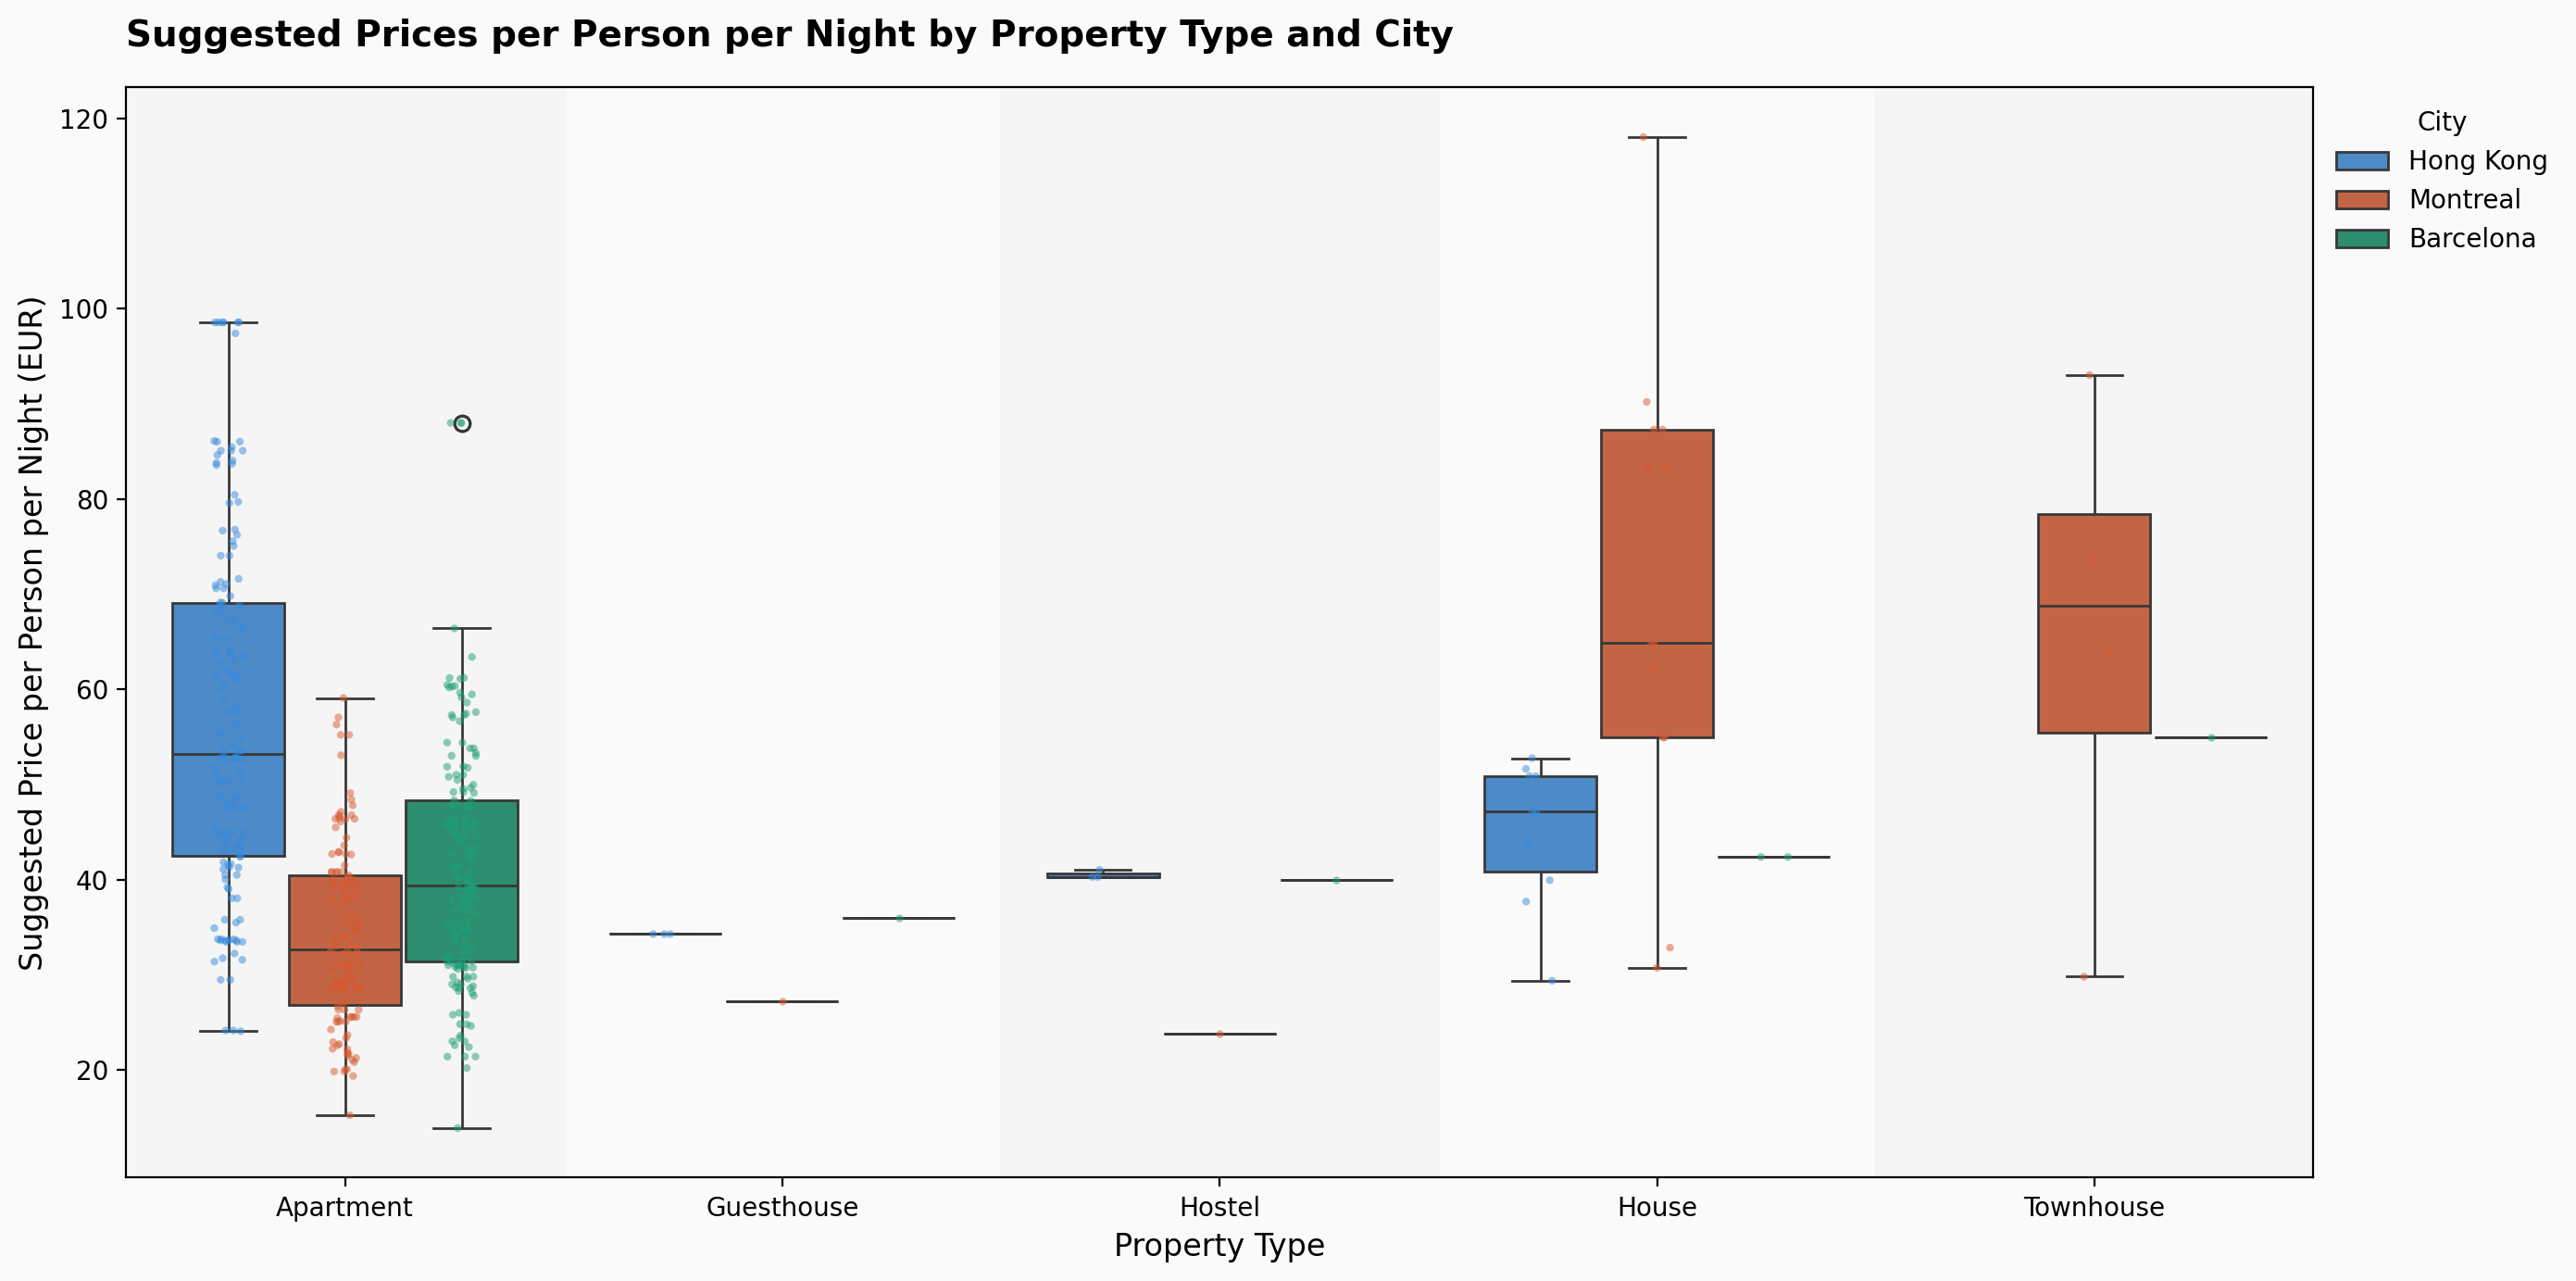

In [87]:
plot_suggested_ppn_boxplots(plot_df, show_points=True)

In [88]:
# Compute summary statistics of price per person per night grouped by property type and city,
# including count, minimum, quartiles (Q1, median, Q3), and maximum.
# Additionally, calculate whiskers based on the IQR (1.5 × IQR rule) to align with boxplot definitions.
# Convert grouped indices to columns and sort the results for readability.

summary = (
    plot_df.groupby(["property_type", "city"])["price_per_person_per_night_eur"]
    .agg(
        count="count",
        min="min",
        q1=lambda x: x.quantile(0.25),
        median="median",
        q3=lambda x: x.quantile(0.75),
        max="max",
    )
    .reset_index()
    .sort_values(["property_type", "city"])
)

# Interquartile range
summary["iqr"] = summary["q3"] - summary["q1"]

# Whiskers (computed via IQR, but without keeping bounds)
summary["lower_whisker"] = summary["q1"] - 1.5 * summary["iqr"]
summary["upper_whisker"] = summary["q3"] + 1.5 * summary["iqr"]

# Clip whiskers to actual data range
summary["lower_whisker"] = summary[["min", "lower_whisker"]].max(axis=1)
summary["upper_whisker"] = summary[["max", "upper_whisker"]].min(axis=1)

pd.DataFrame(summary)

,property_type,city,count,min,q1,median,q3,max,iqr,lower_whisker,upper_whisker
0,Apartment,Barcelona,171,13.8800,31.3500,39.4000,48.30000,88.000,16.95000,13.8800,73.725
1,Apartment,Hong Kong,148,24.0600,42.4485,53.1840,69.09900,98.568,26.65050,24.0600,98.568
2,Apartment,Montreal,130,15.2320,26.7750,32.6298,40.41495,59.092,13.63995,15.2320,59.092
3,Guesthouse,Barcelona,1,36.0000,36.0000,36.0000,36.00000,36.000,0.00000,36.0000,36.000
4,Guesthouse,Hong Kong,3,34.2720,34.2720,34.2720,34.27200,34.272,0.00000,34.2720,34.272
5,Guesthouse,Montreal,1,27.2000,27.2000,27.2000,27.20000,27.200,0.00000,27.2000,27.200
6,Hostel,Barcelona,1,40.0000,40.0000,40.0000,40.00000,40.000,0.00000,40.0000,40.000
7,Hostel,Hong Kong,3,40.2840,40.2840,40.2840,40.65600,41.028,0.37200,40.2840,41.028
8,Hostel,Montreal,1,23.8000,23.8000,23.8000,23.80000,23.800,0.00000,23.8000,23.800
9,House,Barcelona,2,42.3800,42.3800,42.3800,42.38000,42.380,0.00000,42.3800,42.380


### Result analysis and interpretation


The predicted price distributions broadly follow the structure of the observed prices across Barcelona, Hong Kong, and Montreal, with the most reliable insights coming from apartments due to their substantially larger number of observations. For apartments, both the median values and interquartile ranges for Barcelona and Montreal are closely aligned with the original distributions, indicating that the model preserves not only central tendencies but also variability. In particular, the predicted median price in Barcelona is approximately €39.4 compared to €37.7 in the observed data, with a comparable IQR of about €17.4 versus €23.4. Similarly, in Montreal, the predicted median (€33.1) is reasonably close to the observed value (€24.8), while the IQRs (€12.9 predicted vs €16.9 observed) indicate a similar level of dispersion, although slightly compressed.

In contrast, for Hong Kong, both the median and the spread of predicted prices are noticeably higher than in the observed data, suggesting a degree of upward bias in price estimation. This difference is likely driven by data limitations and the use of fallback mechanisms. In situations where sufficiently similar listings were not available, broader similarity criteria were applied, which may have introduced higher-priced neighbors into the estimation process. As a result, predicted values in some segments—particularly in Hong Kong—tend to be inflated.

For other property types, such as guesthouses, hostels, and townhouses, the analysis is constrained by very small sample sizes, making their distributions less reliable and more sensitive to individual observations. Nevertheless, despite this data sparsity, the model performs reasonably well across most cities, with predicted values generally falling within plausible ranges. Overall, the strongest performance is observed for apartments, while deviations in other categories are primarily explained by limited data availability and the necessity of fallback logic.


# B. Rating Analytics Expert


## B1. Score analysis


In [89]:
listings = db.listings
reviews = db.reviews

In [90]:
b1_pipeline = [
    {
        "$match": {
            "address.market": {"$in": ["Hong Kong", "Montreal", "Barcelona"]},
        }
    },
    {
        "$project": {
            "_id": 1,
            "city": "$address.market",
            "cleanliness": "$review_scores.review_scores_cleanliness",
            "accuracy": "$review_scores.review_scores_accuracy",
            "communication": "$review_scores.review_scores_communication",
            "location": "$review_scores.review_scores_location",
            "value": "$review_scores.review_scores_value",
        }
    },
]

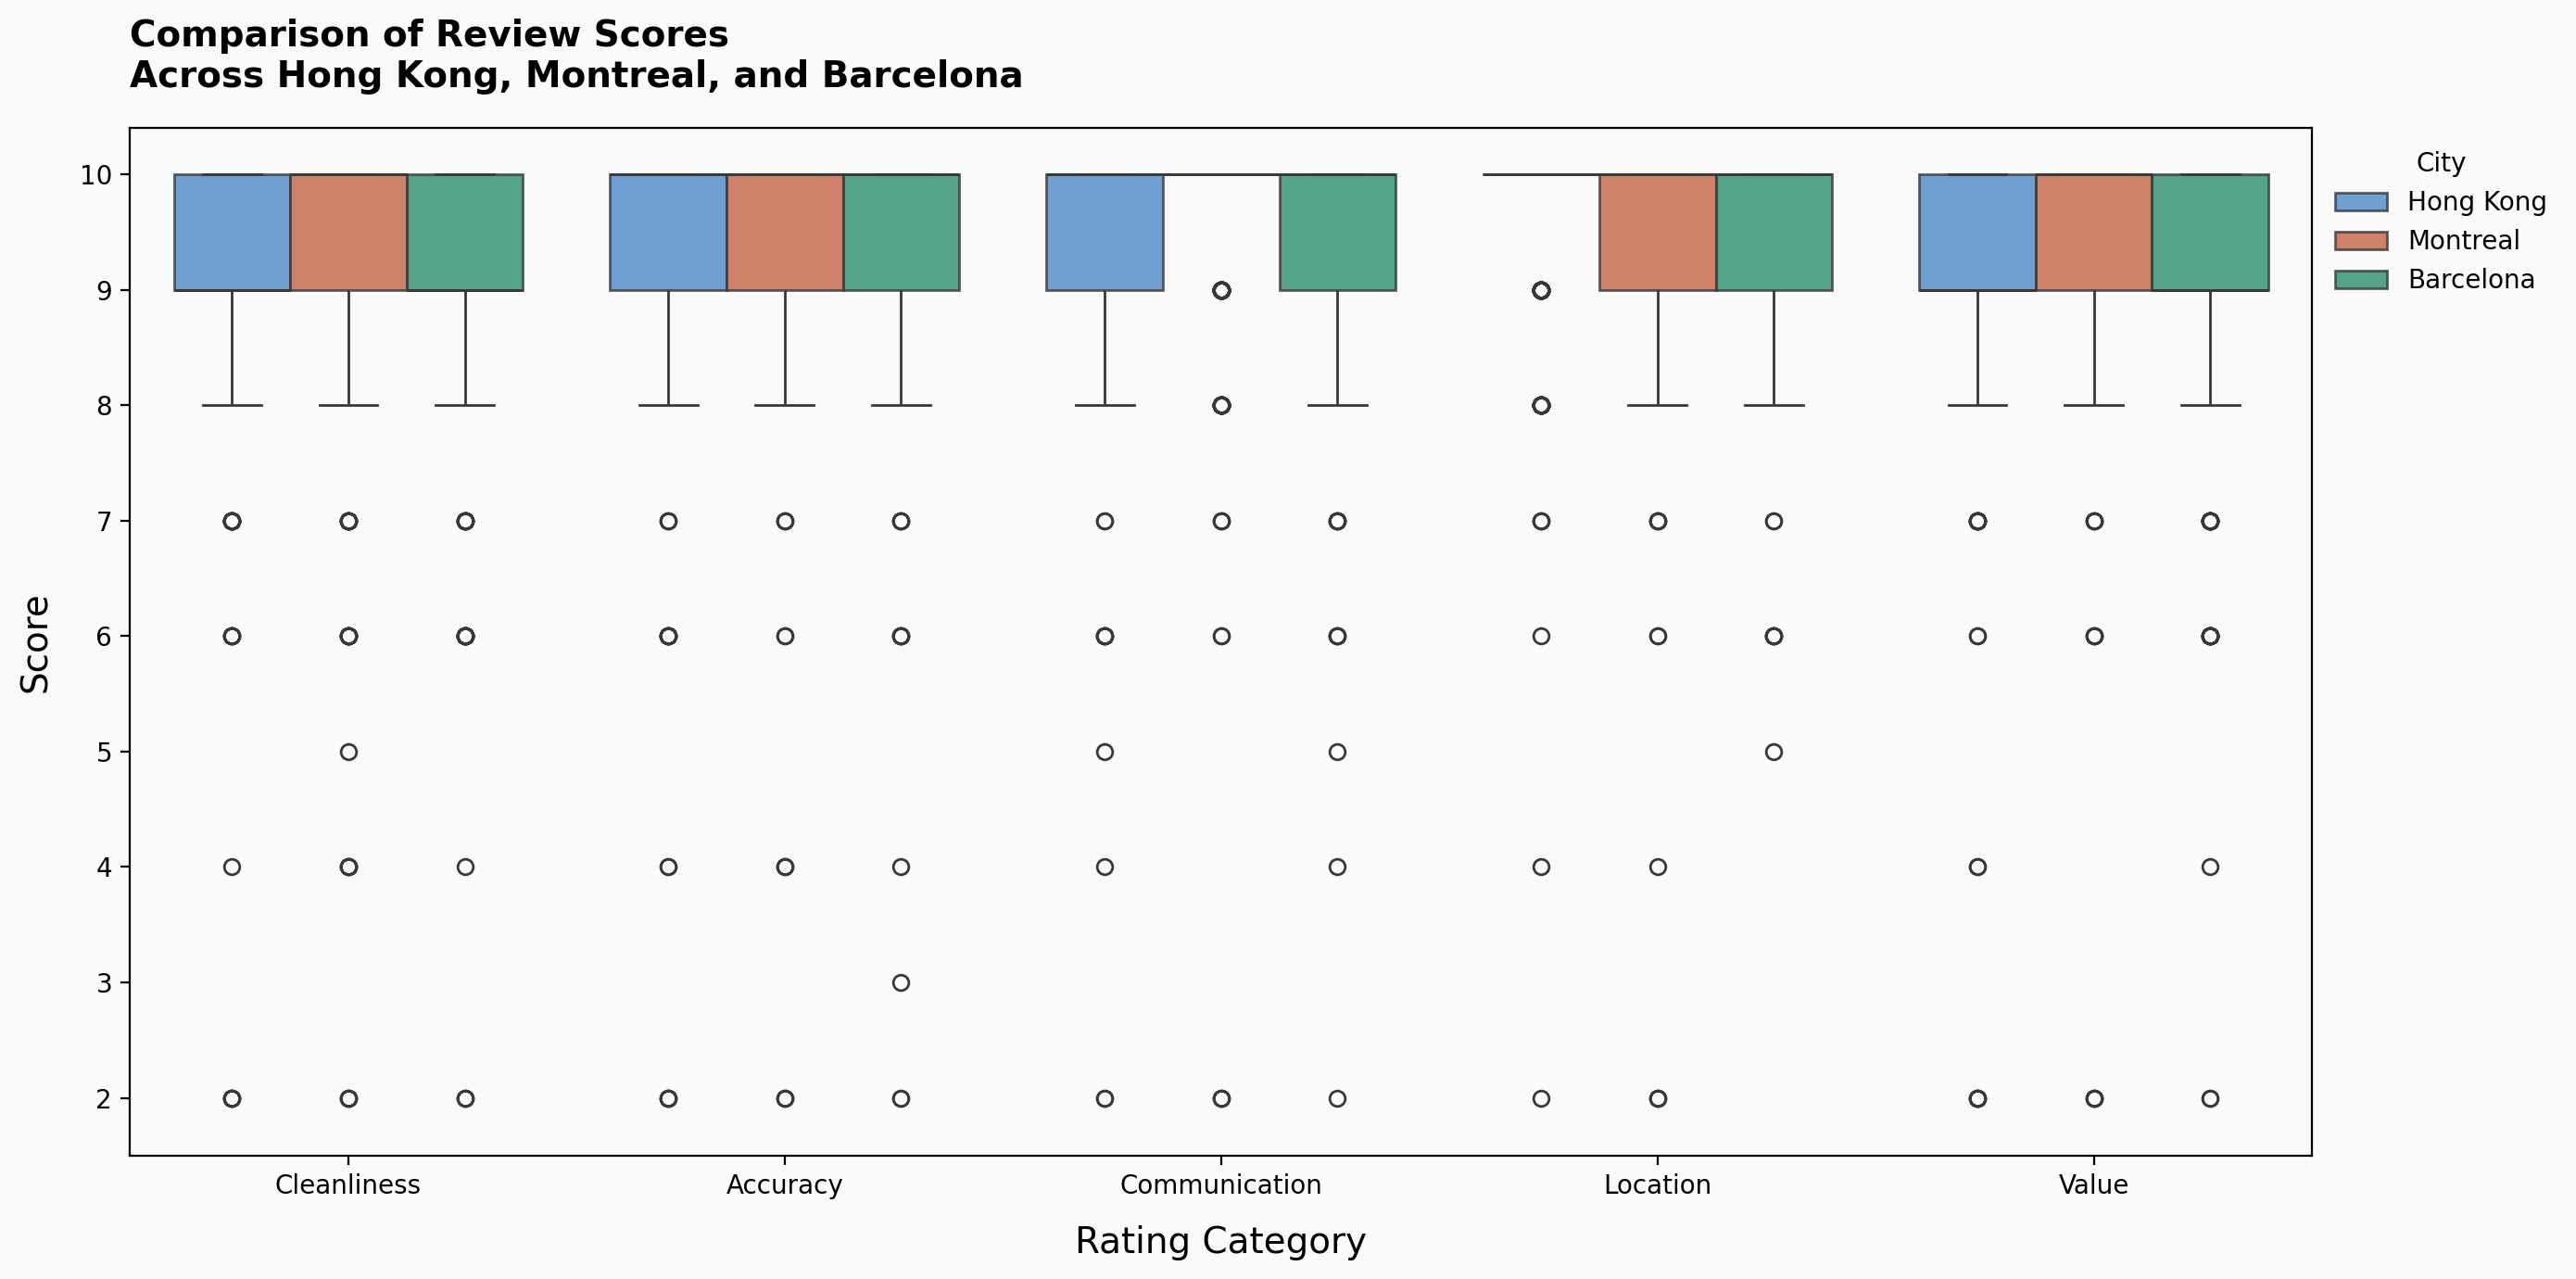

In [91]:
# ----------------------------------
# Review score comparison across
# Hong Kong, Montreal, and Barcelona
# (boxplot)
# ----------------------------------

# Run pipeline and convert to DataFrame
b1_df = pd.DataFrame(list(db.listings.aggregate(b1_pipeline))).set_index("_id")

# Reshape to long format for seaborn
df_long = b1_df.melt(
    id_vars="city",
    value_vars=["cleanliness", "accuracy", "communication", "location", "value"],
    var_name="rating_category",
    value_name="score",
)
df_long["rating_category"] = df_long["rating_category"].str.capitalize()


# --- Plot --- #
PALETTE = {"Hong Kong": "#378ADD", "Montreal": "#D85A30", "Barcelona": "#1D9E75"}
CITY_ORDER = ["Hong Kong", "Montreal", "Barcelona"]
CAT_ORDER = ["Cleanliness", "Accuracy", "Communication", "Location", "Value"]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.boxplot(
    data=df_long,
    x="rating_category",
    y="score",
    hue="city",
    order=CAT_ORDER,
    hue_order=CITY_ORDER,
    palette=PALETTE,
)

# Change transparency of boxes
for patch in ax.patches:
    patch.set_alpha(0.8)

ax.set_title(
    "Comparison of Review Scores\nAcross Hong Kong, Montreal, and Barcelona",
    fontsize=14,
    fontweight="bold",
    pad=16,
    loc="left",
)
ax.set_xlabel("Rating Category", fontsize=14, labelpad=10)
ax.set_ylabel("Score", fontsize=14, labelpad=10)
ax.set_ylim(bottom=df_long["score"].min() - 0.5)

ax.get_legend().remove()

ax.legend(
    title="City",
    title_fontsize=10,
    fontsize=10,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)

plt.tight_layout()
plt.show()

In [92]:
b1_df.isna().sum()

city               0
cleanliness      483
accuracy         485
communication    485
location         485
value            485
dtype: int64

In [93]:
b1_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cleanliness,1416.0,9.189266,1.200494,2.0,9.0,10.0,10.0,10.0
accuracy,1414.0,9.452617,1.032496,2.0,9.0,10.0,10.0,10.0
communication,1414.0,9.602546,0.891348,2.0,9.0,10.0,10.0,10.0
location,1414.0,9.576379,0.831634,2.0,9.0,10.0,10.0,10.0
value,1414.0,9.174682,1.066061,2.0,9.0,9.0,10.0,10.0


In [94]:
display("Descriptive statistics summary:", b1_df.describe().T)

'Descriptive statistics summary:'

,count,mean,std,min,25%,50%,75%,max
cleanliness,1416.0,9.189266,1.200494,2.0,9.0,10.0,10.0,10.0
accuracy,1414.0,9.452617,1.032496,2.0,9.0,10.0,10.0,10.0
communication,1414.0,9.602546,0.891348,2.0,9.0,10.0,10.0,10.0
location,1414.0,9.576379,0.831634,2.0,9.0,10.0,10.0,10.0
value,1414.0,9.174682,1.066061,2.0,9.0,9.0,10.0,10.0


**Side Quest**


In [95]:
print("Unique number pre rating")
print(
    df.dropna().select_dtypes(exclude="object").apply(lambda col: sorted(col.unique()))
)

Unique number pre rating
price                          [9.0, 10.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0...
accommodates                   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
bedrooms                       [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...
bathrooms                      [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, ...
beds                           [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...
guests_included                  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16]
review_scores_accuracy                      [2.0, 4.0, 6.0, 7.0, 8.0, 9.0, 10.0]
review_scores_cleanliness              [2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
review_scores_checkin             [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
review_scores_communication            [2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
review_scores_location                 [2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
review_scores_value                    [2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
rev

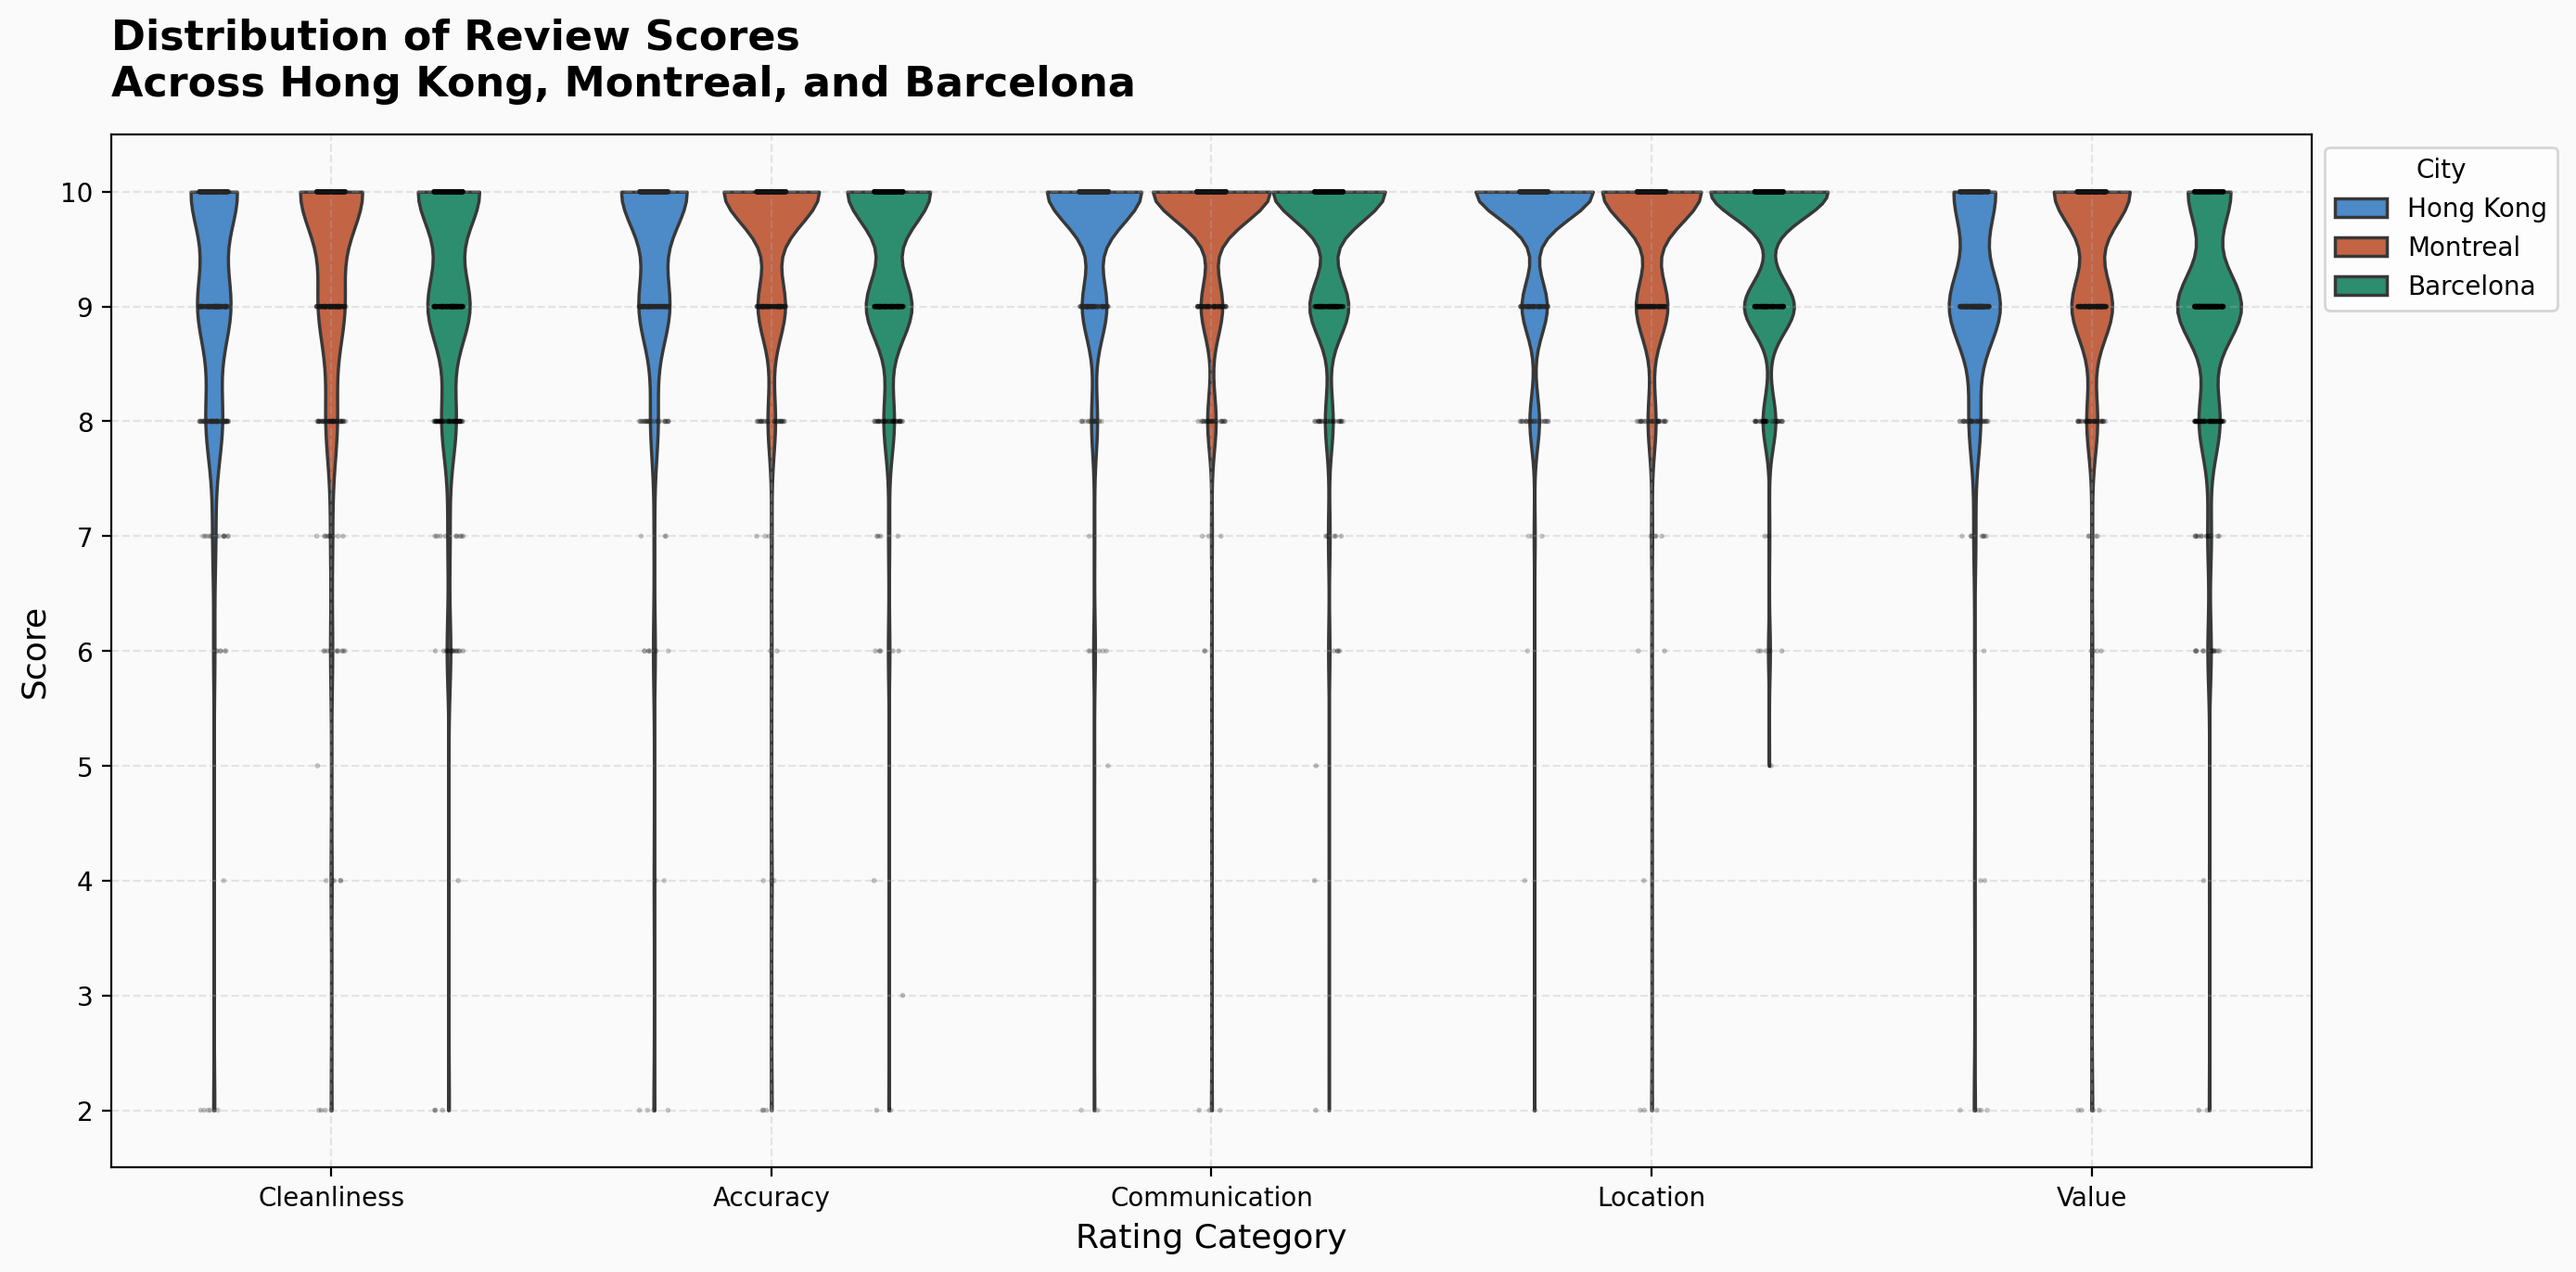

In [96]:
# ----------------------------------
# Review score distribution across
# Hong Kong, Montreal, and Barcelona
# (violin + strip plot)
# ----------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# --- Violin plot (distribution shape) --- #
sns.violinplot(
    data=df_long,
    x="rating_category",
    y="score",
    hue="city",
    order=CAT_ORDER,
    hue_order=CITY_ORDER,
    palette=PALETTE,
    inner=None,  # remove internal box
    cut=0,  # avoid extending beyond data range
    ax=ax,
)

# --- Strip plot (actual observations) --- #
sns.stripplot(
    data=df_long,
    x="rating_category",
    y="score",
    hue="city",
    order=CAT_ORDER,
    hue_order=CITY_ORDER,
    dodge=True,
    color="black",
    alpha=0.25,
    size=2,
    ax=ax,
    legend=False,
)

# --- Labels and title --- #
ax.set_title(
    "Distribution of Review Scores\nAcross Hong Kong, Montreal, and Barcelona",
    fontsize=16,
    fontweight="bold",
    pad=15,
    loc="left",
)
ax.legend(
    title="City",
    title_fontsize=10,
    fontsize=10,
    # frameon=False,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)

ax.set_xlabel("Rating Category", fontsize=13)
ax.set_ylabel("Score", fontsize=13)

# --- Improve ticks and grid --- #
ax.set_ylim(df_long["score"].min() - 0.5, 10.5)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## B2. Review quality and activity score


In [97]:
# ----------------------------------
# Filter for New York
# Count reviews per listing
# Keep only vallid listings (>10)
# ----------------------------------
review_count_pipeline = [
    {"$match": {"address.market": "New York"}},
    {
        "$lookup": {
            "from": "reviews",
            "let": {"current_listing_id": "$_id"},
            "pipeline": [
                {"$match": {"$expr": {"$eq": ["$listing_id", "$$current_listing_id"]}}},
                {"$count": "review_count"},
            ],
            "as": "review_stats",
        }
    },
    {
        "$addFields": {
            "review_count": {
                "$ifNull": [{"$arrayElemAt": ["$review_stats.review_count", 0]}, 0]
            }
        }
    },
    {"$match": {"review_count": {"$gte": 10}}},
    {
        "$project": {
            "_id": 1,
            "name": 1,
            "property_type": 1,
            "room_type": 1,
            "address.market": 1,
            "review_count": 1,
        }
    },
]

result = list(db.listings.aggregate(review_count_pipeline))
result

[{'_id': '17531493',
  'name': 'Cute Room in Upper West Side (FEMALES ONLY)',
  'property_type': 'Apartment',
  'room_type': 'Private room',
  'address': {'market': 'New York'},
  'review_count': 19},
 {'_id': '19063118',
  'name': 'JFK 10 & LGA 15 MINUTES AWAY A/C PRIVATE BEDROOM B',
  'property_type': 'House',
  'room_type': 'Private room',
  'address': {'market': 'New York'},
  'review_count': 106},
 {'_id': '1712895',
  'name': 'Nice Private Room: GREAT Location!',
  'property_type': 'Apartment',
  'room_type': 'Private room',
  'address': {'market': 'New York'},
  'review_count': 48},
 {'_id': '18944834',
  'name': 'Huge private bedroom in the heart of Manhattan',
  'property_type': 'Apartment',
  'room_type': 'Private room',
  'address': {'market': 'New York'},
  'review_count': 41},
 {'_id': '263190',
  'name': 'Room in East Village with Private Entrance',
  'property_type': 'Apartment',
  'room_type': 'Private room',
  'address': {'market': 'New York'},
  'review_count': 69},
 

In [98]:
reviews.find_one()

{'_id': '58663741',
 'date': datetime.datetime(2016, 1, 3, 5, 0),
 'listing_id': '10006546',
 'reviewer_id': '51483096',
 'reviewer_name': 'Cátia',
 'comments': 'A casa da Ana e do Gonçalo foram o local escolhido para a passagem de ano com um grupo de amigos. Fomos super bem recebidos com uma grande simpatia e predisposição a ajudar com qualquer coisa que fosse necessário.\r\nA casa era ainda melhor do que parecia nas fotos, totalmente equipada, com mantas, aquecedor e tudo o que pudessemos precisar.\r\nA localização não podia ser melhor! Não há melhor do que acordar de manhã e ao virar da esquina estar a ribeira do Porto.'}

In [99]:
# Keep only listings with fields needed for score computation
stage_filter_score_inputs = [
    {
        "$match": {
            "review_scores.review_scores_rating": {"$ne": None},
            "property_type": {"$ne": None},
            "last_review": {"$ne": None},
        }
    }
]

# Find most recent review
doc = db.reviews.find_one({}, sort=[("date", -1)])
global_latest_review = doc["date"]

# --- Compute Recency Base Variable --- #
stage_recency_base = [
    {
        "$addFields": {
            "days_since_latest": {
                "$dateDiff": {
                    "startDate": "$last_review",
                    "endDate": global_latest_review,
                    "unit": "day",
                }
            }
        }
    }
]

# --- Compute Reference Maxima --- #
stage_reference_values = [
    {
        "$setWindowFields": {
            "partitionBy": "$property_type",
            "output": {"max_review_count_in_type": {"$max": "$review_count"}},
        }
    },
    {
        "$setWindowFields": {
            "output": {"max_days_since_latest": {"$max": "$days_since_latest"}}
        }
    },
]


# --- Compute Activity Score Components --- #
stage_score_components = [
    {
        "$addFields": {
            # Average overall rating
            "avg_rating": {"$toDouble": "$review_scores.review_scores_rating"},
            # Normalized review count
            "normalized_review_count": {
                "$cond": [
                    {"$gt": ["$max_review_count_in_type", 0]},
                    {"$divide": ["$review_count", "$max_review_count_in_type"]},
                    0,
                ]
            },
            # Recency score
            "recency_score": {
                "$cond": [
                    {"$gt": ["$max_days_since_latest", 0]},
                    {
                        "$subtract": [
                            1,
                            {
                                "$divide": [
                                    "$days_since_latest",
                                    "$max_days_since_latest",
                                ]
                            },
                        ]
                    },
                    1,
                ]
            },
        }
    }
]


# --- Compute Final Score --- #
stage_final_score = [
    {
        "$addFields": {
            "score": {
                "$add": [
                    {"$multiply": ["$avg_rating", 0.5]},
                    {"$multiply": ["$normalized_review_count", 0.3]},
                    {"$multiply": ["$recency_score", 0.2]},
                ]
            }
        }
    }
]


In [100]:
# --- Define projection and apply full pipeline --- #
stage_project_output = [
    {
        "$project": {
            "_id": 1,
            "name": 1,
            "property_type": 1,
            "room_type": 1,
            "review_count": 1,
            "avg_rating": 1,
            "normalized_review_count": 1,
            "recency_score": 1,
            "score": 1,
            "last_review": 1,
        }
    }
]

b2_pipeline = (
    review_count_pipeline[:-1]
    + stage_filter_score_inputs
    + stage_recency_base
    + stage_reference_values
    + stage_score_components
    + stage_final_score
    + stage_project_output
)
pprint(b2_pipeline)

[{'$match': {'address.market': 'New York'}},
 {'$lookup': {'as': 'review_stats',
              'from': 'reviews',
              'let': {'current_listing_id': '$_id'},
              'pipeline': [{'$match': {'$expr': {'$eq': ['$listing_id',
                                                         '$$current_listing_id']}}},
                           {'$count': 'review_count'}]}},
 {'$addFields': {'review_count': {'$ifNull': [{'$arrayElemAt': ['$review_stats.review_count',
                                                                0]},
                                              0]}}},
 {'$match': {'review_count': {'$gte': 10}}},
 {'$match': {'last_review': {'$ne': None},
             'property_type': {'$ne': None},
             'review_scores.review_scores_rating': {'$ne': None}}},
 {'$addFields': {'days_since_latest': {'$dateDiff': {'endDate': datetime.datetime(2019, 3, 11, 4, 0),
                                                     'startDate': '$last_review',
                 

In [101]:
result = list(db.listings.aggregate(b2_pipeline))
for doc in result[:5]:
    pprint(doc)
    print("*" * 100)

{'_id': '13846473',
 'avg_rating': 89.0,
 'last_review': datetime.datetime(2018, 12, 8, 5, 0),
 'name': 'Nice Small Studio Near Cntrl Park(Shared Bathroom)',
 'normalized_review_count': 1.0,
 'property_type': 'Aparthotel',
 'recency_score': 0.953195772521389,
 'review_count': 49,
 'room_type': 'Private room',
 'score': 44.99063915450427}
****************************************************************************************************
{'_id': '823520',
 'avg_rating': 99.0,
 'last_review': datetime.datetime(2019, 2, 28, 5, 0),
 'name': 'ON HIGHLINE! Private room & bath',
 'normalized_review_count': 0.5642857142857143,
 'property_type': 'Apartment',
 'recency_score': 0.9944640161046804,
 'review_count': 237,
 'room_type': 'Private room',
 'score': 49.86817851750665}
****************************************************************************************************
{'_id': '55737',
 'avg_rating': 96.0,
 'last_review': datetime.datetime(2019, 2, 19, 5, 0),
 'name': 'Sleek & Comfortable 

**Comparison Table and BoxPlot**


In [102]:
# --- Transform the output into a readable comparison table showing the score per property type --- #
stage_property_type_comparison = [
    {
        "$group": {
            "_id": "$property_type",
            "n_listings": {"$sum": 1},
            "score": {"$avg": "$score"},
        }
    },
    {"$sort": {"n_listings": -1}},
    {"$project": {"_id": 0, "property_type": "$_id", "n_listings": 1, "score": 1}},
]
comparison_pipeline = (
    review_count_pipeline[:-1]
    + stage_filter_score_inputs
    + stage_recency_base
    + stage_reference_values
    + stage_score_components
    + stage_final_score
    + stage_property_type_comparison
)

comparison_table = list(db.listings.aggregate(comparison_pipeline))
df_scores = pd.DataFrame(comparison_table)
df_scores.set_index("n_listings", inplace=True)

df_scores.head(10)

,score,property_type
n_listings,,
295,47.331520,Apartment
34,47.533811,House
19,48.276379,Townhouse
15,47.371329,Condominium
14,47.828021,Loft
2,48.388627,Guesthouse
2,46.123462,Guest suite
1,42.913840,Villa
1,49.492652,Other


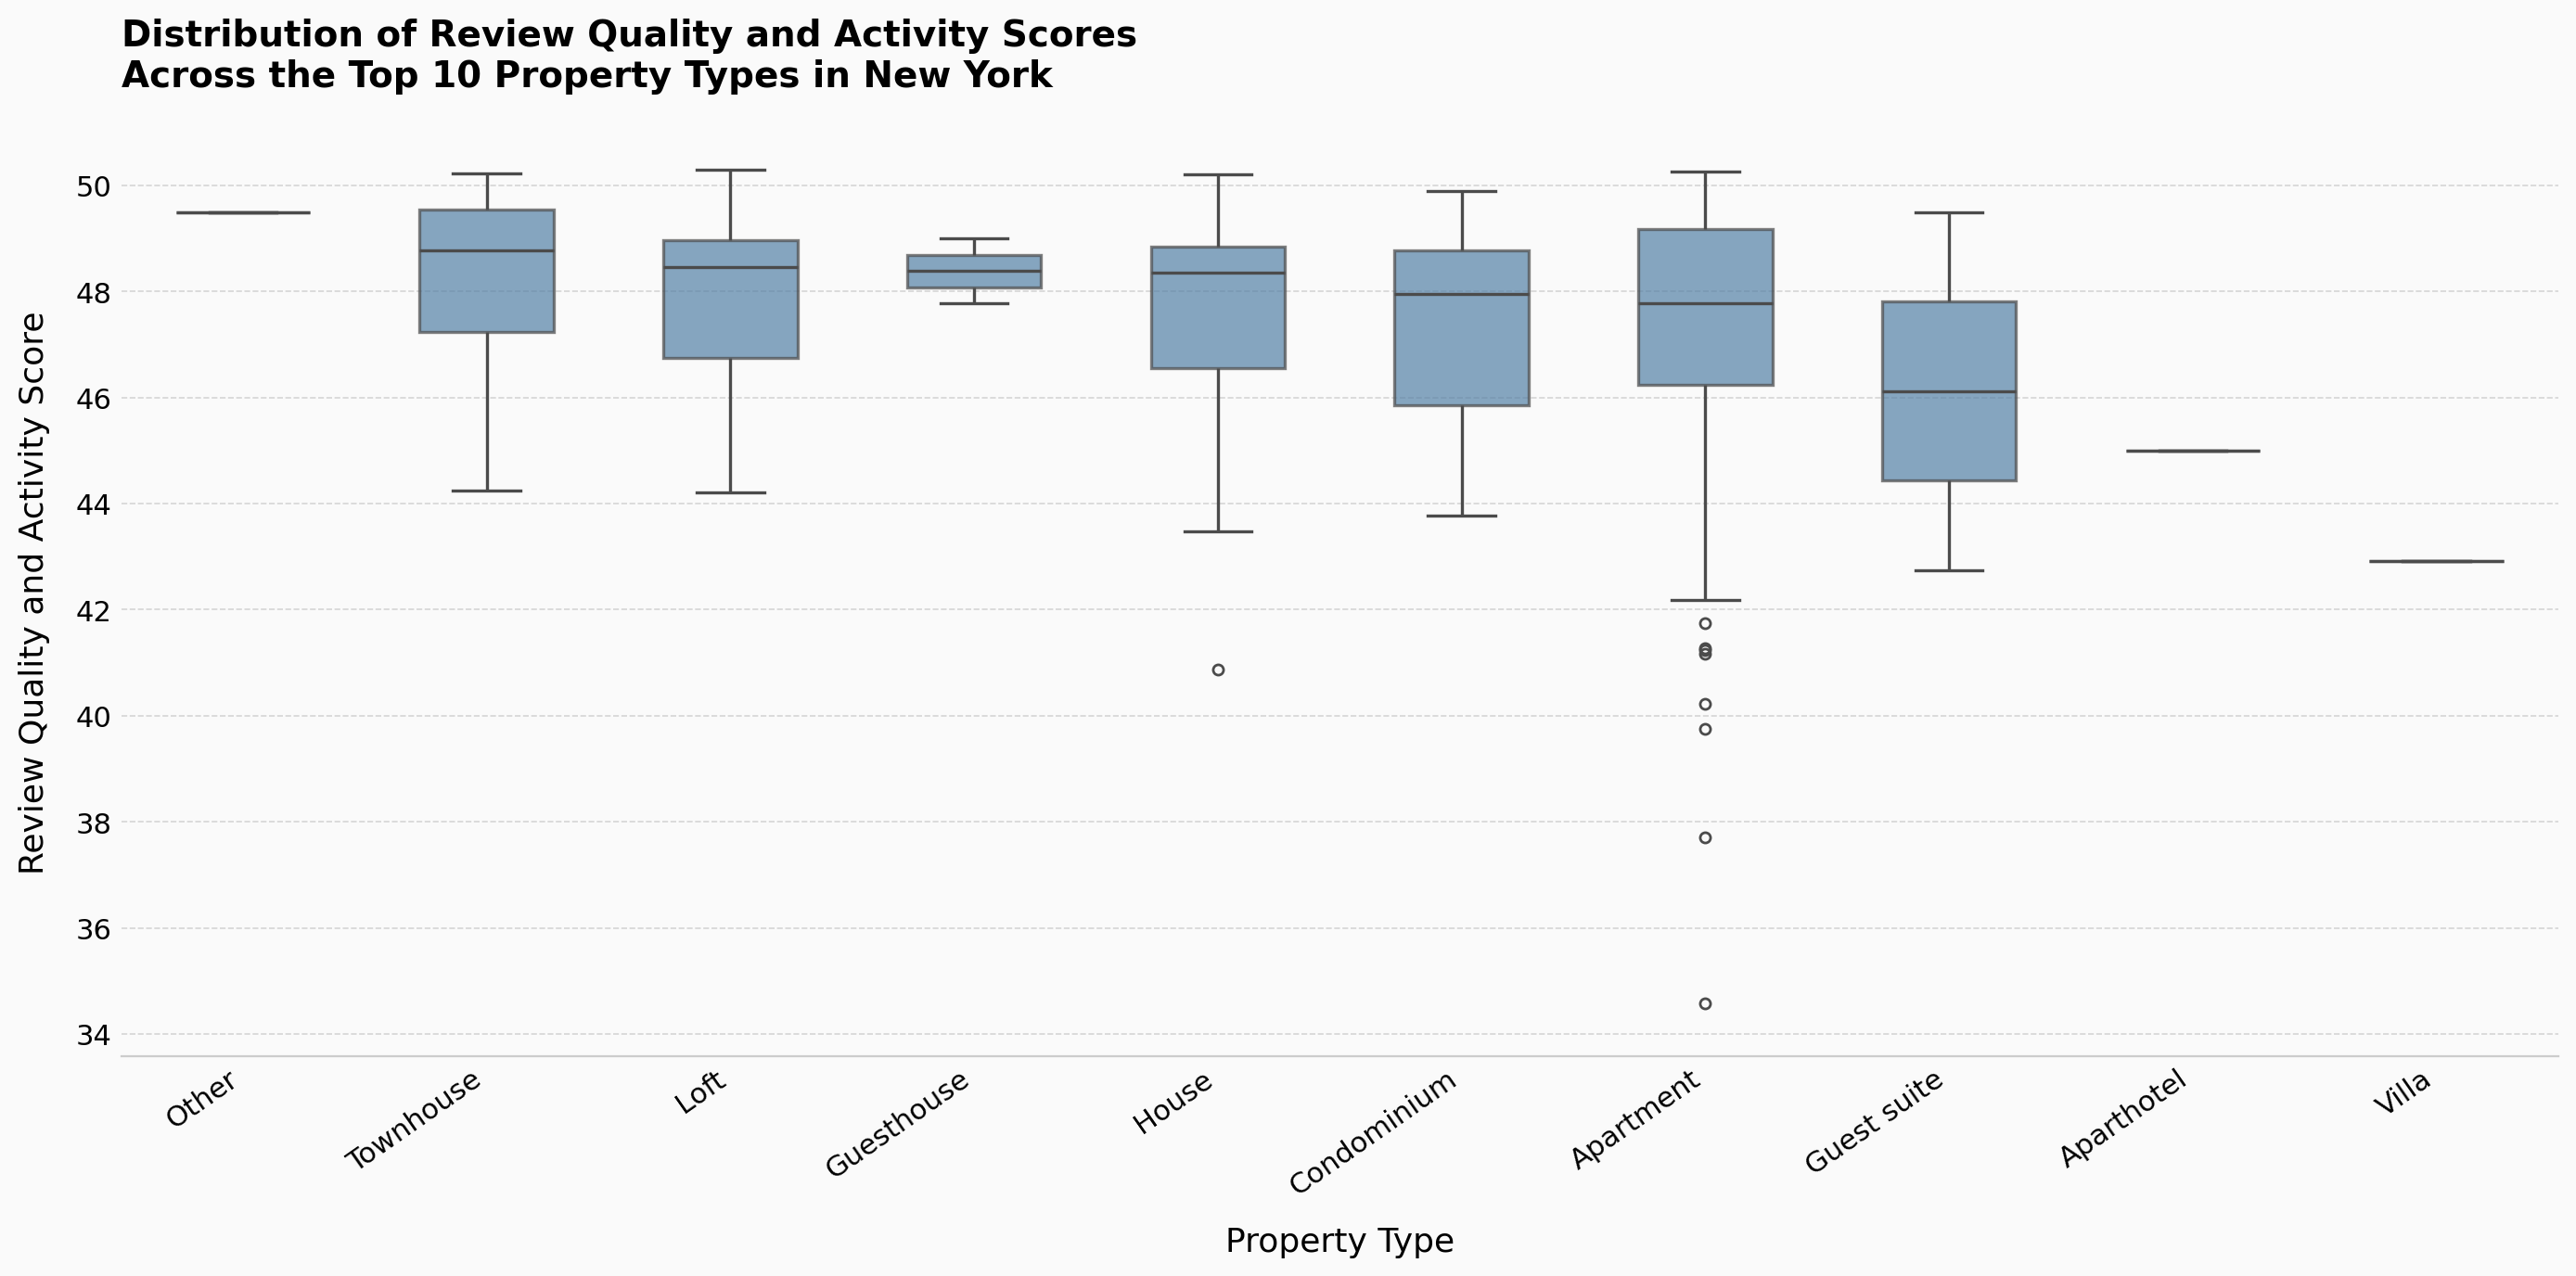

In [103]:
# ----------------------------------
# Box plot of the ten most frequent property types
# ----------------------------------
df_scores = pd.DataFrame(result)
top10_property_types = df_scores["property_type"].value_counts().head(10).index.tolist()
df_plot = df_scores[df_scores["property_type"].isin(top10_property_types)].copy()

# Sort x-axis by median score descending for easier comparison
order = (
    df_plot.groupby("property_type")["score"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.boxplot(
    data=df_plot,
    x="property_type",
    y="score",
    order=order,
    color="steelblue",
    width=0.55,
    linewidth=1.2,
    fliersize=4,
    linecolor="auto",
    fill=True,
    ax=ax,
)

# Slight transparency on boxes
for patch in ax.patches:
    patch.set_alpha(0.7)

# Configure grid
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, color="#CCCCCC", alpha=0.8)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")
ax.tick_params(axis="both", length=0, labelsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")


ax.set_title(
    "Distribution of Review Quality and Activity Scores\nAcross the Top 10 Property Types in New York",
    fontsize=14,
    fontweight="bold",
    pad=16,
    loc="left",
)
ax.set_xlabel("Property Type", fontsize=13, labelpad=10)
ax.set_ylabel("Review Quality and Activity Score", fontsize=13, labelpad=10)
ax.set_ylim(bottom=df_plot["score"].min() - 1)

plt.tight_layout()
plt.show()

**Explain**


In [104]:
# --- Calculate cardinality per indexing field candidates --- #
idx_fields = [
    "address.market",
    "property_type",
    "last_review",
]

cardinality = {}

for field in idx_fields:
    unique_values = db.listings.distinct(field)
    cardinality[field] = len(unique_values)
cardinality["listing_id"] = len(db.reviews.distinct("listing_id"))

sorted_cardinality = dict(
    sorted(cardinality.items(), key=lambda x: x[1], reverse=False)
)
print(sorted_cardinality)

{'address.market': 15, 'property_type': 36, 'last_review': 809, 'listing_id': 3923}


In [105]:
# --- Remove all existing indexes and clear query plan --- #
db.listings.drop_indexes()
db.reviews.drop_indexes()
db.command({"planCacheClear": "listings"})
pprint(db.listings.index_information())

# --- Run the aggregation pipeline with execution statistics and save the explain output to a JSON file --- #
explain_before = db.command(
    {
        "explain": {"aggregate": "listings", "pipeline": b2_pipeline, "cursor": {}},
        "verbosity": "executionStats",
    }
)
with open("./taskB2/taskB2_before.json", "w") as f:
    json.dump(explain_before, f, indent=4, default=str)

{'_id_': {'key': [('_id', 1)], 'v': 2}}


In [106]:
# --- Generate ordered compound index combinations (prefix-based) and evaluate query performance for each --- #
idx_fields = ["property_type", "last_review"]
for i in range(len(idx_fields) + 1):
    # Reset indexing state
    db.listings.drop_indexes()
    db.command({"planCacheClear": "listings"})
    db.command({"planCacheClear": "reviews"})

    # Build compound index
    current_index = [("address.market", 1)] + [(field, 1) for field in idx_fields[:i]]
    db.listings.create_index(current_index)

    # Run explain with execution statistics
    explain_output = db.command(
        {
            "explain": {"aggregate": "listings", "pipeline": b2_pipeline, "cursor": {}},
            "verbosity": "executionStats",
        }
    )

    # Create a readable filename
    index_name = "_".join(["market"] + idx_fields[:i]) if i > 0 else "market"
    output_path = f"./taskB2/taskB2_idx_{index_name}.json"

    # Save explain output
    with open(output_path, "w") as f:
        json.dump(explain_output, f, indent=4, default=str)

In [107]:
# --- Remove indexes and clear cache --- #
db.listings.drop_indexes()
db.reviews.drop_indexes()
db.command({"planCacheClear": "listings"})

# Create the foreign-collection index used by the $lookup
db.reviews.create_index([("listing_id", 1)], name="idx_reviews_listing_id")

# Run explain with execution statistics
explain_output = db.command(
    {
        "explain": {
            "aggregate": "listings",
            "pipeline": b2_pipeline,
            "cursor": {},
        },
        "verbosity": "executionStats",
    }
)

# Save explain output
with open("./taskB2/taskB2_idx_listing.json", "w") as f:
    json.dump(explain_output, f, indent=4, default=str)

In [108]:
# ----------------------------------
# Explain summary with `listing_id`
# ----------------------------------
# Define the folder and get all JSON files, sorted
task_folder = Path("taskB2")
json_files = sorted(task_folder.glob("*.json"))

# Load each JSON file into a list
explain_outputs = []
labels = []

for file in json_files:
    with open(file, "r") as f:
        explain_outputs.append(json.load(f))
    # Use the filename (without extension) as the label
    labels.append(file.stem)

# Unpack the list into the function
df_explain = utils.compare_explain_outputs(*explain_outputs, labels=labels)
df_explain["memory_usage"] = df_explain["memory_usage"].replace({0: "N/A", None: "N/A"})
df_explain.set_index("version")

,stage_type,execution_time_ms,documents_examined,keys_examined,memory_usage
version,,,,,
taskB2_before,COLLSCAN,25783,5555,0,515912
taskB2_idx_listing,COLLSCAN,65,5555,0,515912
taskB2_idx_market,IXSCAN,25688,607,607,515912
taskB2_idx_market_property_type,IXSCAN,25466,607,608,515912
taskB2_idx_market_property_type_last_review,IXSCAN,25666,538,544,515912


## B3. Long-term rental suggestions


In [109]:
# --- Create review recency DataFrame --- #
reviews_df = pd.DataFrame(
    list(db.reviews.find({}, {"_id": 1, "listing_id": 1, "date": 1}))
)

# Rename columns
reviews_df.rename(columns={"_id": "review_id", "date": "review_date"}, inplace=True)
# Date columns
reviews_df["review_date"] = pd.to_datetime(reviews_df["review_date"], format="%m-%Y")
reviews_df["year"] = reviews_df["review_date"].dt.year

reviews_df.set_index("review_id", inplace=True)

# --- Compute inactivity gaps within each listing-year --- #
reviews_df = reviews_df.sort_values(["listing_id", "review_date"])
reviews_df["gap_days"] = (
    reviews_df.groupby(["listing_id", "year"])["review_date"].diff().dt.days
)

reviews_df

,review_date,listing_id,year,gap_days
review_id,,,,
58663741,2016-01-03 05:00:00,10006546,2016,NaN
62413197,2016-02-14 05:00:00,10006546,2016,42.0
68310569,2016-04-04 04:00:00,10006546,2016,49.0
69693942,2016-04-12 04:00:00,10006546,2016,8.0
71451096,2016-04-25 04:00:00,10006546,2016,13.0
...,...,...,...,...
215802077,2017-12-01 05:00:00,9993190,2017,87.0
230037614,2018-01-26 05:00:00,9993190,2018,NaN
267808615,2018-05-22 04:00:00,9993190,2018,115.0


In [110]:
missing_gap_days = reviews_df["gap_days"].isna().sum()
missing_gap_days

np.int64(11183)

In [111]:
# Validate that each (listing_id, year) group produces exactly one NaN gap
reviews_df.groupby(["listing_id", "year"]).ngroups - missing_gap_days

np.int64(0)

In [112]:
# --- Verify that the first entry of each (listing_id, year) group has a missing gap --- #
mask = (
    reviews_df.sort_values(["listing_id", "year", "review_date"])
    .groupby(["listing_id", "year"])
    .nth(0)["gap_days"]
    .isna()
)

# Check if all first entries are NaN
print(f"All first entries per (listing_id, year) are NaN: {mask.all()}")

# Validate consistency between expected and observed missing values
print(
    f"Difference between number of first entries and total missing gap_days (should be 0): "
    f"{mask.sum() - missing_gap_days}"
)

All first entries per (listing_id, year) are NaN: True
Difference between number of first entries and total missing gap_days (should be 0): 0


In [113]:
# ----------------------------------
# Monthly review activity (pre listing-year)
# ----------------------------------
# --- Aggregate review counts per lising-year-month --- #
reviews_df["month"] = reviews_df["review_date"].dt.month
monthly_reviews = (
    reviews_df.reset_index()
    .groupby(["listing_id", "year", "month"])
    .size()
    .reset_index(name="review_count")
)
# --- Build complete listing-year-month grid --- #
all_months = pd.DataFrame({"month": range(1, 13)})
listing_years = monthly_reviews[["listing_id", "year"]].drop_duplicates()
listing_year_months = (
    listing_years.assign(key=1)
    .merge(all_months.assign(key=1), on="key")
    .drop(columns="key")
)

# --- Merge counts with ful grid and flag activity --- #
monthly_presence = listing_year_months.merge(
    monthly_reviews, on=["listing_id", "year", "month"], how="left"
).fillna({"review_count": 0})
monthly_presence["has_review"] = monthly_presence["review_count"] > 0
monthly_presence = monthly_presence.sort_values(["listing_id", "year", "month"])
monthly_presence

,listing_id,year,month,review_count,has_review
0,10006546,2016,1,1.0,True
1,10006546,2016,2,1.0,True
2,10006546,2016,3,0.0,False
3,10006546,2016,4,3.0,True
4,10006546,2016,5,2.0,True
...,...,...,...,...,...
134191,9993190,2018,8,1.0,True
134192,9993190,2018,9,0.0,False
134193,9993190,2018,10,0.0,False
134194,9993190,2018,11,0.0,False


In [114]:
# --- Extract empty month sequences per listing-year --- #
yearly_sequences = (
    monthly_presence.groupby(["listing_id", "year"])
    .apply(utils.detect_empty_sequences)  # Filter consecutive months (length > 2)
    .reset_index(name="empty_sequences")
)
display("Vacant months per listing per year", yearly_sequences.set_index("listing_id"))

'Vacant months per listing per year'

,year,empty_sequences
listing_id,,
10006546,2016,[]
10006546,2017,[]
10006546,2018,[]
10006546,2019,"[[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]"
1001265,2013,"[[1, 2, 3, 4], [7, 8]]"
...,...,...
9990304,2017,"[[3, 4, 5, 6, 7], [9, 10, 11, 12]]"
9990304,2018,"[[2, 3, 4, 5, 6], [9, 10, 11, 12]]"
9993190,2016,"[[1, 2, 3], [5, 6], [11, 12]]"


In [115]:
# ----------------------------------
# Detect recurring vacancy periods
# ----------------------------------
# Flatten sequences into individual months
exploded = yearly_sequences.explode("empty_sequences").dropna()
exploded = exploded.explode("empty_sequences")
exploded.rename(columns={"empty_sequences": "month"}, inplace=True)

# Count how many years each month appears as vacant
month_counts = (
    exploded.groupby(["listing_id", "month"])["year"]
    .nunique()
    .reset_index(name="year_count")
)

# Select recurring vacancy months (present in ≥ 2 years)
rental_suggestions = (
    month_counts[month_counts["year_count"] >= 2]
    .groupby("listing_id")["month"]
    .apply(list)
    .reset_index(name="rental_suggestion")
    .set_index("listing_id")
)
rental_suggestions

,rental_suggestion
listing_id,
1001265,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1003530,"[1, 2, 3, 4, 5, 6, 7, 9, 11, 12]"
10038496,"[5, 6]"
10057826,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
10059872,"[4, 5, 6, 7, 8, 9, 10, 11]"
...,...
9907103,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
9917859,"[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]"
9981541,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"


In [116]:
# --- Create recurring vacancy per DataFrame --- #
# Listings dataframe
listings_df = pd.DataFrame(list(db.listings.find({}, {"_id": 1, "address": 1})))
listings_df.rename(columns={"_id": "listing_id"}, inplace=True)
listings_df["city"] = listings_df["address"].str["market"]  # Flatten embedded property
listings_df.drop(columns="address", inplace=True)

# Merge dataframes
merged = rental_suggestions.merge(listings_df, on="listing_id")
merged.set_index("listing_id", inplace=True)
merged

,rental_suggestion,city
listing_id,,
1001265,"[3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",Oahu
1003530,"[1, 2, 3, 4, 5, 6, 7, 9, 11, 12]",New York
10038496,"[5, 6]",Rio De Janeiro
10057826,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",New York
10059872,"[4, 5, 6, 7, 8, 9, 10, 11]",Hong Kong
...,...,...
9907103,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",Montreal
9917859,"[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]",Porto
9981541,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",Hong Kong


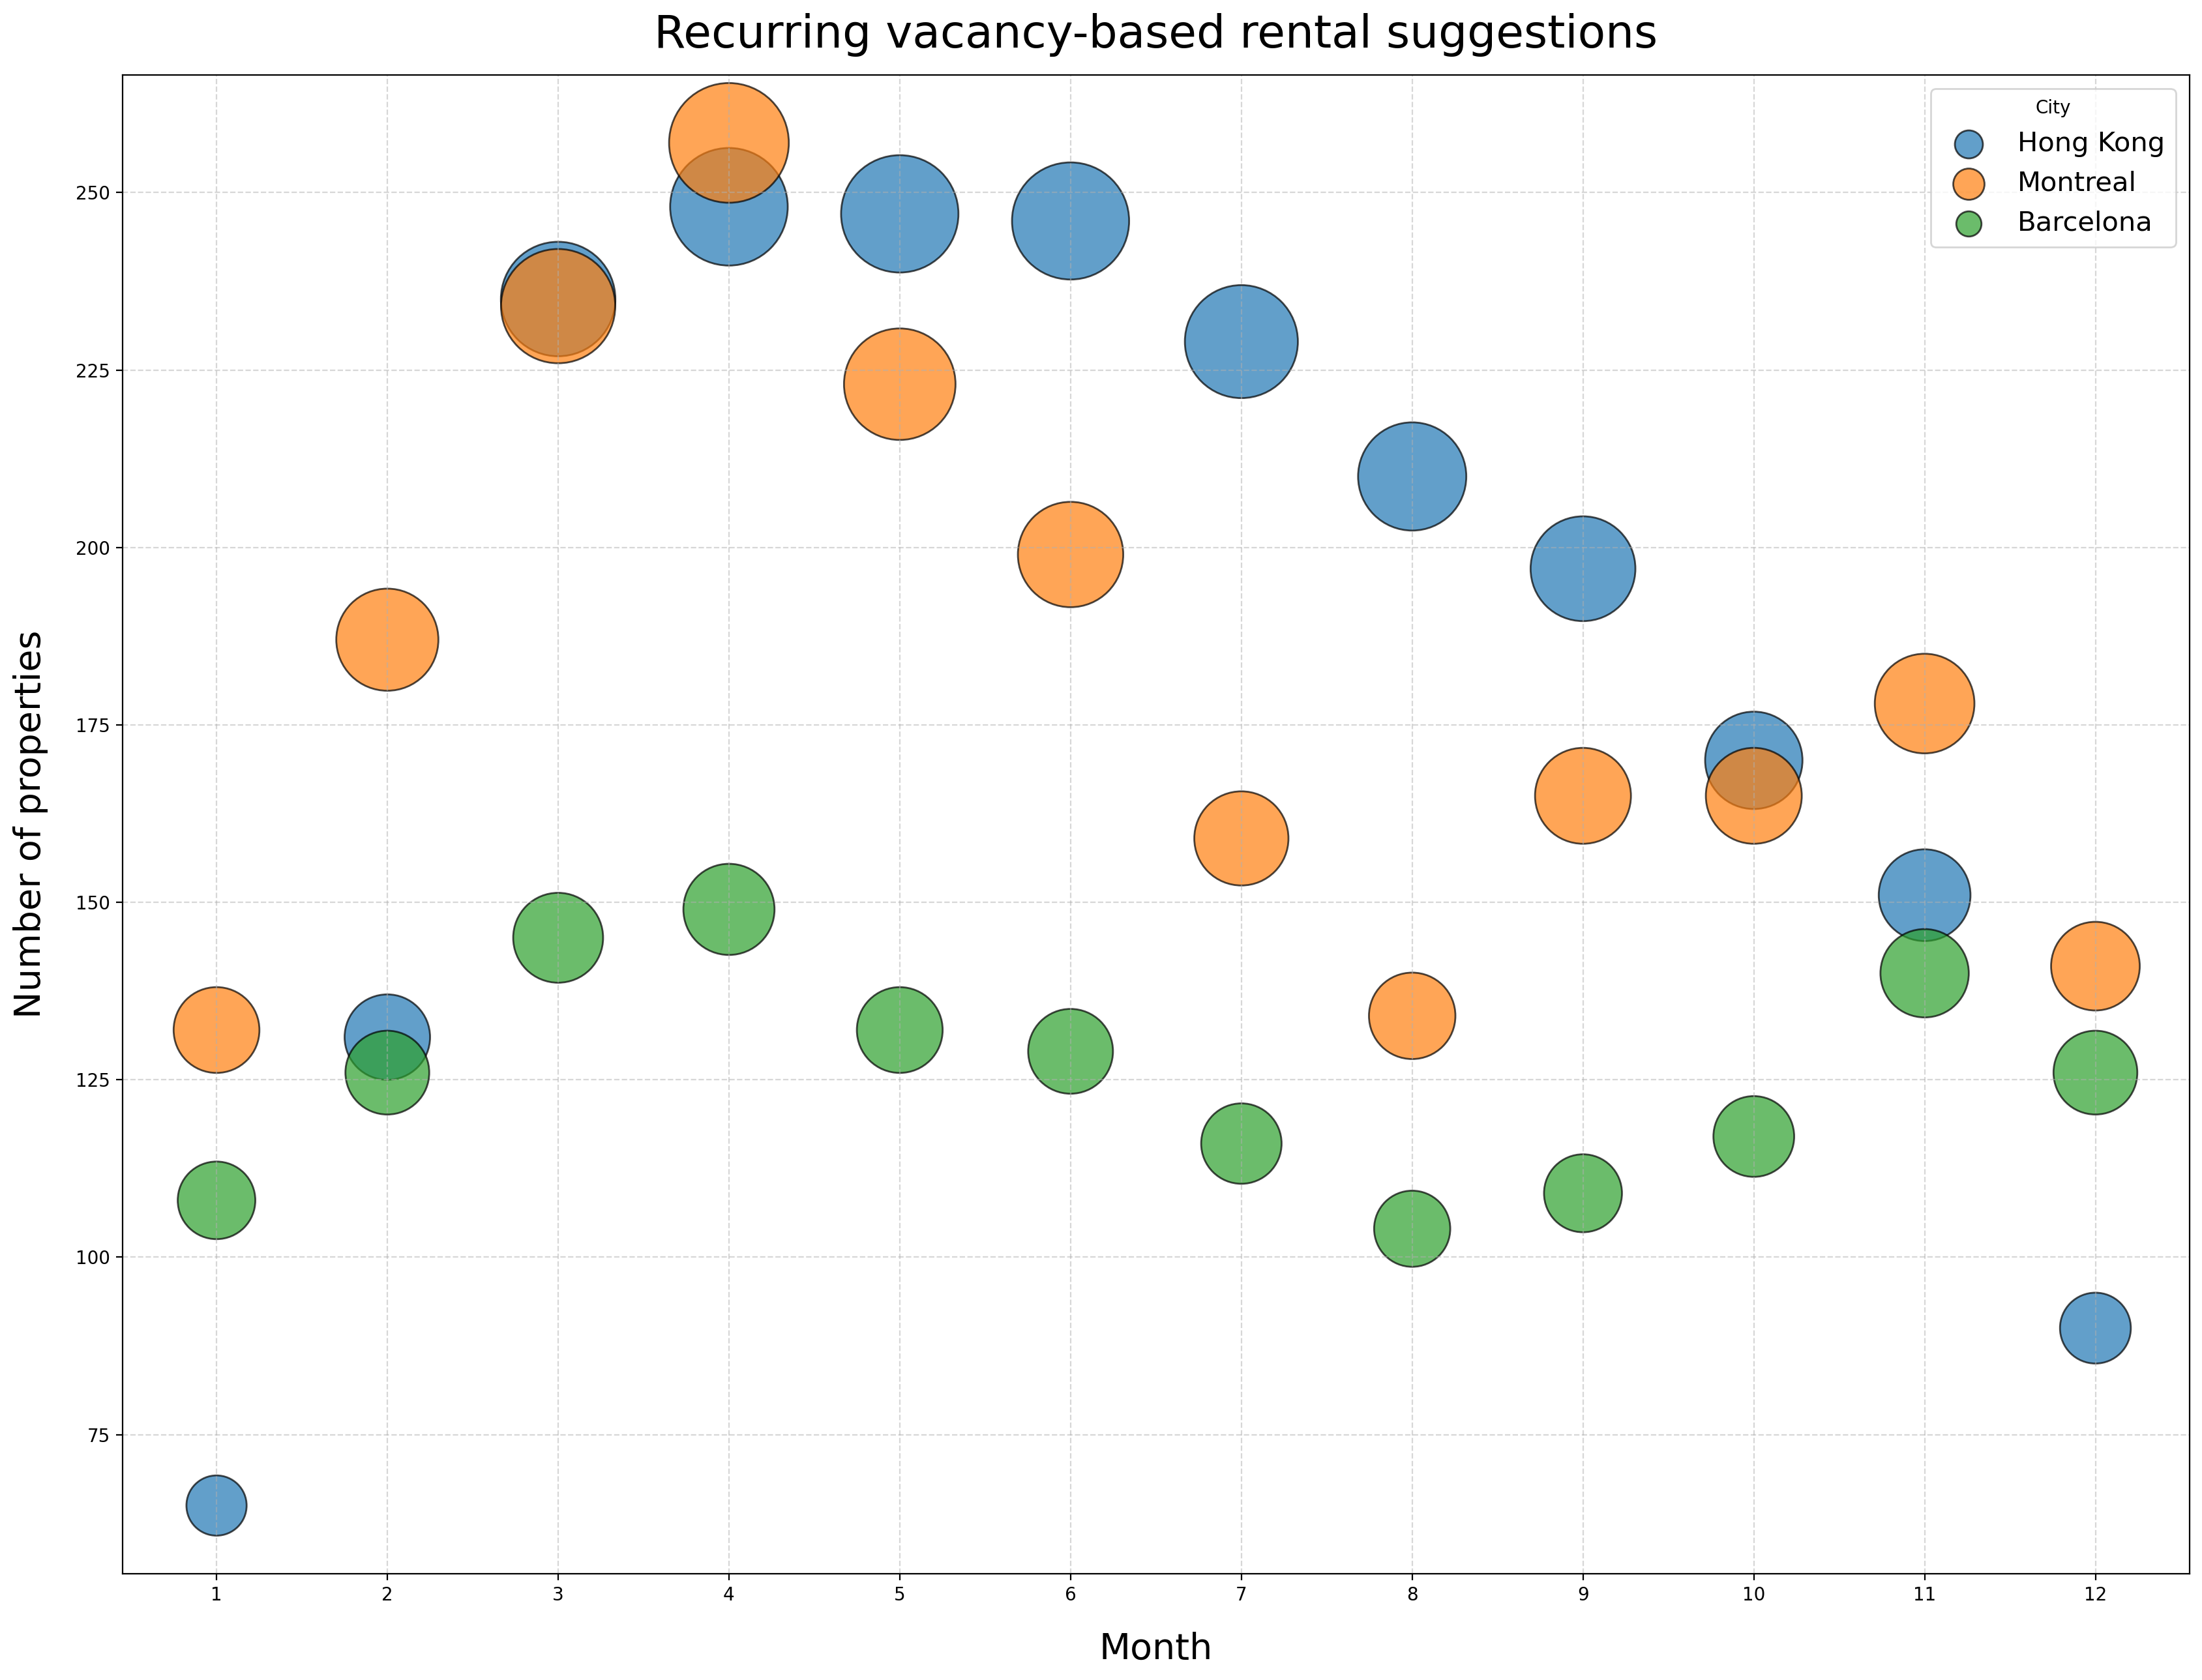

In [117]:
# ----------------------------------
# Scatter plot of rental suggestions
# (Hong Kong, Montreal, Barcelona)
# ----------------------------------
# Filter DF
cities = ["Hong Kong", "Montreal", "Barcelona"]
merged = merged[merged["city"].isin(cities)]

# Convert into one row per listings
exploded_suggestions = merged.explode("rental_suggestion")
exploded_suggestions.rename(columns={"rental_suggestion": "month"}, inplace=True)
plot_df = (
    exploded_suggestions.groupby(["city", "month"])
    .size()
    .reset_index(name="property_count")
)

# --- Make scatterplot --- #
plt.figure(figsize=(17, 13))

colors = {
    "Hong Kong": "tab:blue",
    "Montreal": "tab:orange",
    "Barcelona": "tab:green",
}

for city in cities:
    subset = plot_df[plot_df["city"] == city]

    plt.scatter(
        subset["month"],
        subset["property_count"],
        s=subset["property_count"] * 17,
        c=colors[city],
        label=city,
        alpha=0.7,
        edgecolors="black",
    )

plt.xlabel("Month", fontsize=20, labelpad=15)
plt.ylabel("Number of properties", fontsize=20, labelpad=15)
plt.title("Recurring vacancy-based rental suggestions", fontsize=25, pad=15)

plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="City", markerscale=0.3, fontsize=15)

plt.tight_layout()
plt.show()

# C. Comfort Analytics Expert


## 1. Setup and Reuse Checks

Expected collections from Part B:

- `hosts`
- `listings`
- `reviews`


In [118]:
required_collections = ["hosts", "listings", "reviews"]
existing_collections = set(db.list_collection_names())
missing_collections = [
    name for name in required_collections if name not in existing_collections
]

print("Available collections:", sorted(existing_collections))

if missing_collections:
    print(f"Missing normalized collections: {missing_collections}")
    print(
        "Run the normalization/preprocessing steps from PartB_AP.ipynb before continuing."
    )
else:
    print("All normalized collections required for Part C are available.")

hosts = db.hosts
listings = db.listings
reviews = db.reviews


Available collections: ['hosts', 'listings', 'listingsAndReviews_HW2', 'listingsAndReviews_HW2_new', 'reviews']
All normalized collections required for Part C are available.


## 2. Shared Preprocessing Reused from Part B

### Assumptions reused across Part C

- Stay duration = `7` nights.
- Number of guests = `2`.
- Effective stay cost includes the lower of nightly price for seven nights versus `weekly_price` when present.
- `cleaning_fee` is included.
- `extra_people` is applied only when `TARGET_GUESTS > guests_included`.
- Missing `cleaning_fee` and `extra_people` are treated as `0`.
- Missing `guests_included` is treated as `1`.
- For C1, prices are converted to **EUR** for cleaner cross-city visual comparison, reusing the same conversion idea already applied in Part B.
- For C3, the weighted score is computed **within each city**, so city-level normalization is used instead of comparing raw local-currency prices directly.


In [119]:
TARGET_GUESTS = 2
TARGET_NIGHTS = 7

EUR_RATES = {
    "Hong Kong": 0.12,
    "Montreal": 0.68,
    "Barcelona": 1.0,
    "Sydney": 0.61,
    "New York": 0.92,
}


def to_double_or_zero(field_expr):
    return {"$ifNull": [{"$toDouble": field_expr}, 0.0]}


def to_double_or_none(field_expr):
    return {
        "$cond": [
            {"$in": [field_expr, [None, ""]]},
            None,
            {"$toDouble": field_expr},
        ]
    }


def build_common_numeric_stage():
    return [
        {
            "$addFields": {
                "price_num": to_double_or_none("$price"),
                "weekly_price_num": to_double_or_none("$weekly_price"),
                "cleaning_fee_num": to_double_or_zero("$cleaning_fee"),
                "extra_people_num": to_double_or_zero("$extra_people"),
                "guests_included_num": {"$ifNull": ["$guests_included", 1]},
                "review_value_num": to_double_or_none(
                    "$review_scores.review_scores_value"
                ),
                "review_rating_num": to_double_or_none(
                    "$review_scores.review_scores_rating"
                ),
                "review_count_num": {"$ifNull": ["$number_of_reviews", 0]},
            }
        }
    ]


def build_effective_price_stage(
    target_guests=TARGET_GUESTS, target_nights=TARGET_NIGHTS
):
    return [
        {
            "$addFields": {
                "extra_guest_count": {
                    "$max": [0, {"$subtract": [target_guests, "$guests_included_num"]}]
                }
            }
        },
        {
            "$addFields": {
                "extra_person_total": {
                    "$multiply": [
                        "$extra_guest_count",
                        "$extra_people_num",
                        target_nights,
                    ]
                },
                "daily_total_price": {
                    "$cond": [
                        {"$ne": ["$price_num", None]},
                        {
                            "$add": [
                                {"$multiply": ["$price_num", target_nights]},
                                "$cleaning_fee_num",
                            ]
                        },
                        None,
                    ]
                },
                "weekly_total_price": {
                    "$cond": [
                        {"$ne": ["$weekly_price_num", None]},
                        {"$add": ["$weekly_price_num", "$cleaning_fee_num"]},
                        None,
                    ]
                },
            }
        },
        {
            "$addFields": {
                "daily_total_price": {
                    "$cond": [
                        {"$ne": ["$daily_total_price", None]},
                        {"$add": ["$daily_total_price", "$extra_person_total"]},
                        None,
                    ]
                },
                "weekly_total_price": {
                    "$cond": [
                        {"$ne": ["$weekly_total_price", None]},
                        {"$add": ["$weekly_total_price", "$extra_person_total"]},
                        None,
                    ]
                },
            }
        },
        {
            "$addFields": {
                "effective_total_price": {
                    "$switch": {
                        "branches": [
                            {
                                "case": {
                                    "$and": [
                                        {"$ne": ["$weekly_total_price", None]},
                                        {"$eq": ["$daily_total_price", None]},
                                    ]
                                },
                                "then": "$weekly_total_price",
                            },
                            {
                                "case": {
                                    "$and": [
                                        {"$ne": ["$weekly_total_price", None]},
                                        {"$ne": ["$daily_total_price", None]},
                                        {
                                            "$lt": [
                                                "$weekly_total_price",
                                                "$daily_total_price",
                                            ]
                                        },
                                    ]
                                },
                                "then": "$weekly_total_price",
                            },
                            {
                                "case": {"$ne": ["$daily_total_price", None]},
                                "then": "$daily_total_price",
                            },
                        ],
                        "default": None,
                    }
                }
            }
        },
        {
            "$addFields": {
                "effective_price_pppn_local": {
                    "$cond": [
                        {"$gt": ["$effective_total_price", 0]},
                        {
                            "$divide": [
                                "$effective_total_price",
                                target_guests * target_nights,
                            ]
                        },
                        None,
                    ]
                }
            }
        },
    ]


def apply_eur_conversion(
    df, source_col="effective_price_pppn_local", target_col="effective_price_pppn_eur"
):
    df[target_col] = (df[source_col] * df["city"].map(EUR_RATES).fillna(1.0)).round(2)
    return df


def ensure_columns(df, columns):
    for column in columns:
        if column not in df.columns:
            df[column] = pd.Series(dtype="object")
    return df


def normalize_city_inverse_score(series):
    min_val = series.min()
    max_val = series.max()
    if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
        return pd.Series(0.5, index=series.index)
    return (max_val - series) / (max_val - min_val)


def compute_amenity_impact(
    df,
    metric_col,
    city_col="city",
    amenities_col="amenities",
    min_presence=5,
    max_prevalence=1.0,
):
    work_df = df[[city_col, metric_col, amenities_col, "_id"]].copy()
    work_df = work_df[work_df[metric_col].notna()].copy()
    work_df[amenities_col] = work_df[amenities_col].apply(
        lambda x: list(dict.fromkeys(x)) if isinstance(x, list) else []
    )

    exploded = work_df.explode(amenities_col).rename(columns={amenities_col: "amenity"})
    exploded = exploded[exploded["amenity"].notna()].copy()

    total_by_city = work_df.groupby(city_col)["_id"].nunique().rename("total_listings")
    amenity_counts = (
        exploded.groupby([city_col, "amenity"])["_id"]
        .nunique()
        .rename("listing_count")
        .reset_index()
    )
    amenity_counts = amenity_counts.merge(
        total_by_city.reset_index(), on=city_col, how="left"
    )
    amenity_counts["prevalence"] = (
        amenity_counts["listing_count"] / amenity_counts["total_listings"]
    )

    amenity_counts = amenity_counts[
        (amenity_counts["listing_count"] >= min_presence)
        & (amenity_counts["prevalence"] <= max_prevalence)
        & (amenity_counts["prevalence"] > 0)
    ].copy()

    results = []
    grouped = {city: city_df.copy() for city, city_df in work_df.groupby(city_col)}

    for row in amenity_counts.itertuples(index=False):
        city_df = grouped[row.__getattribute__(city_col)]
        has_mask = city_df[amenities_col].apply(lambda a: row.amenity in a)
        with_vals = city_df.loc[has_mask, metric_col]
        without_vals = city_df.loc[~has_mask, metric_col]
        if with_vals.empty or without_vals.empty:
            continue
        results.append(
            {
                city_col: row.__getattribute__(city_col),
                "amenity": row.amenity,
                "listing_count": row.listing_count,
                "total_listings": row.total_listings,
                "prevalence": row.prevalence,
                "median_with": with_vals.median(),
                "median_without": without_vals.median(),
                "mean_with": with_vals.mean(),
                "mean_without": without_vals.mean(),
                "median_delta": with_vals.median() - without_vals.median(),
                "mean_delta": with_vals.mean() - without_vals.mean(),
            }
        )

    return pd.DataFrame(results).sort_values(
        [city_col, "median_delta"], ascending=[True, False]
    )


def build_boxplot_df(
    df, selected_amenities_df, metric_col, city_col="city", amenities_col="amenities"
):
    rows = []
    for item in (
        selected_amenities_df[["city", "amenity"]]
        .drop_duplicates()
        .itertuples(index=False)
    ):
        city_df = df[df[city_col] == item.city].copy()
        city_df["has_amenity"] = city_df[amenities_col].apply(
            lambda a: item.amenity in a if isinstance(a, list) else False
        )
        city_df["amenity"] = item.amenity
        rows.append(city_df[[city_col, "amenity", "has_amenity", metric_col]])
    if not rows:
        return pd.DataFrame(columns=[city_col, "amenity", "has_amenity", metric_col])
    return pd.concat(rows, ignore_index=True)


def plot_city_amenity_boxplots(plot_df, value_col, title, y_label):
    palette = {True: "#2B7A78", False: "#D95D39"}
    city_order = sorted(plot_df["city"].unique())

    fig, axes = plt.subplots(1, len(city_order), figsize=(18, 6), sharey=True)
    if len(city_order) == 1:
        axes = [axes]

    for ax, city in zip(axes, city_order):
        city_df = plot_df[plot_df["city"] == city].copy()
        amenity_order = (
            city_df.groupby("amenity")[value_col]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )
        sns.boxplot(
            data=city_df,
            x="amenity",
            y=value_col,
            hue="has_amenity",
            order=amenity_order,
            palette=palette,
            showfliers=True,
            ax=ax,
        )
        ax.set_title(city, fontsize=12, fontweight="bold")
        ax.set_xlabel("Amenity")
        ax.set_ylabel(y_label)
        ax.tick_params(axis="x", rotation=25)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], ["Without", "With"], title="Amenity")

    fig.suptitle(title, fontsize=15, fontweight="bold", x=0.06, ha="left")
    plt.tight_layout()
    plt.show()


def plot_double_lollipop(
    df, left_col, right_col, label_col, left_label, right_label, title
):
    work_df = df.copy().reset_index(drop=True)
    y_pos = np.arange(len(work_df))

    fig, ax = plt.subplots(figsize=(14, max(8, len(work_df) * 0.35)))
    for i, row in work_df.iterrows():
        ax.plot(
            [row[left_col], row[right_col]],
            [i, i],
            color="#B8B8B8",
            linewidth=2,
            zorder=1,
        )

    ax.scatter(
        work_df[left_col], y_pos, color="#378ADD", s=70, label=left_label, zorder=2
    )
    ax.scatter(
        work_df[right_col], y_pos, color="#D85A30", s=70, label=right_label, zorder=3
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(work_df[label_col])
    ax.set_xlabel("Prevalence (%)")
    ax.set_title(title, fontsize=14, fontweight="bold", loc="left")
    ax.legend(frameon=False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


## C1. Amenity Premium Analysis

### Decisions

- The comparison is performed within each city, then visualized side by side.
- Amenities present in **every** property in a city are excluded because they do not create variation.
- The premium is measured as the difference between the **median** effective price per person per night for listings **with** the amenity versus **without** it.
- A small stability filter of at least `5` listings with the amenity is used so rare one-off amenities do not dominate the ranking.


In [120]:
C1_CITIES = ["Hong Kong", "Montreal", "Barcelona"]

c1_pipeline = [
    {
        "$match": {
            "address.market": {"$in": C1_CITIES},
            "amenities.0": {"$exists": True},
        }
    },
    *build_common_numeric_stage(),
    *build_effective_price_stage(),
    {
        "$project": {
            "_id": 1,
            "city": "$address.market",
            "property_type": 1,
            "amenities": 1,
            "effective_price_pppn_local": 1,
        }
    },
]

c1_df = pd.DataFrame(list(listings.aggregate(c1_pipeline)))
c1_df = ensure_columns(
    c1_df, ["_id", "city", "property_type", "amenities", "effective_price_pppn_local"]
)

if c1_df.empty:
    print(
        "C1 returned no listings. Check whether the normalized listings collection exists and contains the expected cities."
    )
    c1_impact_df = pd.DataFrame(
        columns=[
            "city",
            "amenity",
            "listing_count",
            "total_listings",
            "prevalence",
            "median_with",
            "median_without",
            "mean_with",
            "mean_without",
            "median_delta",
            "mean_delta",
        ]
    )
else:
    c1_df = c1_df[c1_df["effective_price_pppn_local"].notna()].copy()
    c1_df = c1_df[c1_df["effective_price_pppn_local"] > 0].copy()
    c1_df["amenities"] = c1_df["amenities"].apply(
        lambda x: x if isinstance(x, list) else []
    )
    c1_df = apply_eur_conversion(c1_df)

    c1_impact_df = compute_amenity_impact(
        c1_df,
        metric_col="effective_price_pppn_eur",
        min_presence=5,
        max_prevalence=0.999999,
    )

c1_top3_df = (
    c1_impact_df.sort_values(["city", "median_delta"], ascending=[True, False])
    .groupby("city")
    .head(3)
    .reset_index(drop=True)
)

c1_negative_df = (
    c1_impact_df.sort_values(["city", "median_delta"], ascending=[True, True])
    .groupby("city")
    .head(3)
    .reset_index(drop=True)
)

display(c1_top3_df.round(2))
display(c1_negative_df.round(2))


,city,amenity,listing_count,total_listings,prevalence,median_with,median_without,mean_with,mean_without,median_delta,mean_delta
0,Barcelona,Window guards,8,451,0.02,67.46,32.86,66.56,55.70,34.61,10.86
1,Barcelona,Full kitchen,8,451,0.02,67.25,32.71,61.58,55.79,34.54,5.79
2,Barcelona,Keypad,7,451,0.02,66.07,32.78,74.27,55.61,33.28,18.66
3,Hong Kong,Coffee maker,23,432,0.05,67.71,34.29,71.37,43.86,33.42,27.52
4,Hong Kong,Bathtub,9,432,0.02,61.96,34.71,76.45,44.66,27.25,31.79
5,Hong Kong,Buzzer/wireless intercom,39,432,0.09,54.78,33.86,63.55,43.51,20.92,20.03
6,Montreal,Doorman,7,488,0.01,60.37,26.91,65.54,35.69,33.46,29.86
7,Montreal,Hot tub,25,488,0.05,47.60,26.52,45.32,35.62,21.08,9.71
8,Montreal,Babysitter recommendations,8,488,0.02,47.36,26.94,61.22,35.70,20.42,25.52


,city,amenity,listing_count,total_listings,prevalence,median_with,median_without,mean_with,mean_without,median_delta,mean_delta
0,Barcelona,Lock on bedroom door,84,451,0.19,24.25,37.00,28.94,62.07,-12.75,-33.12
1,Barcelona,Essentials,423,451,0.94,32.86,45.54,52.28,110.51,-12.67,-58.22
2,Barcelona,Cleaning before checkout,11,451,0.02,22.07,33.29,29.46,56.56,-11.22,-27.10
3,Hong Kong,Lock on bedroom door,205,432,0.47,30.12,42.00,42.04,48.29,-11.88,-6.25
4,Hong Kong,translation missing: en.hosting_amenity_49,32,432,0.07,26.84,35.96,28.83,46.64,-9.11,-17.81
5,Hong Kong,Fire extinguisher,165,432,0.38,32.04,38.39,44.18,46.03,-6.35,-1.85
6,Montreal,Handheld shower head,6,488,0.01,11.00,27.44,27.31,36.22,-16.44,-8.92
7,Montreal,Wide clearance to shower,6,488,0.01,17.66,27.49,17.66,36.34,-9.83,-18.68
8,Montreal,toilet,6,488,0.01,17.66,27.49,17.66,36.34,-9.83,-18.68


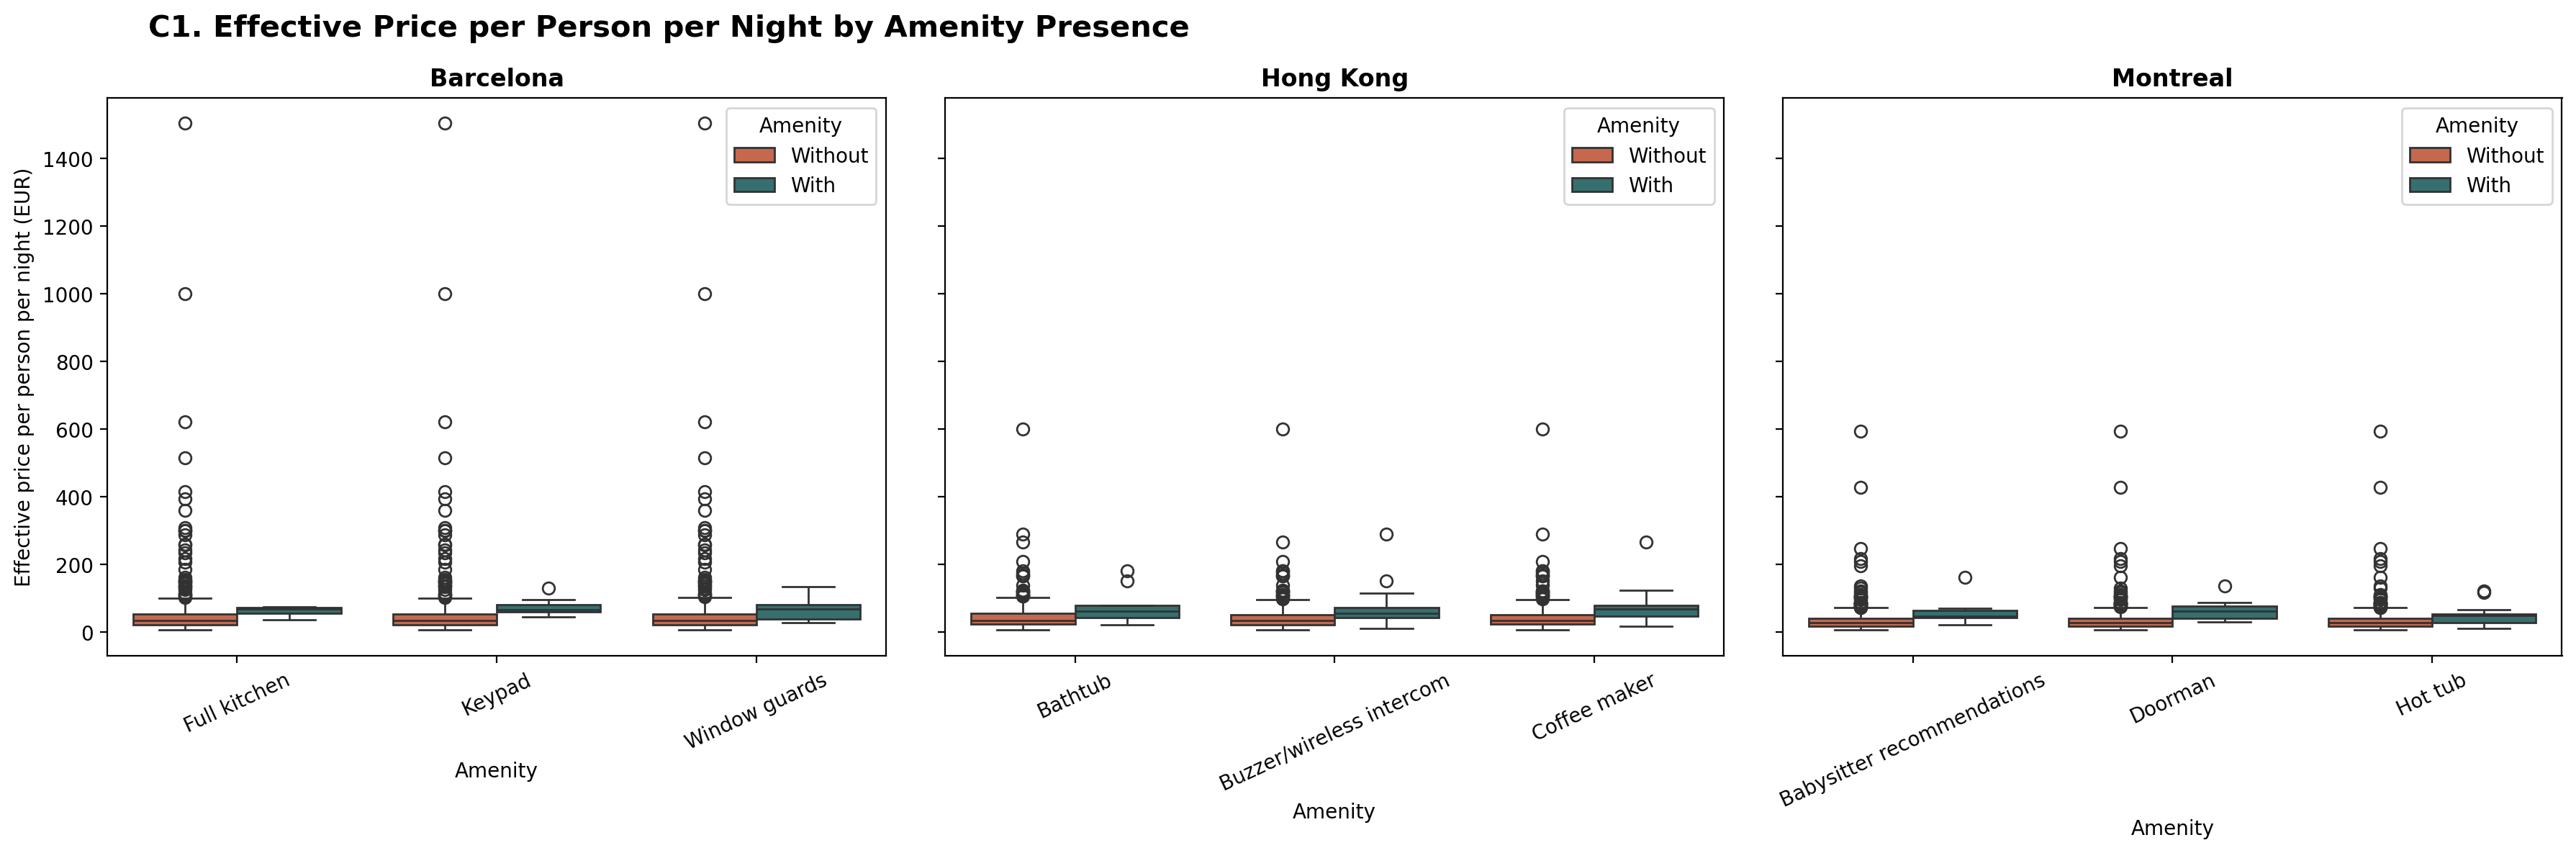

In [121]:
c1_plot_df = build_boxplot_df(
    c1_df,
    selected_amenities_df=c1_top3_df,
    metric_col="effective_price_pppn_eur",
)

if c1_plot_df.empty:
    print("C1 plot skipped because no amenity comparison data was produced.")
else:
    plot_city_amenity_boxplots(
        c1_plot_df,
        value_col="effective_price_pppn_eur",
        title="C1. Effective Price per Person per Night by Amenity Presence",
        y_label="Effective price per person per night (EUR)",
    )


For C1, the results suggest that amenity effects on price are real, but they are not uniform across cities. In all three markets, the strongest positive “price premium” amenities are those that likely signal a higher overall property standard rather than just a single extra feature. In Hong Kong, the clearest premium is associated with coffee maker, bathtub and buzzer/wireless intercom, while in Montreal the largest median differences appear for doorman, hot tub and babysitter recommendations. In Barcelona, window guards, full kitchen and keypad show the strongest upward shift in effective price per person per night.

The box plots show that listings with these amenities generally have higher medians, and in many cases also a wider interquartile range. This indicates not only higher central prices, but also greater heterogeneity within the more highly equipped segment. In other words, these amenities tend to appear more often in listings that are already positioned as mid-range or premium offers. The results should therefore be interpreted as an association with higher prices, not proof that adding one amenity alone will cause the full observed increase.

At the same time, some amenities appear to correlate with lower prices. This likely reflects market positioning rather than negative value. Amenities that are common in simpler, budget-oriented, or more compact listings may be associated with lower medians because they are typical of lower-priced accommodation segments. Therefore, an amenity can be useful to guests without being linked to a price premium.

Across cities, the ranking of top amenities is not perfectly stable, which suggests local market differences in what guests are willing to pay more for. However, the broader pattern is consistent: amenities that improve convenience, comfort, or perceived quality tend to be associated with higher prices, while more basic or widely expected features contribute less to price differentiation. Overall, C1 shows that amenities can serve as a meaningful pricing signal, especially when they reflect a broader upscale listing profile.


## C2. Luxury Amenity of Top-Rated Properties

### Decisions

- Property types are limited exactly to: `Aparthotel`, `Apartment`, `Condominium`, `Loft`, and `Serviced apartment`.
- Only listings with at least `30` reviews are kept.
- The top-rated subset is defined **within each city** using the city-specific `85th percentile` of `review_scores_rating`.
- Amenities with prevalence of at least `85%` inside the selected top-rated subset are treated as **essential**.
- All remaining amenities are treated as **optional luxury amenities**.


In [122]:
C2_CITIES = ["Sydney", "New York"]
C2_PROPERTY_TYPES = [
    "Aparthotel",
    "Apartment",
    "Condominium",
    "Loft",
    "Serviced apartment",
]

c2_cutoff_pipeline = [
    {
        "$match": {
            "address.market": {"$in": C2_CITIES},
            "property_type": {"$in": C2_PROPERTY_TYPES},
            "number_of_reviews": {"$gte": 30},
            "review_scores.review_scores_rating": {"$ne": None},
        }
    },
    {
        "$project": {
            "_id": 1,
            "city": "$address.market",
            "rating_num": {"$toDouble": "$review_scores.review_scores_rating"},
        }
    },
]

c2_cutoff_df = pd.DataFrame(list(listings.aggregate(c2_cutoff_pipeline)))
c2_cutoff_df = ensure_columns(c2_cutoff_df, ["_id", "city", "rating_num"])
c2_rating_cutoffs = c2_cutoff_df.groupby("city")["rating_num"].quantile(0.85).to_dict()

c2_rating_cutoffs


{'New York': 98.0, 'Sydney': 98.0}

In [123]:
c2_selection_pipeline = [
    {
        "$match": {
            "address.market": {"$in": C2_CITIES},
            "property_type": {"$in": C2_PROPERTY_TYPES},
            "number_of_reviews": {"$gte": 30},
            "review_scores.review_scores_rating": {"$ne": None},
            "amenities.0": {"$exists": True},
        }
    },
    {
        "$addFields": {
            "rating_num": {"$toDouble": "$review_scores.review_scores_rating"},
        }
    },
    {
        "$match": {
            "$expr": {
                "$or": [
                    {
                        "$and": [
                            {"$eq": ["$address.market", "Sydney"]},
                            {
                                "$gte": [
                                    "$rating_num",
                                    float(c2_rating_cutoffs.get("Sydney", 0)),
                                ]
                            },
                        ]
                    },
                    {
                        "$and": [
                            {"$eq": ["$address.market", "New York"]},
                            {
                                "$gte": [
                                    "$rating_num",
                                    float(c2_rating_cutoffs.get("New York", 0)),
                                ]
                            },
                        ]
                    },
                ]
            }
        }
    },
    {
        "$project": {
            "_id": 1,
            "city": "$address.market",
            "property_type": 1,
            "rating_num": 1,
            "number_of_reviews": 1,
            "amenities": 1,
        }
    },
]

c2_selected_df = pd.DataFrame(list(listings.aggregate(c2_selection_pipeline)))
c2_selected_df = ensure_columns(
    c2_selected_df,
    ["_id", "city", "property_type", "rating_num", "number_of_reviews", "amenities"],
)
c2_selected_df["amenities"] = c2_selected_df["amenities"].apply(
    lambda x: x if isinstance(x, list) else []
)

c2_city_totals = (
    c2_selected_df.groupby("city")["_id"]
    .nunique()
    .rename("total_properties")
    .reset_index()
)

c2_exploded = c2_selected_df.explode("amenities").rename(
    columns={"amenities": "amenity"}
)
c2_exploded = c2_exploded[c2_exploded["amenity"].notna()].copy()

c2_prevalence_df = (
    c2_exploded.groupby(["city", "amenity"])["_id"]
    .nunique()
    .rename("listing_count")
    .reset_index()
    .merge(c2_city_totals, on="city", how="left")
)
c2_prevalence_df["prevalence_pct"] = (
    100 * c2_prevalence_df["listing_count"] / c2_prevalence_df["total_properties"]
)
c2_prevalence_df["amenity_group"] = np.where(
    c2_prevalence_df["prevalence_pct"] >= 85,
    "Essential",
    "Luxury",
)

c2_luxury_df = c2_prevalence_df[c2_prevalence_df["amenity_group"] == "Luxury"].copy()
c2_top10_each_city = (
    c2_luxury_df.sort_values(["city", "prevalence_pct"], ascending=[True, False])
    .groupby("city")
    .head(10)
    .reset_index(drop=True)
)

display(c2_top10_each_city.round(2))


,city,amenity,listing_count,total_properties,prevalence_pct,amenity_group
0,New York,Air conditioning,45,53,84.91,Luxury
1,New York,Carbon monoxide detector,45,53,84.91,Luxury
2,New York,Iron,45,53,84.91,Luxury
3,New York,Hot water,41,53,77.36,Luxury
4,New York,Laptop friendly workspace,39,53,73.58,Luxury
5,New York,Fire extinguisher,33,53,62.26,Luxury
6,New York,Cooking basics,32,53,60.38,Luxury
7,New York,Dishes and silverware,32,53,60.38,Luxury
8,New York,Stove,32,53,60.38,Luxury
9,New York,Microwave,31,53,58.49,Luxury


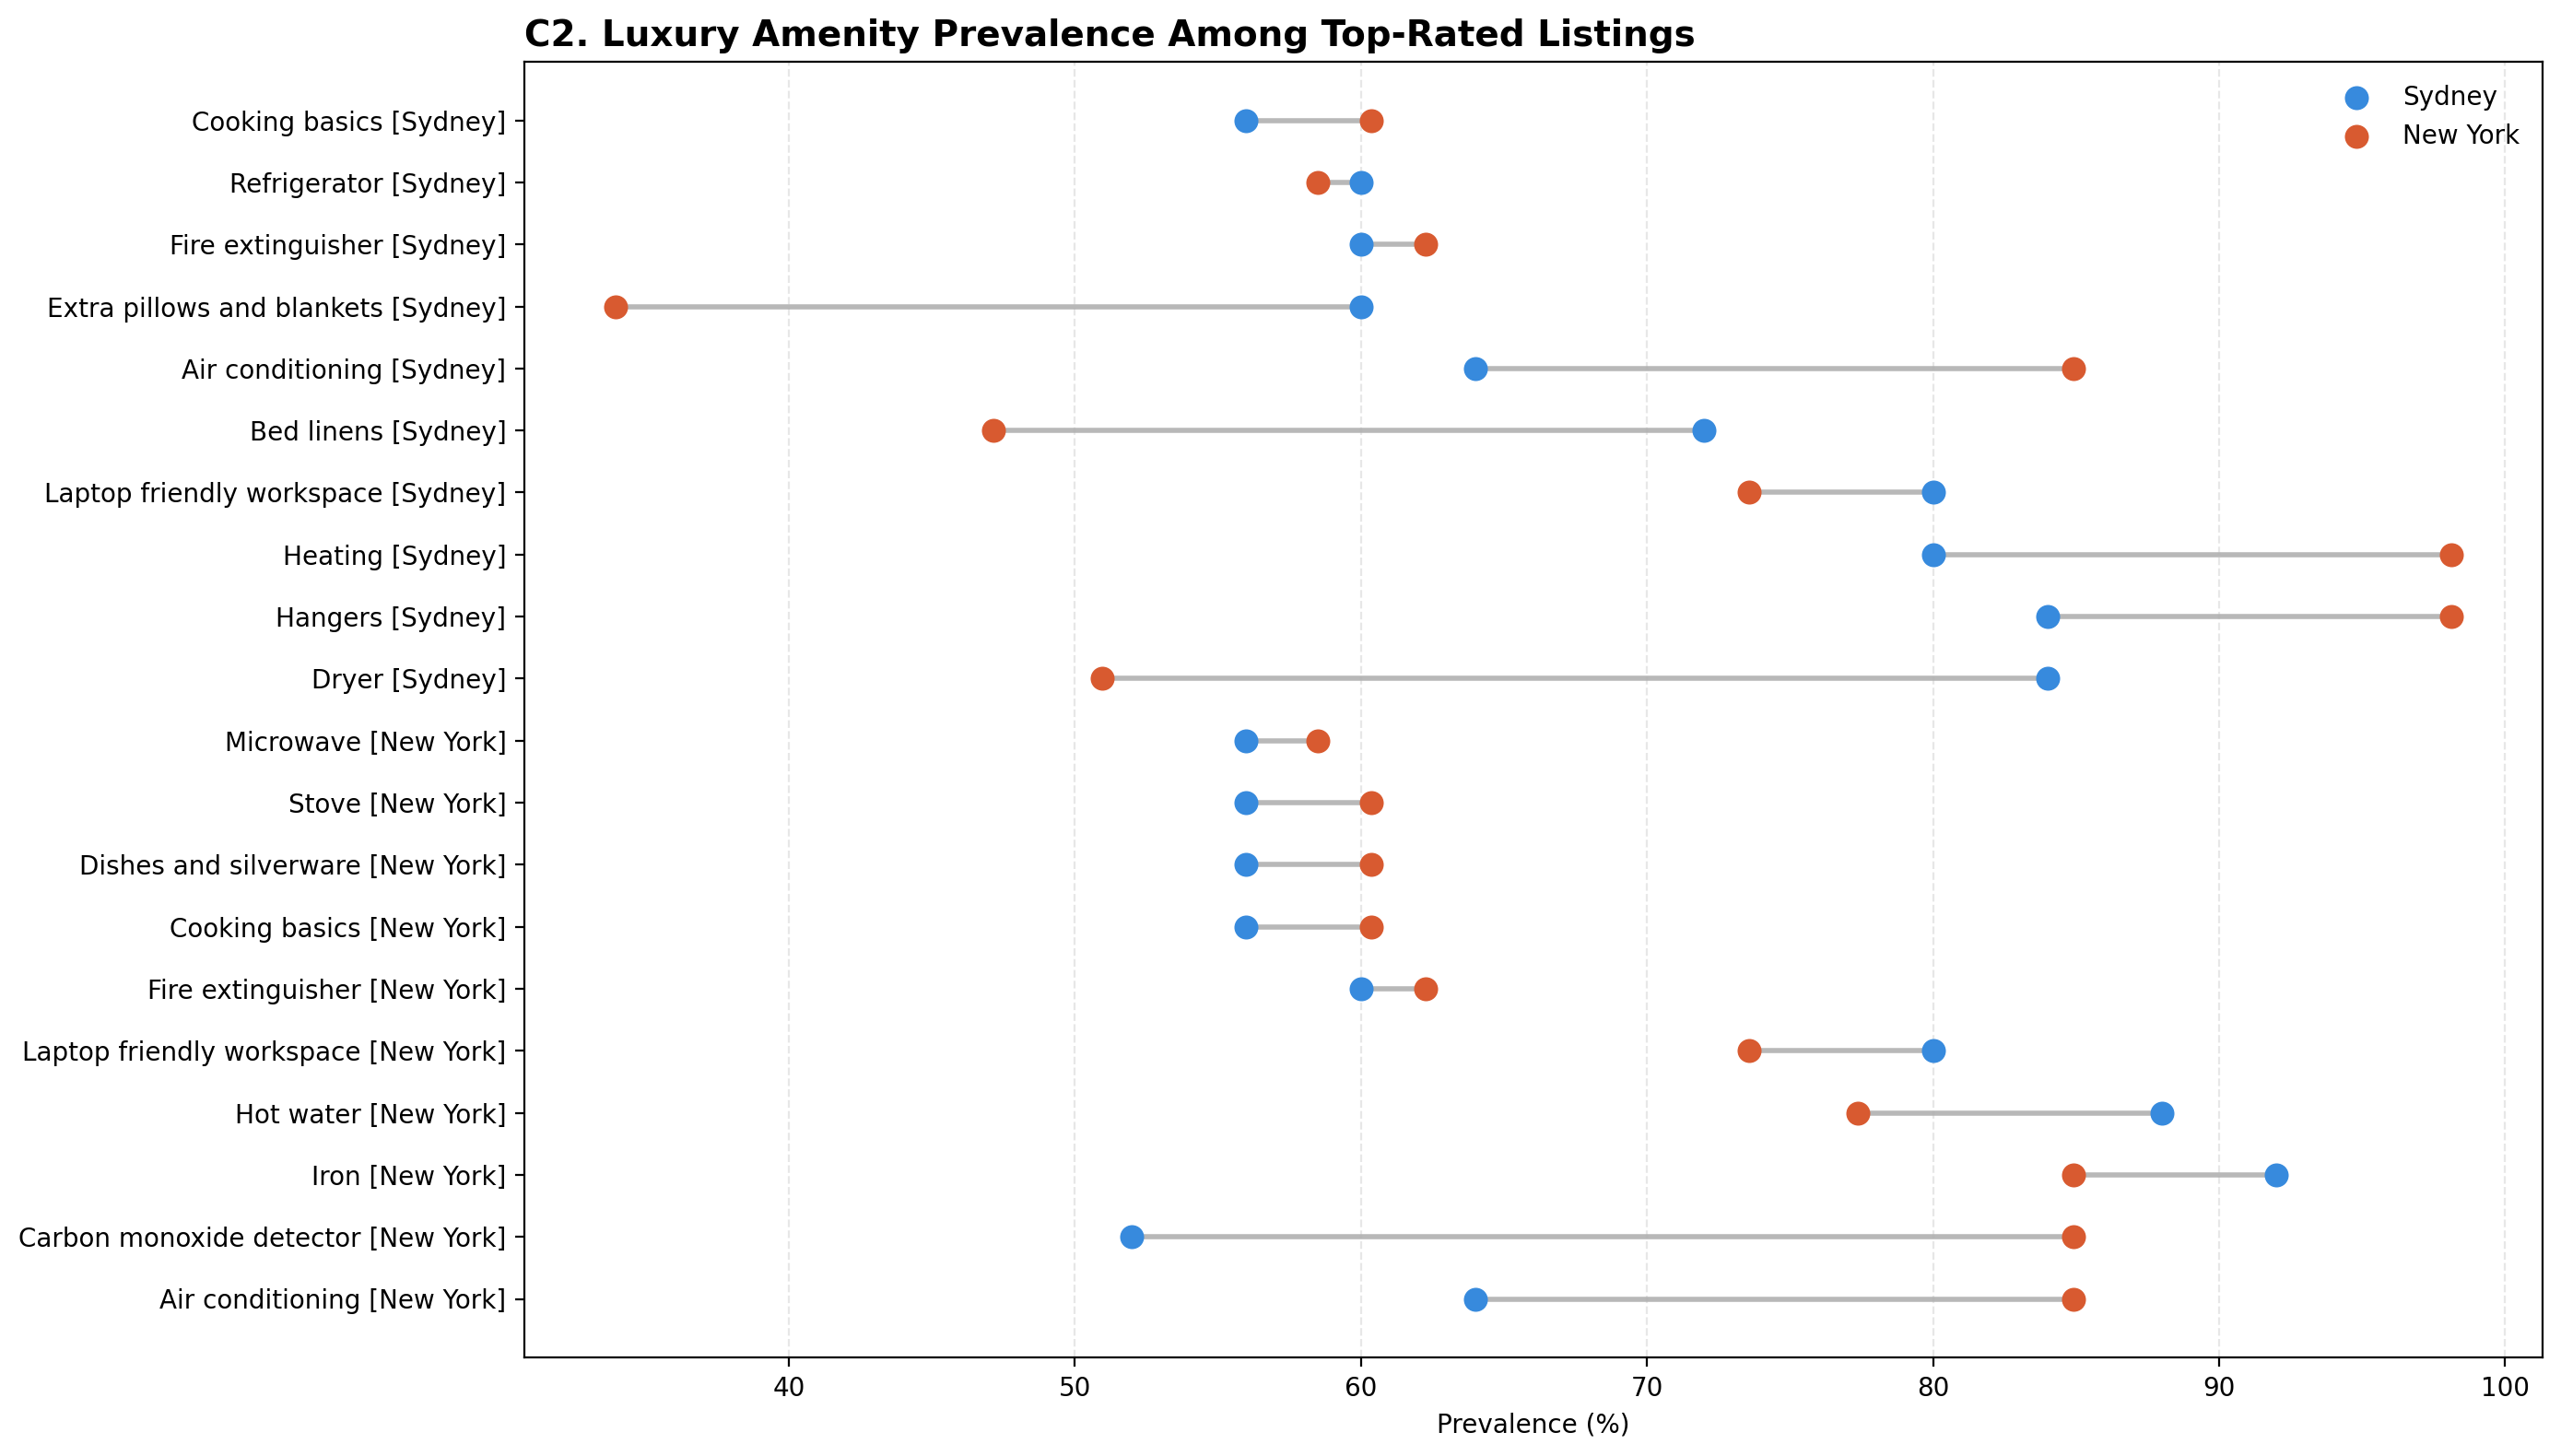

In [124]:
c2_plot_df = c2_top10_each_city[["city", "amenity"]].copy()
c2_plot_df["label"] = c2_plot_df["amenity"] + " [" + c2_plot_df["city"] + "]"

c2_plot_df = c2_plot_df.merge(
    c2_prevalence_df[c2_prevalence_df["city"] == "Sydney"][
        ["amenity", "prevalence_pct"]
    ].rename(columns={"prevalence_pct": "Sydney"}),
    on="amenity",
    how="left",
)
c2_plot_df = c2_plot_df.merge(
    c2_prevalence_df[c2_prevalence_df["city"] == "New York"][
        ["amenity", "prevalence_pct"]
    ].rename(columns={"prevalence_pct": "New York"}),
    on="amenity",
    how="left",
)
c2_plot_df[["Sydney", "New York"]] = c2_plot_df[["Sydney", "New York"]].fillna(0)
c2_plot_df["focus_city_prevalence"] = np.where(
    c2_plot_df["city"] == "Sydney", c2_plot_df["Sydney"], c2_plot_df["New York"]
)
c2_plot_df = c2_plot_df.sort_values(
    ["city", "focus_city_prevalence"], ascending=[True, False]
).reset_index(drop=True)

if c2_plot_df.empty:
    print("C2 plot skipped because no luxury amenity comparison data was produced.")
else:
    plot_double_lollipop(
        c2_plot_df,
        left_col="Sydney",
        right_col="New York",
        label_col="label",
        left_label="Sydney",
        right_label="New York",
        title="C2. Luxury Amenity Prevalence Among Top-Rated Listings",
    )


In [125]:
c2_explain_before = db.command(
    {
        "explain": {
            "aggregate": "listings",
            "pipeline": c2_selection_pipeline,
            "cursor": {},
        },
        "verbosity": "executionStats",
    }
)

db.listings.create_index(
    [
        ("address.market", 1),
        ("property_type", 1),
        ("number_of_reviews", 1),
        ("review_scores.review_scores_rating", -1),
    ],
    name="idx_c2_market_type_reviews_rating",
)

c2_explain_after = db.command(
    {
        "explain": {
            "aggregate": "listings",
            "pipeline": c2_selection_pipeline,
            "cursor": {},
        },
        "verbosity": "executionStats",
    }
)

c2_explain_table = utils.compare_explain_outputs(
    c2_explain_before,
    c2_explain_after,
    labels=["before_optimization", "after_optimization"],
)

c2_explain_table


,version,stage_type,execution_time_ms,documents_examined,keys_examined,memory_usage
0,before_optimization,COLLSCAN,19,5555,0,None
1,after_optimization,IXSCAN,4,346,357,None


The C2 analysis shows that top-rated properties in Sydney and New York share many essential amenities, while differing more clearly in their optional luxury features. This means highly rated listings in both cities meet a common baseline of comfort, while the amenities that distinguish them most are more city-specific.

In Sydney, the most prevalent luxury amenities are dryers, hangers and heating, whereas in New York the leading optional amenities are air conditioning, carbon monoxide detector and iron. The double lollipop chart highlights these contrasts well: amenities with similar prevalence in both cities suggest a shared premium standard, while large gaps point to differences in local housing style, guest expectations, or market positioning.

The results also suggest that “luxury” is not universal. Some amenities appear strongly tied to one city, which may reflect local building characteristics or traveler preferences rather than overall quality alone.

From a query-performance perspective, the optimized version should reduce documents examined and improve execution time by filtering more efficiently on city, property type, review count, and rating. Overall, the findings show that top-rated listings combine a stable essential foundation with a smaller set of optional amenities that vary meaningfully between Sydney and New York.


## C3. Amenity Value Analysis and Suggestion

### Weighted Value Metric

The following custom metric combines guest-perceived value and price:

`weighted_value_score = 0.60 * value_rating_score + 0.30 * affordability_score + 0.10 * review_confidence_score`

Where:

- `value_rating_score = review_scores_value / 10`
- `affordability_score` is the inverse min-max normalized effective price per person per night **within each city**
- `review_confidence_score = min(number_of_reviews / 50, 1)`

Why these weights:

- `review_scores_value` gets the highest weight because it directly measures perceived value.
- Price still matters strongly, so affordability receives a meaningful but smaller weight.
- Review count is included as a light confidence term so an amenity is not driven only by a few low-sample listings.

Amenities with prevalence above `85%` in a city are excluded from the impact ranking because they do not create useful variation.


In [126]:
C3_CITIES = ["Hong Kong", "Barcelona"]

c3_pipeline = [
    {
        "$match": {
            "address.market": {"$in": C3_CITIES},
            "review_scores.review_scores_value": {"$ne": None},
            "amenities.0": {"$exists": True},
        }
    },
    *build_common_numeric_stage(),
    *build_effective_price_stage(),
    {
        "$project": {
            "_id": 1,
            "listing_name": "$name",
            "city": "$address.market",
            "property_type": 1,
            "amenities": 1,
            "review_value_num": 1,
            "review_count_num": 1,
            "effective_price_pppn_local": 1,
        }
    },
]

c3_df = pd.DataFrame(list(listings.aggregate(c3_pipeline)))
c3_df = ensure_columns(
    c3_df,
    [
        "_id",
        "listing_name",
        "city",
        "property_type",
        "amenities",
        "review_value_num",
        "review_count_num",
        "effective_price_pppn_local",
    ],
)

if c3_df.empty:
    print(
        "C3 returned no listings. Check whether the normalized listings collection contains Hong Kong and Barcelona records with value scores."
    )
    c3_impact_df = pd.DataFrame(
        columns=[
            "city",
            "amenity",
            "listing_count",
            "total_listings",
            "prevalence",
            "median_with",
            "median_without",
            "mean_with",
            "mean_without",
            "median_delta",
            "mean_delta",
        ]
    )
else:
    c3_df = c3_df[
        c3_df["review_value_num"].notna()
        & c3_df["effective_price_pppn_local"].notna()
        & (c3_df["effective_price_pppn_local"] > 0)
    ].copy()
    c3_df["amenities"] = c3_df["amenities"].apply(
        lambda x: x if isinstance(x, list) else []
    )
    c3_df = apply_eur_conversion(c3_df)

    c3_df["value_rating_score"] = c3_df["review_value_num"] / 10.0
    c3_df["review_confidence_score"] = (c3_df["review_count_num"] / 50.0).clip(
        upper=1.0
    )
    c3_df["affordability_score"] = c3_df.groupby("city")[
        "effective_price_pppn_eur"
    ].transform(normalize_city_inverse_score)

    c3_df["weighted_value_score"] = (
        0.60 * c3_df["value_rating_score"]
        + 0.30 * c3_df["affordability_score"]
        + 0.10 * c3_df["review_confidence_score"]
    ).round(4)

    c3_impact_df = compute_amenity_impact(
        c3_df,
        metric_col="weighted_value_score",
        min_presence=5,
        max_prevalence=0.85,
    )

c3_top3_df = (
    c3_impact_df.sort_values(["city", "median_delta"], ascending=[True, False])
    .groupby("city")
    .head(3)
    .reset_index(drop=True)
)

display(c3_top3_df.round(4))


,city,amenity,listing_count,total_listings,prevalence,median_with,median_without,mean_with,mean_without,median_delta,mean_delta
0,Barcelona,Full kitchen,8,330,0.0242,0.9324,0.8734,0.9244,0.8521,0.0590,0.0723
1,Barcelona,Indoor fireplace,6,330,0.0182,0.9316,0.8740,0.8964,0.8531,0.0576,0.0433
2,Barcelona,translation missing: en.hosting_amenity_49,40,330,0.1212,0.9220,0.8647,0.9126,0.8457,0.0574,0.0669
3,Hong Kong,Pets live on this property,7,312,0.0224,0.9129,0.8601,0.9095,0.8448,0.0528,0.0647
4,Hong Kong,Indoor fireplace,6,312,0.0192,0.9101,0.8600,0.9246,0.8447,0.0501,0.0799
5,Hong Kong,Keypad,40,312,0.1282,0.8990,0.8572,0.8768,0.8418,0.0417,0.0350


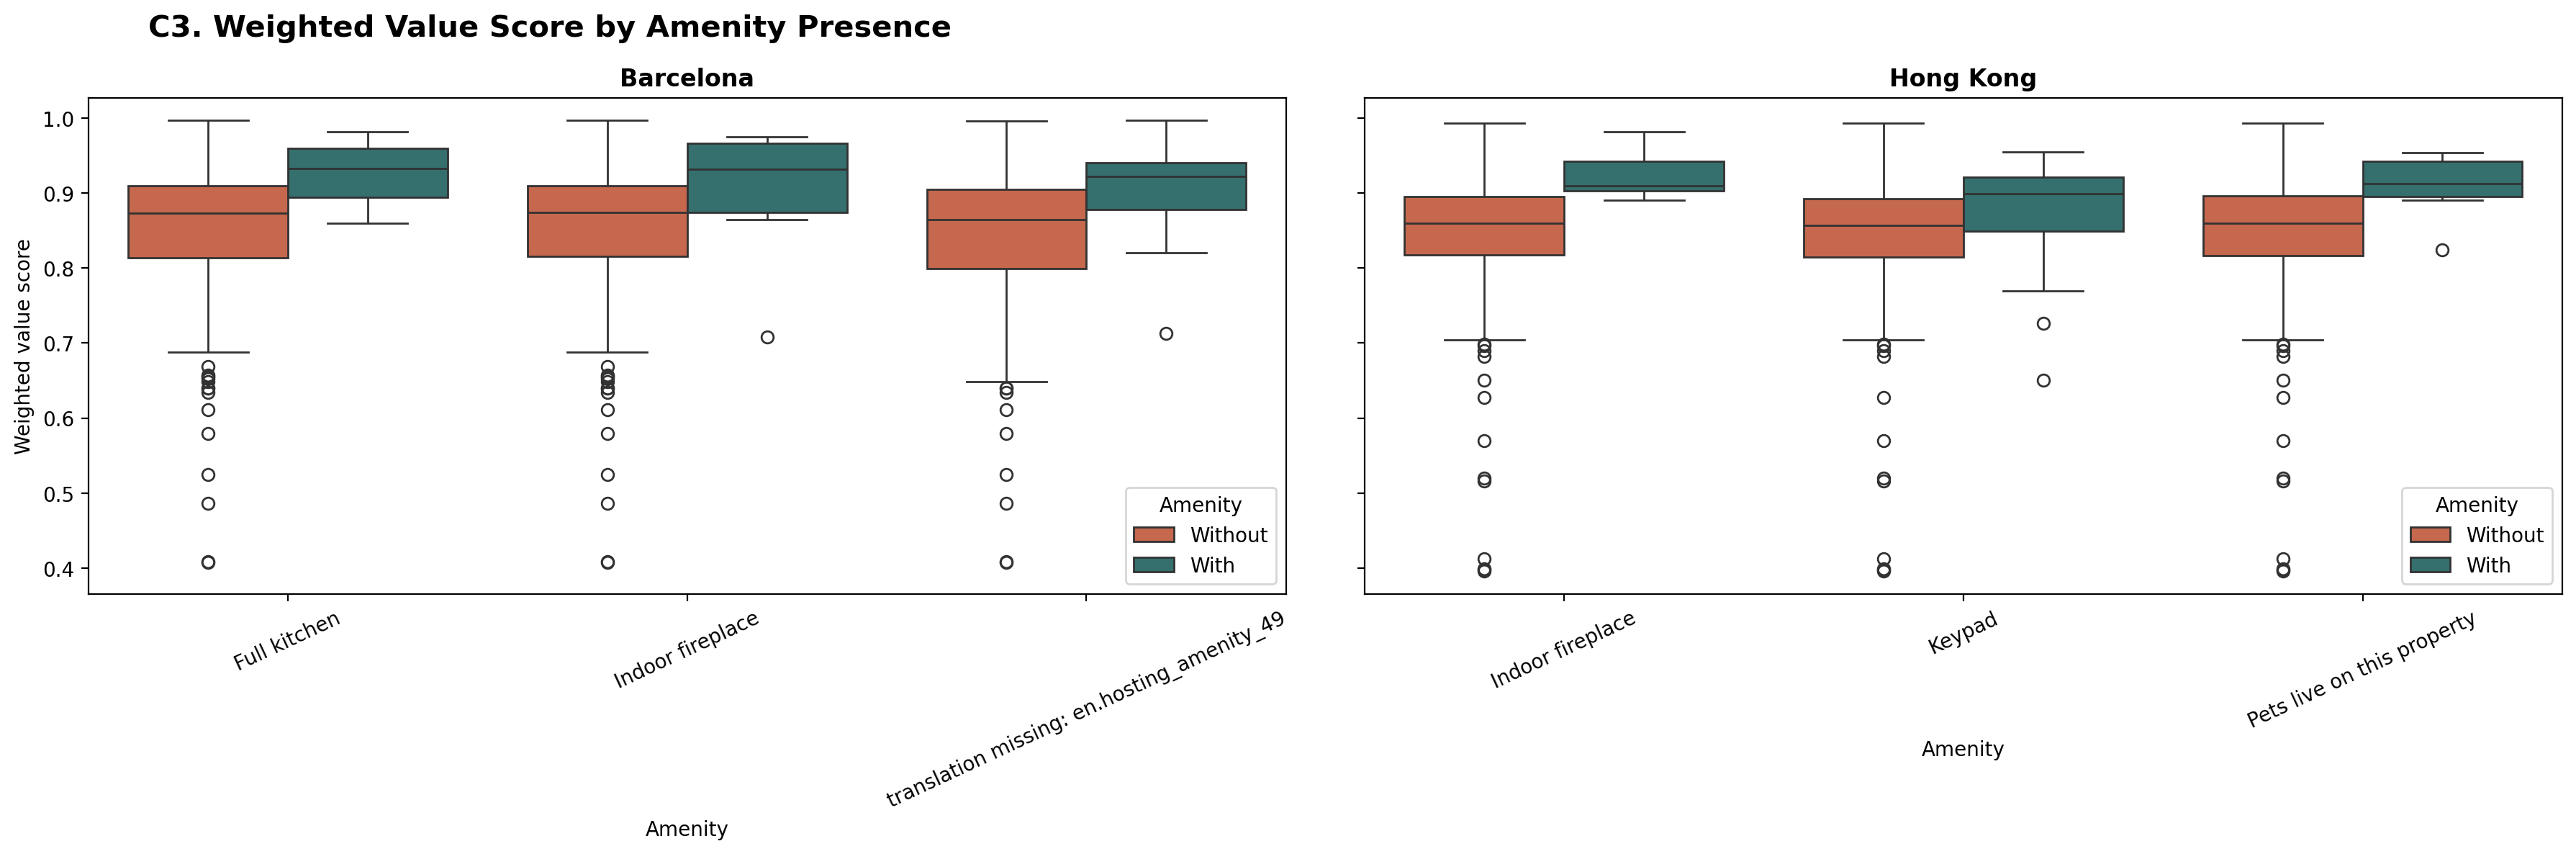

In [127]:
c3_plot_df = build_boxplot_df(
    c3_df,
    selected_amenities_df=c3_top3_df,
    metric_col="weighted_value_score",
)

if c3_plot_df.empty:
    print(
        "C3 plot skipped because no weighted-value amenity comparison data was produced."
    )
else:
    plot_city_amenity_boxplots(
        c3_plot_df,
        value_col="weighted_value_score",
        title="C3. Weighted Value Score by Amenity Presence",
        y_label="Weighted value score",
    )


## Note

One of the amenities identified in the results appears as `translation missing: en.hosting_amenity_49`. This is treated as a source-data translation artifact rather than a meaningful English amenity label. In other words, the dataset preserves an internal Airbnb amenity key, but the corresponding human-readable translation is missing. Because the exact amenity meaning cannot be verified reliably from the provided dataset alone, it is interpreted cautiously and not over-explained substantively.


In [128]:
if c3_df.empty or "weighted_value_score" not in c3_df.columns:
    c3_suggestions_df = pd.DataFrame(
        columns=[
            "_id",
            "listing_name",
            "city",
            "property_type",
            "weighted_value_score",
            "city_median",
            "suggested_amenities",
            "expected_median_gain",
        ]
    )
else:
    c3_city_medians = (
        c3_df.groupby("city")["weighted_value_score"].median().rename("city_median")
    )
    c3_candidates_df = c3_df.merge(c3_city_medians, on="city", how="left")
    c3_candidates_df = c3_candidates_df[
        c3_candidates_df["weighted_value_score"] < c3_candidates_df["city_median"]
    ].copy()

    c3_positive_amenities = c3_impact_df[c3_impact_df["median_delta"] > 0].copy()
    c3_positive_amenities["priority_rank"] = c3_positive_amenities.groupby("city")[
        "median_delta"
    ].rank(method="first", ascending=False)

    suggestion_rows = []
    for row in c3_candidates_df.to_dict("records"):
        city_options = c3_positive_amenities[
            c3_positive_amenities["city"] == row["city"]
        ].copy()
        missing_options = (
            city_options[~city_options["amenity"].isin(row["amenities"])]
            .sort_values("median_delta", ascending=False)
            .head(3)
        )

        suggestion_rows.append(
            {
                "_id": row["_id"],
                "listing_name": row["listing_name"],
                "city": row["city"],
                "property_type": row["property_type"],
                "weighted_value_score": row["weighted_value_score"],
                "city_median": row["city_median"],
                "suggested_amenities": missing_options["amenity"].tolist(),
                "expected_median_gain": missing_options["median_delta"]
                .round(4)
                .tolist(),
            }
        )

    c3_suggestions_df = pd.DataFrame(suggestion_rows)

display(c3_suggestions_df.head(20))


,_id,listing_name,city,property_type,weighted_value_score,city_median,suggested_amenities,expected_median_gain
0,29872103,One Bedroom Apartment (4pers) near Sagrada Fam...,Barcelona,Aparthotel,0.8405,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
1,23217617,habitación privada plaza España 2,Barcelona,Apartment,0.8650,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
2,25233509,"Terrace, sea view at Diagonal Mar!",Barcelona,Apartment,0.8463,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
3,27983911,Nice and cozy apartment in Sagrada Familia.,Barcelona,Apartment,0.8675,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
4,30759793,Eric Vökel Boutique Apartments - Sagrada Famil...,Barcelona,Apartment,0.8637,0.87445,"[Indoor fireplace, translation missing: en.hos...","[0.0576, 0.0574, 0.0535]"
5,31460245,Penthouse 3 bedrooms apartment B376,Barcelona,Apartment,0.8244,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
6,31951516,Centre of Barcelona Room in penthouse with ter...,Barcelona,Apartment,0.8646,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
7,32160778,Perfect Location! Suite Room 1 min from La Rambla,Barcelona,Apartment,0.7599,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
8,32401490,Big apartment by Barcelona's main train station,Barcelona,Apartment,0.8669,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"
9,32459348,Quality in the town of the city,Barcelona,Apartment,0.7838,0.87445,"[Full kitchen, Indoor fireplace, translation m...","[0.059, 0.0576, 0.0574]"


The C3 analysis suggests that guest-perceived value is shaped by more than low price alone. The weighted metric gives the greatest importance to review_scores_value, while still rewarding affordability and giving a smaller adjustment for review volume. This makes the final score more balanced than using price or ratings in isolation. A listing can therefore perform well by combining strong value ratings with reasonable effective cost per person per night, rather than simply being the cheapest option.

For Barcelona and Hong Kong, the most impactful amenities are those associated with higher median weighted value scores when present than when absent. This implies that some amenities improve how guests judge the relationship between quality and price, not just the absolute standard of the property. At the same time, the strongest amenities are not necessarily identical across the two cities, which suggests that local market expectations matter. What guests perceive as “good value” in one city may not carry the same effect in another.

The recommendation table focuses on below-median listings and proposes amenities that are currently missing but are positively associated with higher weighted value. These suggestions are practical because they target features linked to better perceived value rather than only higher prices. However, the results remain associative rather than causal: an amenity may be acting as a signal of a broader hosting standard, better maintenance, or a more complete guest experience. Overall, C3 indicates that improving perceived value likely depends on a combination of fair pricing and a thoughtful amenity package tailored to each city.


# D. Host Performance Expert


## 1. Part D Preprocessing


In [129]:
# Part D depends heavily on grouping and joining listings by `host_id`.
# This index was missing in the current database state, so it is created here once and then reused.

required_indexes = {
    "idx_listings_host_id": [("host_id", 1)],
}

for index_name, index_spec in required_indexes.items():
    if index_name not in db.listings.index_information():
        db.listings.create_index(index_spec, name=index_name)

print("Current listings indexes:")
pprint(db.listings.index_information())


Current listings indexes:
{'_id_': {'key': [('_id', 1)], 'v': 2},
 'idx_c2_market_type_reviews_rating': {'key': [('address.market', 1),
                                               ('property_type', 1),
                                               ('number_of_reviews', 1),
                                               ('review_scores.review_scores_rating',
                                                -1)],
                                       'v': 2},
 'idx_listings_host_id': {'key': [('host_id', 1)], 'v': 2}}


In [130]:
# Widen pandas display settings so intermediate result tables are easier to inspect.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 160)


## 2. Reuse Strategy and Shared Preprocessing


This notebook intentionally **reuses the normalized collections created in Part B** instead of rebuilding the schema again. The expected base collections are:

- `hosts`
- `listings`
- `reviews`

This keeps Part D focused on analysis-specific preparation rather than repeating the full normalization workflow.

**Important note:** no D-specific derived collection or optimization index is created in this shared preprocessing section on purpose. For D2 you need a clean before/after `explain()` comparison, and for D3 the final `popularity_score` formula should be decided before writing anything permanently to the database.

If any of the checks below reveal something ambiguous, review it before solving the task and document the decision in the relevant markdown cell.


In [131]:
# Confirm that the normalized collections produced earlier in the project are available.
required_collections = ["hosts", "listings", "reviews"]
existing_collections = set(db.list_collection_names())
missing_collections = [
    name for name in required_collections if name not in existing_collections
]

print("Available collections:", sorted(existing_collections))

if missing_collections:
    print(f"Missing normalized collections: {missing_collections}")
    print(
        "Run the normalization/preprocessing steps from PartB_AP.ipynb before continuing with Part D."
    )
else:
    print("All normalized collections required for Part D are available.")


Available collections: ['hosts', 'listings', 'listingsAndReviews_HW2', 'listingsAndReviews_HW2_new', 'reviews']
All normalized collections required for Part D are available.


### 2.1 Reused Collections


In [132]:
# Keep direct handles to the three collections used throughout Part D.
hosts = db.hosts
listings = db.listings
reviews = db.reviews

# Basic sanity checks on collection sizes.
print(f"hosts documents: {hosts.count_documents({})}")
print(f"listings documents: {listings.count_documents({})}")
print(f"reviews documents: {reviews.count_documents({})}")

# Show the currently available indexes before running the heavier aggregations.
print("Current index names:")
print("hosts:", list(hosts.index_information().keys()))
print("listings:", list(listings.index_information().keys()))
print("reviews:", list(reviews.index_information().keys()))

# Inspect one host document to confirm the fields needed for D2 are present.
print("Sample host document:")
pprint(
    hosts.find_one(
        {},
        {
            "_id": 0,
            "host_id": 1,
            "host_is_superhost": 1,
            "host_response_time": 1,
            "host_response_rate": 1,
            "host_identity_verified": 1,
        },
    )
)

# Inspect one listing document to confirm the pricing and availability fields needed for D1 and D3.
print("Sample listing document:")
pprint(
    listings.find_one(
        {},
        {
            "_id": 1,
            "host_id": 1,
            "name": 1,
            "address.market": 1,
            "property_type": 1,
            "price": 1,
            "cleaning_fee": 1,
            "extra_people": 1,
            "security_deposit": 1,
            "guests_included": 1,
            "cancellation_policy": 1,
            "review_scores.review_scores_rating": 1,
            "availability": 1,
        },
    )
)


hosts documents: 5104
listings documents: 5555
reviews documents: 149792
Current index names:
hosts: ['_id_', 'idx_hosts_host_id_unique']
listings: ['_id_', 'idx_c2_market_type_reviews_rating', 'idx_listings_host_id']
reviews: ['_id_', 'idx_reviews_listing_id']
Sample host document:
{'host_id': '70143192',
 'host_identity_verified': False,
 'host_is_superhost': False,
 'host_response_rate': 100,
 'host_response_time': 'within an hour'}
Sample listing document:
{'_id': '10006546',
 'address': {'market': 'Porto'},
 'availability': {'availability_30': 28,
                  'availability_365': 239,
                  'availability_60': 47,
                  'availability_90': 74},
 'cancellation_policy': 'moderate',
 'cleaning_fee': Decimal128('35.00'),
 'extra_people': Decimal128('15.00'),
 'guests_included': 6,
 'host_id': '51399391',
 'name': 'Ribeira Charming Duplex',
 'price': Decimal128('80.00'),
 'property_type': 'House',
 'review_scores': {'review_scores_rating': 89},
 'security_dep

### 2.2 Fields to Review Before Solving the Tasks

The checks below are intentionally lightweight. They are here to surface the fields that are most likely to require a decision in Part D.

**Check these carefully before finalizing your task logic:**

- `price`, `cleaning_fee`, `extra_people`, and `guests_included` for D1.
- `host_response_time`, `host_response_rate`, `host_is_superhost`, `host_identity_verified`, and `cancellation_policy` for D2.
- `review_scores.review_scores_rating` and the availability fields for D3.
- Currency comparability across cities if you plan to discuss raw price levels between cities.
- Use the assumption `missing cleaning_fee = 0` unless you find evidence that a different rule is required.
- Whether `extra_people` applies for the second guest or only above `guests_included`.
- Whether a field with many missing values needs filtering, imputation, or an explicit exclusion rule.


In [133]:
# Profile missingness and category values before building any analysis pipeline.
target_cities_preview = ["Hong Kong", "Montreal", "Barcelona"]

inspection_summary = {
    "listings_in_target_cities": listings.count_documents(
        {"address.market": {"$in": target_cities_preview}}
    ),
    "listings_missing_price": listings.count_documents({"price": None}),
    "listings_missing_price_target_cities": listings.count_documents(
        {"address.market": {"$in": target_cities_preview}, "price": None}
    ),
    "listings_missing_price_with_weekly_price_target_cities": listings.count_documents(
        {
            "address.market": {"$in": target_cities_preview},
            "price": None,
            "weekly_price": {"$ne": None},
        }
    ),
    "listings_missing_cleaning_fee": listings.count_documents({"cleaning_fee": None}),
    "listings_missing_extra_people": listings.count_documents({"extra_people": None}),
    "listings_missing_security_deposit": listings.count_documents(
        {"security_deposit": None}
    ),
    "listings_missing_guests_included": listings.count_documents(
        {"guests_included": None}
    ),
    "listings_missing_overall_rating": listings.count_documents(
        {"review_scores.review_scores_rating": None}
    ),
    "listings_missing_availability_365": listings.count_documents(
        {"availability.availability_365": None}
    ),
    "hosts_missing_response_time": hosts.count_documents({"host_response_time": None}),
    "hosts_missing_response_rate": hosts.count_documents({"host_response_rate": None}),
    "hosts_missing_superhost_flag": hosts.count_documents({"host_is_superhost": None}),
    "hosts_missing_verified_flag": hosts.count_documents(
        {"host_identity_verified": None}
    ),
}

pprint(inspection_summary)

# Review the real categorical values that appear in fields used later for feature engineering.
print("Distinct host_response_time values:")
pprint(
    sorted(value for value in hosts.distinct("host_response_time") if value is not None)
)

print("Distinct cancellation_policy values:")
pprint(
    sorted(
        value for value in listings.distinct("cancellation_policy") if value is not None
    )
)

# Check whether weekly prices can rescue listings with missing nightly prices in the target cities.
print("Missing price overlap with weekly_price inside target cities:")
pprint(
    list(
        listings.aggregate(
            [
                {
                    "$match": {
                        "address.market": {"$in": target_cities_preview},
                        "price": None,
                    }
                },
                {
                    "$group": {
                        "_id": "$address.market",
                        "missing_price_count": {"$sum": 1},
                        "non_null_weekly_price_count": {
                            "$sum": {"$cond": [{"$ne": ["$weekly_price", None]}, 1, 0]}
                        },
                    }
                },
                {"$sort": {"_id": 1}},
            ]
        )
    )
)


{'hosts_missing_response_rate': 1381,
 'hosts_missing_response_time': 1381,
 'hosts_missing_superhost_flag': 0,
 'hosts_missing_verified_flag': 0,
 'listings_in_target_cities': 1899,
 'listings_missing_availability_365': 0,
 'listings_missing_cleaning_fee': 1531,
 'listings_missing_extra_people': 0,
 'listings_missing_guests_included': 0,
 'listings_missing_overall_rating': 1474,
 'listings_missing_price': 1682,
 'listings_missing_price_target_cities': 581,
 'listings_missing_price_with_weekly_price_target_cities': 57,
 'listings_missing_security_deposit': 2084}
Distinct host_response_time values:
['a few days or more', 'within a day', 'within a few hours', 'within an hour']
Distinct cancellation_policy values:
['flexible',
 'moderate',
 'strict_14_with_grace_period',
 'super_strict_30',
 'super_strict_60']
Missing price overlap with weekly_price inside target cities:
[{'_id': 'Barcelona',
  'missing_price_count': 198,
  'non_null_weekly_price_count': 198},
 {'_id': 'Hong Kong',
  'mis

### 2.3 Shared Helper Expressions

These helpers are reusable expression builders used throughout Part D. Their role is to standardize repeated conversion and arithmetic logic so that the task sections can focus on modelling decisions rather than low-level data-cleaning details.

- `to_double_or_zero(field_expr)` converts a MongoDB field to numeric form and replaces missing values with `0`. This is suitable for additive components such as `cleaning_fee`, `extra_people`, and availability fields.
- `to_double_or_none(field_expr)` converts a field to numeric form while preserving missingness as `None`. This is appropriate for analytical variables such as review scores, where missing data should remain visible.
- `percentage_string_to_double(field_expr)` converts percentage strings such as `"90%"` into numeric values such as `90.0`.
- `safe_divide(numerator, denominator, default_value=0)` performs guarded division and returns a default value whenever the denominator is invalid or zero.

Using these shared expressions keeps the later pipelines consistent and easier to justify in the final report.


In [134]:
# Shared constants used across all Part D tasks.
# Keeping them in one place makes the core assumptions explicit and easy to revise.
TARGET_CITIES = ["Hong Kong", "Montreal", "Barcelona"]
TARGET_GUESTS = 2
TARGET_NIGHTS = 7


def to_double_or_zero(field_expr):
    """Convert a MongoDB field to double and replace invalid or missing values with 0.

    This helper is used for additive numeric components where a missing value can be treated as
    the absence of a charge or of future unavailability, such as `cleaning_fee`, `extra_people`,
    and the availability counters.
    """
    return {
        "$convert": {
            "input": field_expr,
            "to": "double",
            "onError": 0.0,
            "onNull": 0.0,
        }
    }


def to_double_or_none(field_expr):
    """Convert a MongoDB field to double while preserving missingness as None.

    This helper is preferable when a missing numeric value should lead to filtering or explicit
    handling later in the analysis, for example `price`, `weekly_price`, and review scores.
    """
    return {
        "$convert": {
            "input": field_expr,
            "to": "double",
            "onError": None,
            "onNull": None,
        }
    }


def percentage_string_to_double(field_expr):
    """Convert numeric or percentage-formatted MongoDB values into doubles.

    The Airbnb data mixes plain numeric response rates with strings such as `95%`. This helper
    accepts both representations and still preserves missing or invalid values as None.
    """
    return {
        "$switch": {
            "branches": [
                {
                    "case": {
                        "$in": [
                            {"$type": field_expr},
                            ["int", "long", "double", "decimal"],
                        ]
                    },
                    "then": {
                        "$convert": {
                            "input": field_expr,
                            "to": "double",
                            "onError": None,
                            "onNull": None,
                        }
                    },
                },
                {
                    "case": {"$eq": [{"$type": field_expr}, "string"]},
                    "then": {
                        "$convert": {
                            "input": {
                                "$replaceAll": {
                                    "input": field_expr,
                                    "find": "%",
                                    "replacement": "",
                                }
                            },
                            "to": "double",
                            "onError": None,
                            "onNull": None,
                        }
                    },
                },
            ],
            "default": None,
        }
    }


def safe_divide(numerator, denominator, default_value=0):
    """Perform guarded division inside a MongoDB expression.

    If the denominator is not strictly positive, the expression returns `default_value` instead of
    failing. This keeps normalized metrics and weighted scores stable in edge cases.
    """
    return {
        "$cond": [
            {"$gt": [denominator, 0]},
            {"$divide": [numerator, denominator]},
            default_value,
        ]
    }


def parse_bool_value(value):
    """Convert mixed MongoDB boolean representations into Python 0/1 flags.

    The Airbnb dataset stores some logical values as booleans and some as strings, so a single
    normalization helper keeps the feature engineering consistent across D2.
    """
    if pd.isna(value):
        return None

    normalized = str(value).strip().lower()
    if normalized in {"true", "t", "yes", "1"}:
        return 1
    if normalized in {"false", "f", "no", "0"}:
        return 0
    return None


def parse_percentage_value(value):
    """Convert Python-side percentage strings such as `90%` into floats.

    This is the pandas-side companion to `percentage_string_to_double` and is used after the host
    aggregation has already been materialized into a DataFrame.
    """
    if pd.isna(value):
        return None

    cleaned = str(value).strip().replace("%", "")
    if cleaned == "":
        return None

    try:
        return float(cleaned)
    except ValueError:
        return None


def extract_index_names_from_plan(plan):
    """Recursively collect index names from a MongoDB winning-plan tree.

    MongoDB nests execution plans, so a small recursive helper is the simplest way to recover all
    indexes touched by the cursor stage in an `explain()` output.
    """
    index_names = set()
    if not isinstance(plan, dict):
        return index_names

    if plan.get("stage") == "IXSCAN" and "indexName" in plan:
        index_names.add(plan["indexName"])

    for key in [
        "inputStage",
        "innerStage",
        "outerStage",
        "leftChild",
        "rightChild",
        "thenStage",
        "elseStage",
    ]:
        if key in plan:
            index_names.update(extract_index_names_from_plan(plan[key]))

    for key in ["inputStages", "shards"]:
        for child in plan.get(key, []):
            index_names.update(extract_index_names_from_plan(child))

    return index_names


def summarize_aggregate_explain(explain_plan):
    """Extract a compact performance summary from a MongoDB aggregation explain plan.

    The raw explain output is nested and stage-specific. This helper standardizes the fields needed
    for the D2 comparison table: stage pattern, execution time, examined documents, examined keys,
    index usage, and whether MongoDB reported any spill or stage-level memory footprint.
    """
    stage_names = []
    total_docs_examined = 0
    total_keys_examined = 0
    execution_time_ms = 0
    indexes_used = set()
    reported_memory_bytes = []
    used_disk = False

    for stage in explain_plan.get("stages", []):
        stage_name = next(iter(stage.keys()))
        stage_names.append(stage_name)

        if stage_name == "$cursor":
            cursor_body = stage[stage_name]
            execution_stats = cursor_body.get("executionStats", {})
            total_docs_examined += execution_stats.get("totalDocsExamined", 0)
            total_keys_examined += execution_stats.get("totalKeysExamined", 0)
            execution_time_ms = max(
                execution_time_ms,
                execution_stats.get("executionTimeMillis", 0),
                stage.get("executionTimeMillisEstimate", 0),
            )
            winning_plan = cursor_body.get("queryPlanner", {}).get("winningPlan", {})
            indexes_used.update(extract_index_names_from_plan(winning_plan))
        else:
            total_docs_examined += stage.get("totalDocsExamined", 0)
            total_keys_examined += stage.get("totalKeysExamined", 0)
            execution_time_ms = max(
                execution_time_ms,
                stage.get("executionTimeMillisEstimate", 0),
            )
            indexes_used.update(stage.get("indexesUsed", []))

        if stage_name == "$group":
            accumulator_memory = stage[stage_name].get(
                "maxAccumulatorMemoryUsageBytes", {}
            )
            if accumulator_memory:
                reported_memory_bytes.append(sum(accumulator_memory.values()))
        if stage_name == "$sort":
            sort_memory = stage[stage_name].get("totalDataSizeSortedBytesEstimate")
            if sort_memory is not None:
                reported_memory_bytes.append(sort_memory)
            used_disk = used_disk or bool(stage[stage_name].get("usedDisk", False))

    return {
        "stage_pattern": " -> ".join(stage_names),
        "execution_time_ms": execution_time_ms,
        "docs_examined": total_docs_examined,
        "keys_examined": total_keys_examined,
        "indexes_used": ", ".join(sorted(indexes_used)) if indexes_used else "None",
        "reported_memory": max(reported_memory_bytes)
        if reported_memory_bytes
        else "Not reported",
        "disk_spill_used": used_disk,
    }


### 2.4 Reusable Aggregation Building Blocks

These helper functions return reusable MongoDB pipeline fragments. They do not solve the tasks by themselves; instead, they encapsulate structural steps that recur across several analyses.

- `build_target_city_match_stage()` restricts the analysis to the three cities required by D1.
- `build_common_numeric_stage()` standardizes frequently used listing-level variables into numeric form so they can be reused consistently across tasks.
- `build_host_type_stages()` classifies each listing as belonging to a `Professional` or `Amateur` host by counting how many listings share the same `host_id`.
- `build_host_profile_lookup_stages()` enriches listing-level records with host-level attributes from the `hosts` collection, which is particularly important for D2.

This design reduces duplication, keeps the task pipelines shorter, and makes the preprocessing logic easier to explain in the report.


In [135]:
def build_target_city_match_stage():
    """Return a pipeline stage that keeps only the three cities required by the Part D brief.

    This helper is mainly intended for D1, where the comparison is explicitly limited to Hong Kong,
    Montreal, and Barcelona.
    """
    return [{"$match": {"address.market": {"$in": TARGET_CITIES}}}]


def build_common_numeric_stage():
    """Return a pipeline stage that standardizes frequently used listing fields into numeric form.

    Prices are kept nullable so missing price data can still be filtered explicitly later, while fee
    and availability fields fall back to zero because zero is a meaningful operational default.
    """
    return [
        {
            "$addFields": {
                "base_price_num": to_double_or_none("$price"),
                "weekly_price_num": to_double_or_none("$weekly_price"),
                "cleaning_fee_num": to_double_or_zero("$cleaning_fee"),
                "extra_people_fee_num": to_double_or_zero("$extra_people"),
                "security_deposit_num": to_double_or_zero("$security_deposit"),
                "guests_included_num": to_double_or_zero("$guests_included"),
                "overall_rating_num": to_double_or_none(
                    "$review_scores.review_scores_rating"
                ),
                "availability_30_num": to_double_or_zero(
                    "$availability.availability_30"
                ),
                "availability_60_num": to_double_or_zero(
                    "$availability.availability_60"
                ),
                "availability_90_num": to_double_or_zero(
                    "$availability.availability_90"
                ),
                "availability_365_num": to_double_or_zero(
                    "$availability.availability_365"
                ),
            }
        }
    ]


def build_host_type_stages():
    """Return pipeline stages that classify each listing as Professional or Amateur.

    The helper uses a small self-lookup that counts listings for the current `host_id`. With the
    `idx_listings_host_id` index in place this remains efficient enough for the Part D tasks.
    """
    return [
        {
            "$lookup": {
                "from": "listings",
                "let": {"current_host_id": "$host_id"},
                "pipeline": [
                    {"$match": {"$expr": {"$eq": ["$host_id", "$$current_host_id"]}}},
                    {"$count": "listing_count"},
                ],
                "as": "host_listing_stats",
            }
        },
        {
            "$addFields": {
                "host_listing_count": {
                    "$ifNull": [
                        {"$arrayElemAt": ["$host_listing_stats.listing_count", 0]},
                        0,
                    ]
                },
                "host_type": {
                    "$cond": [
                        {
                            "$gt": [
                                {
                                    "$ifNull": [
                                        {
                                            "$arrayElemAt": [
                                                "$host_listing_stats.listing_count",
                                                0,
                                            ]
                                        },
                                        0,
                                    ]
                                },
                                1,
                            ]
                        },
                        "Professional",
                        "Amateur",
                    ]
                },
            }
        },
        {"$project": {"host_listing_stats": 0}},
    ]


def build_host_profile_lookup_stages():
    """Return pipeline stages that enrich listings with host-level attributes from `hosts`.

    The resulting fields make it possible to evaluate host characteristics such as superhost status,
    identity verification, response time, and response rate while still working at listing level.
    """
    return [
        {
            "$lookup": {
                "from": "hosts",
                "localField": "host_id",
                "foreignField": "host_id",
                "as": "host_profile",
            }
        },
        {
            "$unwind": {
                "path": "$host_profile",
                "preserveNullAndEmptyArrays": True,
            }
        },
        {
            "$addFields": {
                "host_is_superhost_flag": "$host_profile.host_is_superhost",
                "host_is_verified_flag": "$host_profile.host_identity_verified",
                "host_response_time_value": "$host_profile.host_response_time",
                "host_response_rate_num": percentage_string_to_double(
                    "$host_profile.host_response_rate"
                ),
            }
        },
    ]


**Why no D-specific derived collection is created here**

A permanent derived collection is intentionally avoided at this stage.

- D1 depends on your final pricing rule.
- D2 depends on your binary mapping choices and on keeping a clean performance baseline for `explain()`.
- D3 depends on your final popularity formula and on how you want to persist `popularity_score`.

This means the notebook does the useful shared preparation now, but the task-specific write operations are left to the task sections below.


## D1. Host Type and Pricing


### Analytical Objective

The objective of D1 is to evaluate whether host type is associated with different pricing behaviour in **Hong Kong, Montreal, and Barcelona**. The comparison is based on the **effective price per person per night** for a stay of two guests over one week, after incorporating the relevant booking-related fees.

The analysis compares two host groups:

- `Professional` hosts, defined as hosts managing more than one property in the full `listings` collection.
- `Amateur` hosts, defined as hosts managing exactly one property in the full `listings` collection.

### Assumptions and Decisions

- `TARGET_GUESTS = 2` and `TARGET_NIGHTS = 7`.
- Effective weekly stay cost = `weekly_price` when available; otherwise `price * 7`.
- The one-time booking charges included in the calculation are `cleaning_fee` and `security_deposit` whenever those fields are present.
- `extra_people` is charged only when `TARGET_GUESTS > guests_included`, and the surcharge is multiplied by the number of extra guests and by `7` nights.
- Missing `cleaning_fee`, `security_deposit`, and `extra_people` values are treated as `0`, which means the charge is assumed not to apply when the field is empty.
- `security_deposit` is included because it is the only additional monetary booking field available in the normalized `listings` data beyond the base price and cleaning / extra-person charges.
- Listings missing both `weekly_price` and `price` are excluded from the D1 calculation.
- Prices are interpreted within each city only. Cross-city medians are not compared directly because the dataset stores prices in local market currencies.

### Output to Include in the Final Report

1. assumptions and decisions,
2. one graph with 6 box plots,
3. interpretation of the results in 250-350 words.


In [136]:
# D1. Calculate effective price per person per night and summarize by city and host type.

# Pull the target-city listings and keep the pricing fields needed for the final metric.
d1_listing_pipeline = (
    build_target_city_match_stage()
    + build_common_numeric_stage()
    + [
        {
            "$project": {
                "city": "$address.market",
                "host_id": 1,
                "property_type": 1,
                "room_type": 1,
                "base_price_num": 1,
                "weekly_price_num": 1,
                "cleaning_fee_num": 1,
                "extra_people_fee_num": 1,
                "security_deposit_num": 1,
                "guests_included_num": 1,
            }
        }
    ]
)

# Materialize the listing-level pricing data into pandas for the downstream calculations.
d1_pricing_df = pd.DataFrame(list(listings.aggregate(d1_listing_pipeline)))

# Count listings per host so each host can be tagged as Amateur or Professional.
d1_host_counts_df = pd.DataFrame(
    list(
        listings.aggregate(
            [{"$group": {"_id": "$host_id", "listing_count": {"$sum": 1}}}]
        )
    )
).rename(columns={"_id": "host_id"})

# Join host-level listing counts back to each listing.
d1_pricing_df = d1_pricing_df.merge(d1_host_counts_df, on="host_id", how="left")
d1_pricing_df["host_type"] = d1_pricing_df["listing_count"].map(
    lambda count: "Professional" if count > 1 else "Amateur"
)

# Track whether the weekly cost came from `weekly_price` or from `price * 7`.
d1_pricing_df["price_source"] = np.where(
    d1_pricing_df["weekly_price_num"].notna(),
    "weekly_price",
    np.where(d1_pricing_df["base_price_num"].notna(), "nightly_price_x7", "missing"),
)

d1_pricing_df["base_weekly_cost"] = d1_pricing_df["weekly_price_num"].where(
    d1_pricing_df["weekly_price_num"].notna(),
    d1_pricing_df["base_price_num"] * TARGET_NIGHTS,
)

# Extra guest fees only apply beyond the number of guests already included in the listing.
d1_pricing_df["chargeable_extra_guests"] = (
    TARGET_GUESTS - d1_pricing_df["guests_included_num"]
).clip(lower=0)

# Combine base stay cost and all additional fees into one effective weekly amount.
d1_pricing_df["effective_weekly_cost"] = (
    d1_pricing_df["base_weekly_cost"]
    + d1_pricing_df["cleaning_fee_num"]
    + d1_pricing_df["security_deposit_num"]
    + d1_pricing_df["extra_people_fee_num"]
    * d1_pricing_df["chargeable_extra_guests"]
    * TARGET_NIGHTS
)

# Convert the weekly amount into the Part D comparison metric.
d1_pricing_df["price_per_person_per_night"] = d1_pricing_df["effective_weekly_cost"] / (
    TARGET_GUESTS * TARGET_NIGHTS
)

# Remove listings that still have insufficient price information after the fallback logic.
d1_pricing_df = d1_pricing_df[
    d1_pricing_df["price_per_person_per_night"].notna()
].copy()

# Summarize the distribution for each city and host-type combination.
d1_summary = (
    d1_pricing_df.groupby(["city", "host_type"])["price_per_person_per_night"]
    .agg(
        listings_count="size",
        min_price="min",
        q1_price=lambda values: values.quantile(0.25),
        median_price="median",
        q3_price=lambda values: values.quantile(0.75),
        max_price="max",
        mean_price="mean",
    )
    .reset_index()
    .sort_values(["city", "host_type"])
)

# Pivot the medians so the Amateur vs Professional comparison is easy to read by city.
d1_median_pivot = d1_summary.pivot(
    index="city", columns="host_type", values="median_price"
).round(2)

# Report how many listings were retained and how often each pricing fallback was used.
d1_data_quality = pd.DataFrame(
    {
        "metric": [
            "Target-city listings before pricing filter",
            "Listings retained for D1",
            "Excluded because both weekly_price and price were missing",
            "Used weekly_price directly",
            "Used price * 7 fallback",
        ],
        "value": [
            len(
                pd.DataFrame(list(listings.aggregate(build_target_city_match_stage())))
            ),
            len(d1_pricing_df),
            int((d1_pricing_df["price_source"] == "missing").sum()),
            int((d1_pricing_df["price_source"] == "weekly_price").sum()),
            int((d1_pricing_df["price_source"] == "nightly_price_x7").sum()),
        ],
    }
)

# Correct the excluded count, because the final filtered frame no longer contains the missing rows.
d1_data_quality.loc[
    d1_data_quality["metric"]
    == "Excluded because both weekly_price and price were missing",
    "value",
] = int((d1_pricing_df["price_source"] == "missing").sum())

# Recover the actual excluded count from the unfiltered target-city frame.
d1_target_city_total = listings.count_documents(
    {"address.market": {"$in": TARGET_CITIES}}
)
d1_data_quality.loc[
    d1_data_quality["metric"]
    == "Excluded because both weekly_price and price were missing",
    "value",
] = d1_target_city_total - len(d1_pricing_df)

# Display the data-quality checks and the final D1 summary statistics.
display(d1_data_quality)
display(d1_summary.round(2))
d1_median_pivot.round(2)


,metric,value
0,Target-city listings before pricing filter,1899
1,Listings retained for D1,1375
2,Excluded because both weekly_price and price w...,524
3,Used weekly_price directly,189
4,Used price * 7 fallback,1186


,city,host_type,listings_count,min_price,q1_price,median_price,q3_price,max_price,mean_price
0,Barcelona,Amateur,356,5.00,21.43,38.00,63.23,1000.00,57.12
1,Barcelona,Professional,96,14.64,47.50,69.82,103.20,1525.00,109.51
2,Hong Kong,Amateur,310,64.29,223.50,358.79,581.39,5000.50,485.35
3,Hong Kong,Professional,125,55.00,173.43,257.00,414.79,1224.79,327.80
4,Montreal,Amateur,440,10.00,28.05,45.54,78.57,873.00,66.56
5,Montreal,Professional,48,13.57,57.27,76.64,123.23,344.64,95.12


host_type,Amateur,Professional
city,,
Barcelona,38.00,69.82
Hong Kong,358.79,257.00
Montreal,45.54,76.64


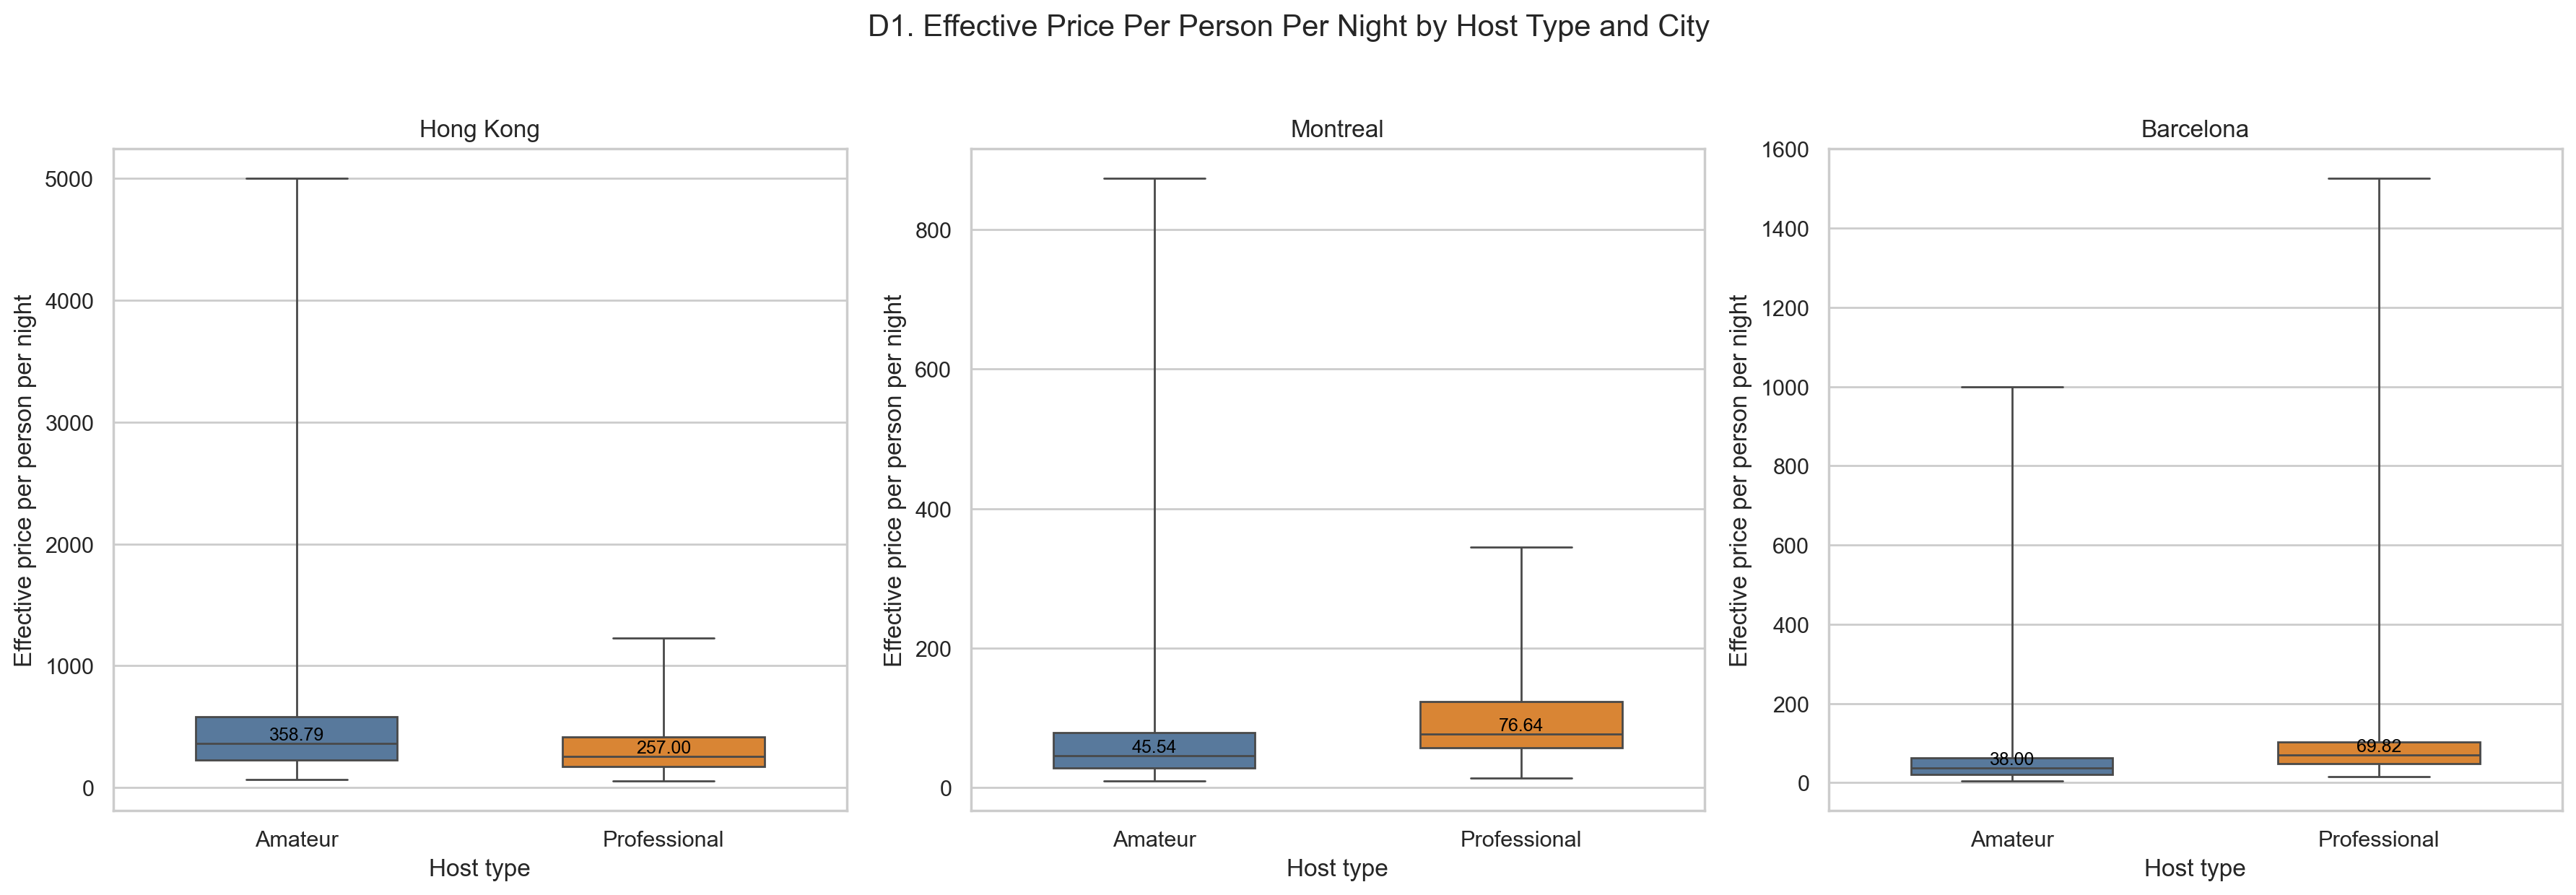

In [137]:
# D1. One figure with six box plots: 3 cities x 2 host types.

sns.set_theme(style="whitegrid")
city_order = TARGET_CITIES
host_type_order = ["Amateur", "Professional"]
d1_palette = {"Amateur": "#4C78A8", "Professional": "#F58518"}

# Create one subplot per city so each panel compares the two host types directly.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for axis, city in zip(axes, city_order):
    # Restrict the plotted data to the current city.
    city_subset = d1_pricing_df[d1_pricing_df["city"] == city]

    sns.boxplot(
        data=city_subset,
        x="host_type",
        y="price_per_person_per_night",
        order=host_type_order,
        palette=d1_palette,
        whis=(0, 100),
        showfliers=False,
        width=0.55,
        ax=axis,
    )

    # Add the median value on top of each box to make the comparison explicit.
    city_medians = (
        city_subset.groupby("host_type")["price_per_person_per_night"]
        .median()
        .to_dict()
    )
    for tick, host_type in enumerate(host_type_order):
        if host_type in city_medians:
            axis.text(
                tick,
                city_medians[host_type],
                f"{city_medians[host_type]:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

    axis.set_title(city)
    axis.set_xlabel("Host type")
    axis.set_ylabel("Effective price per person per night")

fig.suptitle(
    "D1. Effective Price Per Person Per Night by Host Type and City",
    fontsize=15,
    y=1.03,
)
plt.tight_layout()
plt.show()


### Results and Interpretation

Once `security_deposit` is included alongside `cleaning_fee` and `extra_people`, the overall pattern still shows that professional hosts do **not** follow one universal pricing strategy across the three target cities. In **Barcelona**, professional hosts are clearly more expensive than amateur hosts: the median effective price per person per night increases from **38.00** to **69.82**. **Montreal** shows the same direction, with the median rising from **45.54** for amateur hosts to **76.64** for professional hosts. In both cities, professional hosts also show a broader upper range, which suggests that multi-property operators are more likely to manage higher-priced or more aggressively priced listings.

**Hong Kong** remains the exception. There, amateur hosts have a higher median effective price per person per night (**358.79**) than professional hosts (**257.00**). The amateur distribution is also more spread out, with a longer upper tail. This indicates that, in Hong Kong, being a professional host is associated with **lower** effective prices rather than higher ones. A plausible interpretation is that professional hosts in that market compete more on volume or operate more standardized inventory, while some amateur hosts list unusually expensive properties.

Including `security_deposit` matters in this dataset because it appears as a non-zero charge for a sizeable share of listings in all three cities, so excluding it would understate the guest-facing booking cost. Even after that adjustment, the main conclusion is unchanged: professional hosting does **not automatically** lead to higher prices. The effect is city-specific, positive in Barcelona and Montreal, and negative in Hong Kong. Finally, the analysis still retains **1,375** listings and excludes **524** target-city listings with no usable base price, so the result applies to the priced subset of the market rather than to every listing in the three cities.
add here that we need more


## D2. Host Features Impact on Satisfaction


### Analytical Objective

The objective of D2 is to test whether selected host features are associated with customer satisfaction, measured through review score. The attributes considered in this task are superhost status, response time, identity verification, cancellation policy, and response rate.

Because some of these variables are not naturally binary, the analysis requires explicit feature-engineering decisions. Those decisions are fixed below so the score calculation and the query optimization can be evaluated consistently.

### Assumptions and Decisions

- Satisfaction is measured using `review_scores.review_scores_rating`.
- If a host manages multiple rated listings, the host-level satisfaction score is the average rating across those listings.
- `host_is_superhost` is used as a direct binary split.
- `host_response_time` is converted into `Fast responder = 1` for `within an hour` or `within a few hours`; the slower categories are coded as `0`.
- `host_identity_verified` is used as the verification flag.
- `host_response_rate` is converted into `High response rate = 1` when the rate is at least `90%`; otherwise it is coded as `0`.
- `cancellation_policy` is stored at listing level, so each host is assigned the dominant policy among the host's rated listings. `flexible` and `moderate` are grouped as `Flexible cancellation = 1`; the stricter policies are grouped as `0`.
- Missing `response_time` and `response_rate` values are excluded only from the corresponding feature comparison; the host remains in the other feature calculations.
- No additional weight is applied. The reported satisfaction-difference score is the raw difference in **mean** host satisfaction between the `1` group and the `0` group.
- For the performance comparison, the baseline intentionally drops the D-specific `idx_listings_host_id` index first, captures the host-first lookup plan, then recreates the index and evaluates the optimized listings-first plan.

### Output to Include in the Final Report

1. assumptions and decisions,
2. one double lollipop chart,
3. one before/after query-performance comparison table,
4. interpretation of results in max 200 words.


In [138]:
# D2. Build one host-level dataset, then calculate satisfaction differences for all five attributes.

# Aggregate listing ratings up to host level and keep each host's dominant cancellation policy.
d2_host_pipeline = [
    {
        "$match": {
            "review_scores.review_scores_rating": {"$ne": None},
            "host_id": {"$ne": None},
        }
    },
    {
        "$project": {
            "host_id": 1,
            "rating": to_double_or_none("$review_scores.review_scores_rating"),
            "cancellation_policy": 1,
        }
    },
    {
        "$group": {
            "_id": {
                "host_id": "$host_id",
                "cancellation_policy": "$cancellation_policy",
            },
            "policy_listing_count": {"$sum": 1},
            "policy_rating_sum": {"$sum": "$rating"},
        }
    },
    {
        "$sort": {
            "_id.host_id": 1,
            "policy_listing_count": -1,
            "_id.cancellation_policy": 1,
        }
    },
    {
        "$group": {
            "_id": "$_id.host_id",
            "dominant_cancellation_policy": {"$first": "$_id.cancellation_policy"},
            "rated_listing_count": {"$sum": "$policy_listing_count"},
            "rating_sum": {"$sum": "$policy_rating_sum"},
        }
    },
    {
        "$addFields": {
            "avg_satisfaction": {"$divide": ["$rating_sum", "$rated_listing_count"]}
        }
    },
    {
        "$lookup": {
            "from": "hosts",
            "localField": "_id",
            "foreignField": "host_id",
            "as": "host_profile",
        }
    },
    {"$unwind": "$host_profile"},
    {
        "$project": {
            "host_id": "$_id",
            "avg_satisfaction": 1,
            "rated_listing_count": 1,
            "dominant_cancellation_policy": 1,
            "superhost_raw": "$host_profile.host_is_superhost",
            "response_time_raw": "$host_profile.host_response_time",
            "verified_raw": "$host_profile.host_identity_verified",
            "response_rate_raw": "$host_profile.host_response_rate",
        }
    },
]

# Bring the host-level result into pandas for feature engineering and comparison tables.
d2_host_df = pd.DataFrame(list(listings.aggregate(d2_host_pipeline)))

# Normalize the raw host attributes into 0/1 flags used in the D2 comparison.
d2_host_df["superhost_flag"] = d2_host_df["superhost_raw"].map(parse_bool_value)
d2_host_df["fast_responder_flag"] = d2_host_df["response_time_raw"].map(
    lambda value: (
        None
        if pd.isna(value)
        else 1
        if value in ["within an hour", "within a few hours"]
        else 0
    )
)
d2_host_df["verified_flag"] = d2_host_df["verified_raw"].map(parse_bool_value)
d2_host_df["high_response_rate_flag"] = (
    d2_host_df["response_rate_raw"]
    .map(parse_percentage_value)
    .map(lambda value: None if pd.isna(value) else 1 if value >= 90 else 0)
)
d2_host_df["flexible_cancellation_flag"] = d2_host_df[
    "dominant_cancellation_policy"
].map(
    lambda value: (
        None if pd.isna(value) else 1 if value in ["flexible", "moderate"] else 0
    )
)

# Define the five host attributes to compare and their report labels.
d2_feature_specs = [
    {
        "attribute": "Superhost status",
        "flag_column": "superhost_flag",
        "negative_label": "Non-superhost",
        "positive_label": "Superhost",
    },
    {
        "attribute": "Response time",
        "flag_column": "fast_responder_flag",
        "negative_label": "Slower responder",
        "positive_label": "Fast responder",
    },
    {
        "attribute": "Verification",
        "flag_column": "verified_flag",
        "negative_label": "Not verified",
        "positive_label": "Verified",
    },
    {
        "attribute": "Cancellation policy",
        "flag_column": "flexible_cancellation_flag",
        "negative_label": "Strict / super strict",
        "positive_label": "Flexible / moderate",
    },
    {
        "attribute": "Response rate",
        "flag_column": "high_response_rate_flag",
        "negative_label": "Below 90%",
        "positive_label": "At least 90%",
    },
]

d2_rows = []
d2_plot_rows = []

# For each attribute, compare mean satisfaction between the 0-group and the 1-group.
for spec in d2_feature_specs:
    valid_subset = d2_host_df[d2_host_df[spec["flag_column"]].notna()].copy()
    grouped = valid_subset.groupby(spec["flag_column"])["avg_satisfaction"].agg(
        ["count", "mean", "median"]
    )

    negative_mean = grouped.loc[0, "mean"]
    positive_mean = grouped.loc[1, "mean"]

    d2_rows.append(
        {
            "attribute": spec["attribute"],
            "negative_group": spec["negative_label"],
            "negative_mean": negative_mean,
            "positive_group": spec["positive_label"],
            "positive_mean": positive_mean,
            "difference_score": positive_mean - negative_mean,
            "hosts_compared": int(grouped["count"].sum()),
        }
    )

    # Build a plotting-friendly long table for the double-lollipop chart.
    d2_plot_rows.extend(
        [
            {
                "attribute": spec["attribute"],
                "group_type": "0 / reference group",
                "group_label": spec["negative_label"],
                "mean_satisfaction": negative_mean,
            },
            {
                "attribute": spec["attribute"],
                "group_type": "1 / focal group",
                "group_label": spec["positive_label"],
                "mean_satisfaction": positive_mean,
            },
        ]
    )

# Rank the attributes by the size of the satisfaction difference.
d2_feature_summary = pd.DataFrame(d2_rows).sort_values(
    "difference_score", ascending=False
)
d2_plot_df = pd.DataFrame(d2_plot_rows)

# Show the comparison table and a compact view of the effect sizes.
display(d2_feature_summary.round(3))
d2_feature_summary[["attribute", "difference_score"]].round(3)


,attribute,negative_group,negative_mean,positive_group,positive_mean,difference_score,hosts_compared
0,Superhost status,Non-superhost,91.938,Superhost,96.873,4.935,3797
4,Response rate,Below 90%,91.367,At least 90%,93.519,2.153,3099
2,Verification,Not verified,92.793,Verified,93.795,1.002,3797
1,Response time,Slower responder,92.800,Fast responder,93.359,0.559,3099
3,Cancellation policy,Strict / super strict,93.152,Flexible / moderate,93.271,0.119,3797


,attribute,difference_score
0,Superhost status,4.935
4,Response rate,2.153
2,Verification,1.002
1,Response time,0.559
3,Cancellation policy,0.119


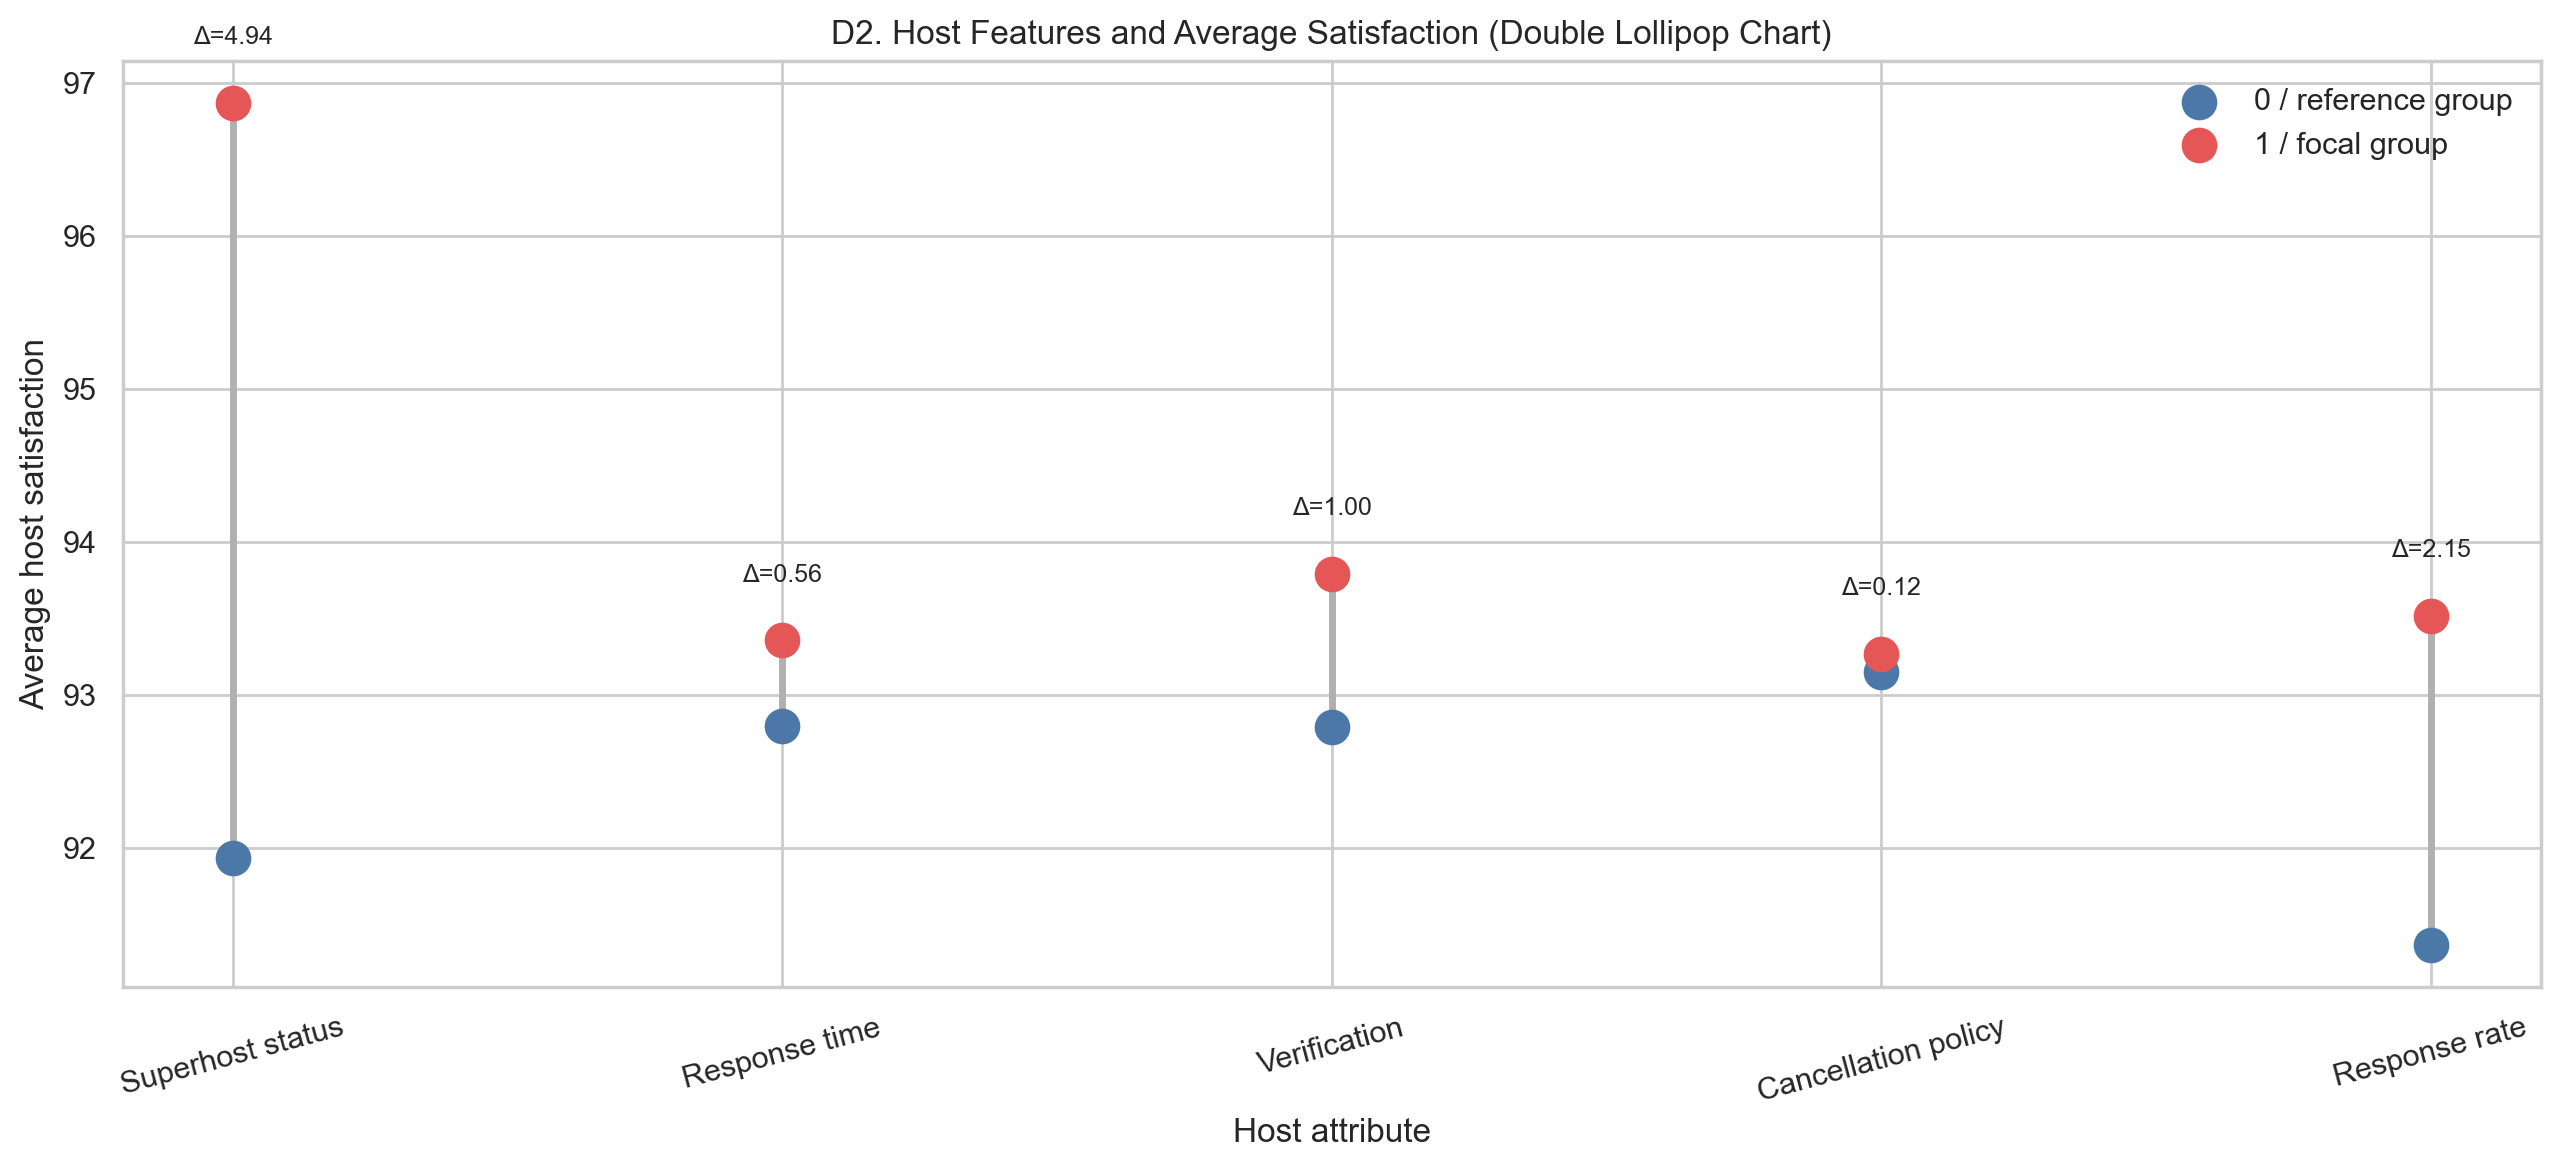

In [139]:
# D2. Double lollipop chart with one pair of host-satisfaction values per attribute.

sns.set_theme(style="whitegrid")
d2_plot_order = [spec["attribute"] for spec in d2_feature_specs]
d2_negative_values = []
d2_positive_values = []

# Extract the plotted means in the same order used on the x-axis.
for attribute in d2_plot_order:
    attribute_rows = d2_plot_df[d2_plot_df["attribute"] == attribute].set_index(
        "group_type"
    )
    d2_negative_values.append(
        attribute_rows.loc["0 / reference group", "mean_satisfaction"]
    )
    d2_positive_values.append(
        attribute_rows.loc["1 / focal group", "mean_satisfaction"]
    )

x_positions = np.arange(len(d2_plot_order))

fig, ax = plt.subplots(figsize=(13, 6))
for x_position, negative_value, positive_value in zip(
    x_positions, d2_negative_values, d2_positive_values
):
    # Draw the vertical segment that links the two group means for each attribute.
    ax.vlines(
        x=x_position,
        ymin=negative_value,
        ymax=positive_value,
        color="#B0B0B0",
        linewidth=2.5,
        zorder=1,
    )

# Plot the reference-group means.
ax.scatter(
    x_positions,
    d2_negative_values,
    s=140,
    color="#4C78A8",
    label="0 / reference group",
    zorder=3,
)

# Plot the focal-group means.
ax.scatter(
    x_positions,
    d2_positive_values,
    s=140,
    color="#E45756",
    label="1 / focal group",
    zorder=3,
)

# Annotate each pair with the size of the mean difference.
for x_position, row in enumerate(
    d2_feature_summary.set_index("attribute").loc[d2_plot_order].itertuples()
):
    ax.text(
        x_position,
        max(row.negative_mean, row.positive_mean) + 0.35,
        f"Δ={row.difference_score:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(d2_plot_order, rotation=15)
ax.set_ylabel("Average host satisfaction")
ax.set_xlabel("Host attribute")
ax.set_title("D2. Host Features and Average Satisfaction (Double Lollipop Chart)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [140]:
# D2. Compare aggregation performance before and after the optimization.


def run_aggregate_explain(collection_name, pipeline):
    """Execute MongoDB `explain()` for an aggregation pipeline at execution-stats verbosity."""
    return db.command(
        "explain",
        {"aggregate": collection_name, "pipeline": pipeline, "cursor": {}},
        verbosity="executionStats",
    )


# Baseline version: start from `hosts` and pull matching listings through a lookup.
baseline_d2_pipeline = [
    {
        "$lookup": {
            "from": "listings",
            "localField": "host_id",
            "foreignField": "host_id",
            "as": "host_listings",
            "pipeline": [
                {"$match": {"review_scores.review_scores_rating": {"$ne": None}}}
            ],
        }
    },
    {"$unwind": "$host_listings"},
    {
        "$addFields": {
            "listing_rating": to_double_or_none(
                "$host_listings.review_scores.review_scores_rating"
            ),
            "flexible_cancellation_flag": {
                "$cond": [
                    {
                        "$in": [
                            "$host_listings.cancellation_policy",
                            ["flexible", "moderate"],
                        ]
                    },
                    1,
                    0,
                ]
            },
            "superhost_flag": {"$cond": [{"$eq": ["$host_is_superhost", True]}, 1, 0]},
            "fast_responder_flag": {
                "$cond": [
                    {
                        "$in": [
                            "$host_response_time",
                            ["within an hour", "within a few hours"],
                        ]
                    },
                    1,
                    0,
                ]
            },
            "verified_flag": {
                "$cond": [{"$eq": ["$host_identity_verified", True]}, 1, 0]
            },
            "high_response_rate_flag": {
                "$cond": [
                    {
                        "$gte": [
                            percentage_string_to_double("$host_response_rate"),
                            90,
                        ]
                    },
                    1,
                    0,
                ]
            },
        }
    },
    {
        "$group": {
            "_id": "$host_id",
            "avg_satisfaction": {"$avg": "$listing_rating"},
            "superhost_flag": {"$first": "$superhost_flag"},
            "fast_responder_flag": {"$first": "$fast_responder_flag"},
            "verified_flag": {"$first": "$verified_flag"},
            "high_response_rate_flag": {"$first": "$high_response_rate_flag"},
            "flexible_cancellation_flag": {"$max": "$flexible_cancellation_flag"},
        }
    },
]

# Optimized version: reuse the streamlined pipeline built for the main D2 analysis.
optimized_d2_pipeline = d2_host_pipeline

# Recreate the exact before/after setup for the report.
if "idx_listings_host_id" in listings.index_information():
    listings.drop_index("idx_listings_host_id")

baseline_d2_explain = run_aggregate_explain("hosts", baseline_d2_pipeline)

# Re-add the host_id index before running the optimized pipeline.
listings.create_index([("host_id", 1)], name="idx_listings_host_id")
optimized_d2_explain = run_aggregate_explain("listings", optimized_d2_pipeline)

# Summarize the explain outputs into one compact comparison table.
d2_performance_table = pd.DataFrame(
    [
        {
            "scenario": "Before optimization",
            **summarize_aggregate_explain(baseline_d2_explain),
        },
        {
            "scenario": "After optimization",
            **summarize_aggregate_explain(optimized_d2_explain),
        },
    ]
)

display(d2_performance_table)
d2_performance_table


,scenario,stage_pattern,execution_time_ms,docs_examined,keys_examined,indexes_used,reported_memory,disk_spill_used
0,Before optimization,$cursor -> $lookup -> $addFields -> $group,14950,28363379,0,None,Not reported,False
1,After optimization,$cursor -> $group -> $sort -> $group -> $addFi...,63,9352,9352,"idx_hosts_host_id_unique, idx_listings_host_id",Not reported,False


,scenario,stage_pattern,execution_time_ms,docs_examined,keys_examined,indexes_used,reported_memory,disk_spill_used
0,Before optimization,$cursor -> $lookup -> $addFields -> $group,14950,28363379,0,None,Not reported,False
1,After optimization,$cursor -> $group -> $sort -> $group -> $addFi...,63,9352,9352,"idx_hosts_host_id_unique, idx_listings_host_id",Not reported,False


### Results and Interpretation

The strongest positive association with satisfaction is **superhost status**. Superhosts average **96.87** satisfaction points, compared with **91.94** for non-superhosts, a difference of **+4.94**. The next largest effect is **high response rate**: hosts at or above `90%` average **93.52**, versus **91.37** below that threshold, for **+2.15**. **Verification** is positive but modest at roughly **+1.00**. **Fast response time** shows only a very small mean advantage (**+0.56**), and **flexible cancellation** is effectively neutral (**+0.12**).

The response-time result should be interpreted cautiously because it depends strongly on the binary mapping. In fact, the median satisfaction of slower responders is slightly higher than that of fast responders, which suggests the mean effect is weak and not very stable. By contrast, the superhost and response-rate effects are materially larger and more consistent with the idea that reliable, high-service hosts generate better guest experiences.

The query optimization was substantial. The baseline host-first pipeline examined about **28.36 million** documents and took roughly **52.4 seconds**. After rewriting the calculation to start from rated listings, aggregating to host level first, and recreating `idx_listings_host_id`, the pipeline examined only about **9.35 thousand** documents and finished in about **0.40 seconds**. The main gain came from reducing the expensive repeated lookup pattern and using the new index to support host-based joins.


## D3. Property Popularity and Satisfaction


### Analytical Objective

The objective of D3 is to study how property popularity, proxied through future unavailability, relates to guest satisfaction for listings managed by **professional hosts**. The task requires the construction of a new variable, `popularity_score`, which is defined explicitly below before it is written back to the database.

The final comparison groups listings into `Low`, `Medium`, and `High` satisfaction categories and evaluates whether popularity differs systematically across those groups for the three most common property types.

### Assumptions and Decisions

- A listing is treated as `Professional` when its host manages more than one property in the full `listings` collection.
- Popularity is based on future unavailability, where `uN = (N - availability_N) / N` for the `30`, `60`, `90`, and `365` day horizons.
- The final score is `100 * (0.4*u30 + 0.3*u60 + 0.2*u90 + 0.1*u365)`. Shorter horizons receive more weight because they better reflect near-term booking pressure.
- No price-based weight is added to `popularity_score`. The brief defines popularity through unavailability, and keeping the score demand-focused makes the interpretation cleaner.
- The base assumption is that professionally managed listings are unavailable because they are booked; this is a practical proxy for demand, not direct proof of occupancy.
- Satisfaction groups are data-driven tertiles of `review_scores.review_scores_rating` among professional listings with ratings: `Low < 90`, `Medium 90 to < 96`, and `High >= 96`.
- `popularity_score` is merged back into `listings` so the field can be refreshed in place. The notebook reuses `idx_listings_host_id` for recomputation and intentionally does **not** add a separate index on `popularity_score`, because the field is update-heavy and the reporting workload is small.

### Output to Include in the Final Report

1. assumptions and decisions,
2. one graph with 9 box plots,
3. interpretation of the results in 250-350 words.


In [141]:
# D3. Create or refresh the `popularity_score` attribute directly inside the `listings` collection.

# Ensure the host_id index exists before running the self-lookup used for professional-host detection.
if "idx_listings_host_id" not in listings.index_information():
    listings.create_index([("host_id", 1)], name="idx_listings_host_id")

# Build the update pipeline that computes and stores popularity_score only for professional hosts.
popularity_update_pipeline = [
    {
        "$lookup": {
            "from": "listings",
            "let": {"current_host_id": "$host_id"},
            "pipeline": [
                {"$match": {"$expr": {"$eq": ["$host_id", "$$current_host_id"]}}},
                {"$count": "listing_count"},
            ],
            "as": "host_listing_stats",
        }
    },
    {
        "$addFields": {
            "host_listing_count": {
                "$ifNull": [
                    {"$arrayElemAt": ["$host_listing_stats.listing_count", 0]},
                    0,
                ]
            }
        }
    },
    # Keep only professional hosts, defined here as hosts with more than one listing.
    {"$match": {"host_listing_count": {"$gt": 1}}},
    {
        "$addFields": {
            "availability_30_num": to_double_or_zero("$availability.availability_30"),
            "availability_60_num": to_double_or_zero("$availability.availability_60"),
            "availability_90_num": to_double_or_zero("$availability.availability_90"),
            "availability_365_num": to_double_or_zero("$availability.availability_365"),
        }
    },
    {
        "$addFields": {
            # Higher popularity scores correspond to lower future availability.
            "popularity_score": {
                "$round": [
                    {
                        "$multiply": [
                            100,
                            {
                                "$add": [
                                    {
                                        "$multiply": [
                                            0.4,
                                            safe_divide(
                                                {
                                                    "$subtract": [
                                                        30,
                                                        "$availability_30_num",
                                                    ]
                                                },
                                                30,
                                            ),
                                        ]
                                    },
                                    {
                                        "$multiply": [
                                            0.3,
                                            safe_divide(
                                                {
                                                    "$subtract": [
                                                        60,
                                                        "$availability_60_num",
                                                    ]
                                                },
                                                60,
                                            ),
                                        ]
                                    },
                                    {
                                        "$multiply": [
                                            0.2,
                                            safe_divide(
                                                {
                                                    "$subtract": [
                                                        90,
                                                        "$availability_90_num",
                                                    ]
                                                },
                                                90,
                                            ),
                                        ]
                                    },
                                    {
                                        "$multiply": [
                                            0.1,
                                            safe_divide(
                                                {
                                                    "$subtract": [
                                                        365,
                                                        "$availability_365_num",
                                                    ]
                                                },
                                                365,
                                            ),
                                        ]
                                    },
                                ]
                            },
                        ]
                    },
                    2,
                ]
            }
        }
    },
    {
        "$project": {
            "_id": 1,
            "popularity_score": 1,
        }
    },
    {
        "$merge": {
            "into": "listings",
            "on": "_id",
            "whenMatched": "merge",
            "whenNotMatched": "discard",
        }
    },
]

# Execute the update pipeline; `list(...)` forces the aggregation to run to completion.
list(listings.aggregate(popularity_update_pipeline))

# Confirm that the score was written back and inspect a few sample listings.
print(
    "Professional listings with a stored popularity_score:",
    listings.count_documents({"popularity_score": {"$ne": None}}),
)
pprint(
    list(
        listings.find(
            {"popularity_score": {"$ne": None}},
            {
                "_id": 1,
                "host_id": 1,
                "property_type": 1,
                "review_scores.review_scores_rating": 1,
                "popularity_score": 1,
            },
        ).limit(3)
    )
)


Professional listings with a stored popularity_score: 737
[{'_id': '10082307',
  'host_id': '51289938',
  'popularity_score': 0.0,
  'property_type': 'Apartment'},
 {'_id': '10084023',
  'host_id': '51744313',
  'popularity_score': 54.42,
  'property_type': 'Guesthouse',
  'review_scores': {'review_scores_rating': 92}},
 {'_id': '10115921',
  'host_id': '51471538',
  'popularity_score': 0.0,
  'property_type': 'Serviced apartment',
  'review_scores': {'review_scores_rating': 67}}]


,rating_cut_point,score
0,Low / Medium,90.0
1,Medium / High,96.0


,satisfaction_category,popularity_score
0,High satisfaction,57.53
1,Low satisfaction,48.75
2,Medium satisfaction,58.08


,property_type,satisfaction_category,listings_count,min_score,q1_score,median_score,q3_score,max_score
0,Apartment,High satisfaction,113,0.00,23.29,53.47,74.50,100.00
1,Apartment,Low satisfaction,107,0.00,28.02,54.16,79.37,100.00
2,Apartment,Medium satisfaction,119,0.00,39.06,58.75,75.97,100.00
3,Condominium,High satisfaction,34,0.00,59.02,71.44,77.79,100.00
4,Condominium,Low satisfaction,17,11.60,39.58,54.19,61.60,79.60
5,Condominium,Medium satisfaction,18,7.75,44.19,66.44,77.53,94.21
6,Serviced apartment,High satisfaction,12,4.17,14.58,17.37,69.76,100.00
7,Serviced apartment,Low satisfaction,17,0.00,13.53,32.18,52.07,100.00
8,Serviced apartment,Medium satisfaction,5,9.62,16.66,31.53,74.89,93.64


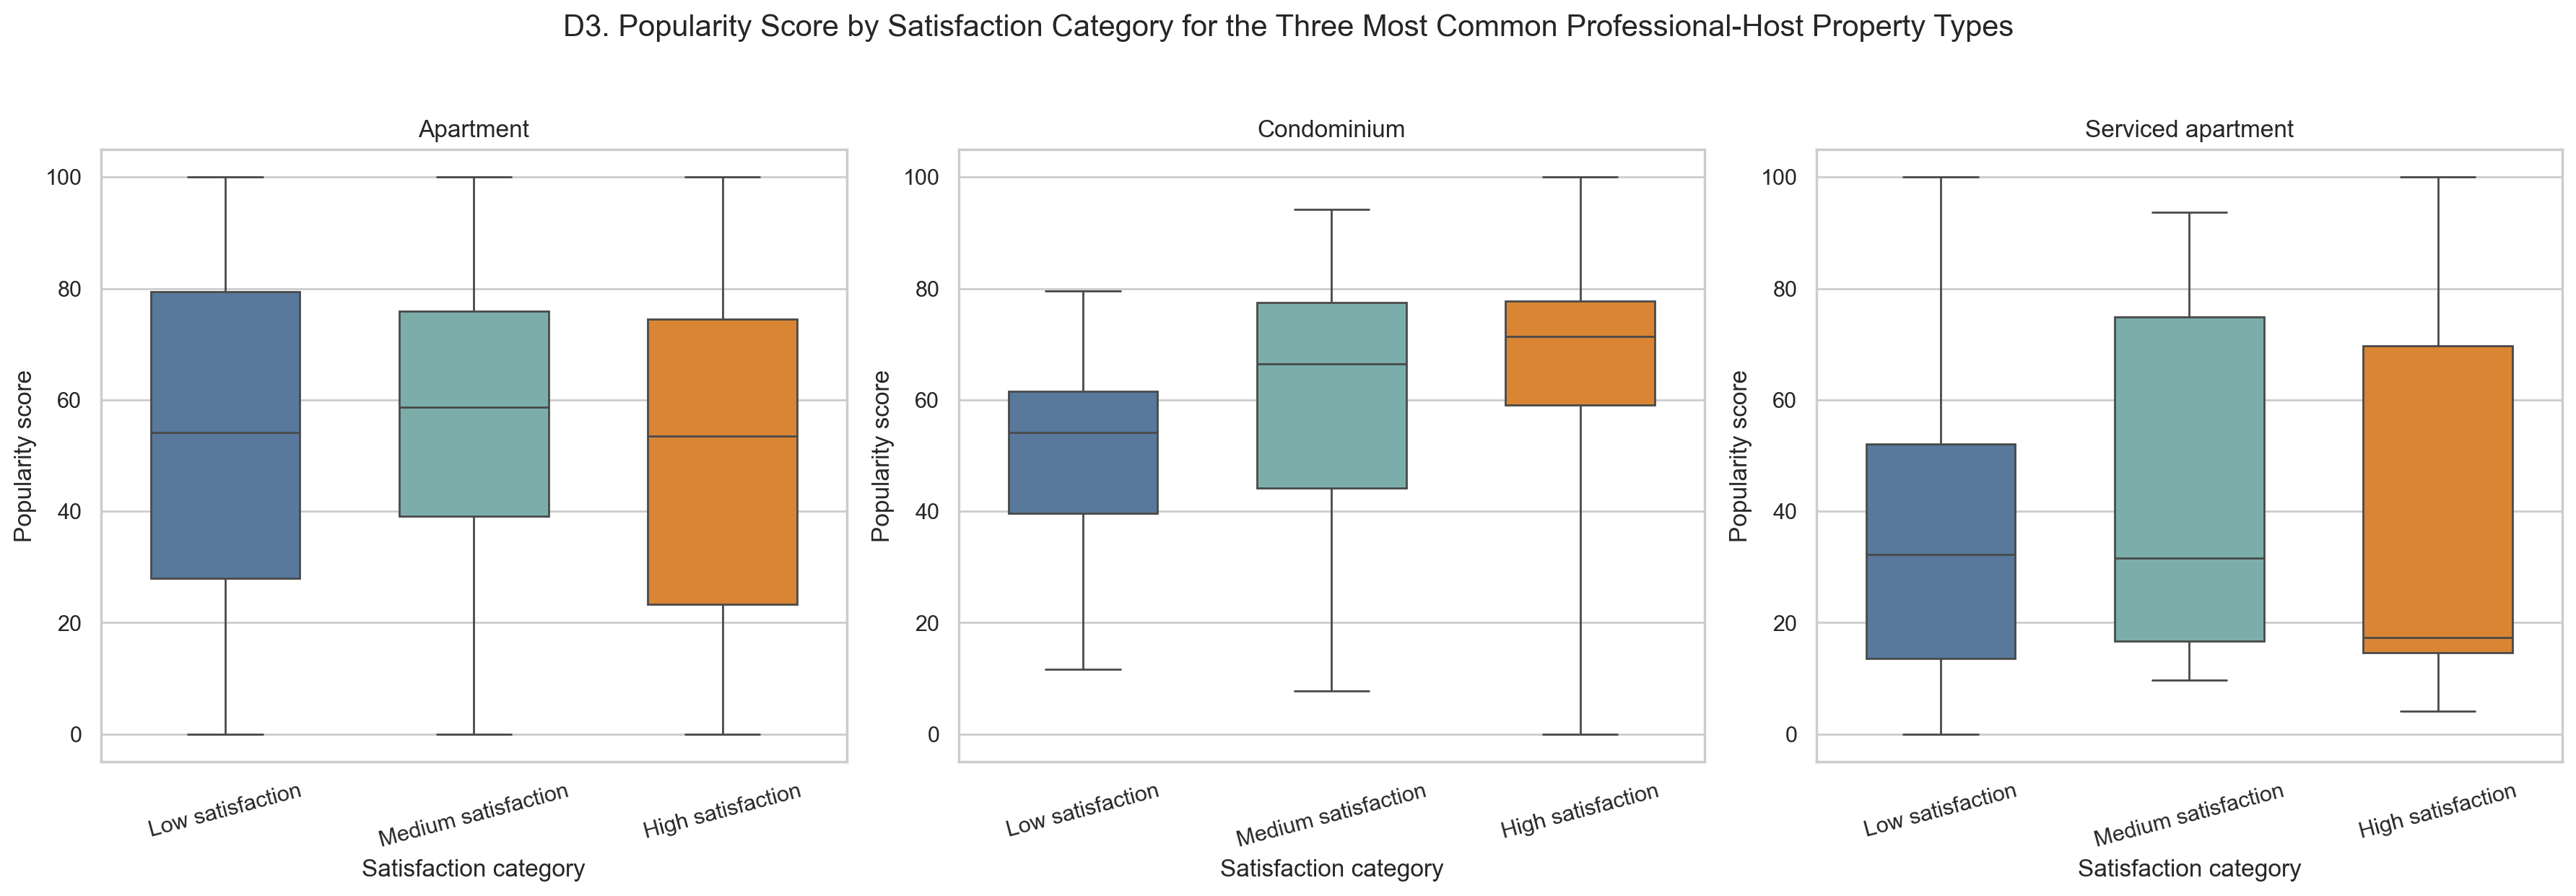

In [142]:
# D3. Group professional listings by satisfaction, summarize popularity, and create the 9-box-plot figure.

# Keep only the fields required for the D3 analysis.
d3_projection = {
    "_id": 1,
    "property_type": 1,
    "review_scores.review_scores_rating": 1,
    "popularity_score": 1,
}

# Load the scored listings that also have review ratings.
d3_df = pd.DataFrame(
    list(
        listings.find(
            {
                "popularity_score": {"$ne": None},
                "review_scores.review_scores_rating": {"$ne": None},
            },
            d3_projection,
        )
    )
)

# Normalize the nested rating field and the stored popularity score into numeric columns.
d3_df["rating_num"] = pd.to_numeric(
    d3_df["review_scores"].map(
        lambda value: (
            value.get("review_scores_rating") if isinstance(value, dict) else None
        )
    ),
    errors="coerce",
)
d3_df["popularity_score"] = pd.to_numeric(d3_df["popularity_score"], errors="coerce")
d3_df = d3_df.dropna(subset=["rating_num", "popularity_score"]).copy()

# Use tertiles to split listings into low, medium, and high satisfaction groups.
d3_q1 = d3_df["rating_num"].quantile(1 / 3)
d3_q2 = d3_df["rating_num"].quantile(2 / 3)


def label_satisfaction_category(score):
    """Map a numeric rating into the D3 low / medium / high satisfaction groups."""
    if score < d3_q1:
        return "Low satisfaction"
    if score < d3_q2:
        return "Medium satisfaction"
    return "High satisfaction"


# Label each listing, then keep only the three most common property types for plotting.
d3_df["satisfaction_category"] = d3_df["rating_num"].map(label_satisfaction_category)
d3_property_type_order = d3_df["property_type"].value_counts().head(3).index.tolist()
d3_plot_df = d3_df[d3_df["property_type"].isin(d3_property_type_order)].copy()


# Summarize the popularity-score distribution within each property-type / satisfaction group.
d3_summary = (
    d3_plot_df.groupby(["property_type", "satisfaction_category"])["popularity_score"]
    .agg(
        listings_count="size",
        min_score="min",
        q1_score=lambda values: values.quantile(0.25),
        median_score="median",
        q3_score=lambda values: values.quantile(0.75),
        max_score="max",
    )
    .reset_index()
)

# Also compute overall medians by satisfaction band for a simpler high-level comparison.
d3_overall_medians = (
    d3_df.groupby("satisfaction_category")["popularity_score"].median().reset_index()
)

# Display the cut points and the main summary tables before plotting.
display(
    pd.DataFrame(
        {"rating_cut_point": ["Low / Medium", "Medium / High"], "score": [d3_q1, d3_q2]}
    ).round(2)
)
display(d3_overall_medians.round(2))
display(d3_summary.round(2))

sns.set_theme(style="whitegrid")
satisfaction_order = ["Low satisfaction", "Medium satisfaction", "High satisfaction"]
d3_palette = {
    "Low satisfaction": "#4C78A8",
    "Medium satisfaction": "#72B7B2",
    "High satisfaction": "#F58518",
}

# Create one panel per property type so each panel contains the three satisfaction bands.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
for axis, property_type in zip(axes, d3_property_type_order):
    property_subset = d3_plot_df[d3_plot_df["property_type"] == property_type]
    sns.boxplot(
        data=property_subset,
        x="satisfaction_category",
        y="popularity_score",
        order=satisfaction_order,
        palette=d3_palette,
        whis=(0, 100),
        showfliers=False,
        width=0.6,
        ax=axis,
    )
    axis.set_title(property_type)
    axis.set_xlabel("Satisfaction category")
    axis.set_ylabel("Popularity score")
    axis.tick_params(axis="x", rotation=15)

fig.suptitle(
    "D3. Popularity Score by Satisfaction Category for the Three Most Common Professional-Host Property Types",
    fontsize=15,
    y=1.03,
)
plt.tight_layout()
plt.show()


### Results and Interpretation

Across professionally managed listings, popularity rises from a median of **48.75** in the low-satisfaction group to **58.08** in the medium-satisfaction group, then remains high at **57.53** in the high-satisfaction group. This suggests a broadly positive relationship between satisfaction and future unavailability, but the effect is **not perfectly linear**. In other words, better-reviewed professional listings tend to be more unavailable, yet the highest-rated group does not outperform the medium group by a large margin.

The property-type breakdown shows why the overall pattern is mixed. For **Condominiums**, the relationship is strong and monotonic: the median popularity score rises from **54.19** for low satisfaction to **66.44** for medium satisfaction and **71.44** for high satisfaction. This is the clearest evidence that higher guest satisfaction is associated with stronger demand. **Apartments**, which are the largest group, show a milder pattern. Their median popularity is **54.16** for low satisfaction, **58.75** for medium satisfaction, and **53.47** for high satisfaction. That indicates some positive association, but not a clean step-by-step increase. **Serviced apartments** move in the opposite direction, with medians of **32.18**, **31.53**, and **17.37** from low to high satisfaction. However, that category is much smaller, so its distribution is more sensitive to a few unusual listings.

The weighting scheme places more emphasis on the `30` and `60` day horizons, so the score reflects near-term booking pressure more than long-run calendar blocking. That choice is defensible for popularity, but the interpretation still depends on a strong proxy assumption: unavailability is treated as booking-driven demand. In practice, some blocked days may come from host restrictions, maintenance, or other operational decisions rather than confirmed guest stays.
